In [81]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import savgol_filter
import matplotlib
import matplotlib.colors as mcolors
from matplotlib.colors import Normalize
import matplotlib.cm as cm
import math
import seaborn as sns
import scipy.stats as stats
import collections
import os
import json
import urllib.request
import ast
from scipy.stats import pearsonr
from pathlib import Path
import itertools
from itertools import repeat
import re
import colorsys
%config InlineBackend.figure_format='retina'
matplotlib.rcParams['pdf.fonttype'] = 42

# Fetching Metaprofile files (if needed)

In [25]:
zenodo_record_id = "20254051"
api_url = f"https://zenodo.org/api/records/{zenodo_record_id}"
data_folder = "data/promoter_signals/"

def fetch_zenodo_files():
    os.makedirs(data_folder, exist_ok=True)
    
    print(f"Connecting to Zenodo Record {zenodo_record_id}...")
    
    try:
        # 1. Ask Zenodo for the list of files
        req = urllib.request.Request(api_url)
        with urllib.request.urlopen(req) as response:
            metadata = json.loads(response.read().decode())
            
        files = metadata.get('files', [])
        print(f"Found {len(files)} files attached to this project.")
        
        # 2. Download each file directly into the folder
        download_count = 0
        for f in files:
            filename = f['key']
            download_url = f['links']['self']
            file_path = os.path.join(data_folder, filename)
            if not os.path.exists(file_path):
                print(f"Downloading {filename}...")
                urllib.request.urlretrieve(download_url, file_path)
                download_count += 1
                
        if download_count > 0:
            print(f"Successfully downloaded {download_count} new files into '{data_folder}'!")
        else:
            print(f"All files already exist locally in '{data_folder}'. Ready to plot!")
            
    except Exception as e:
        print(f"An error occurred while connecting to Zenodo: {e}")


fetch_zenodo_files()

Connecting to Zenodo Record 20254051...
Found 35 files attached to this project.
All files already exist locally in 'data/promoter_signals/'. Ready to plot!


# Color Palette

In [26]:
n = 256  
c = 0.4
base_cmap = plt.get_cmap("Greens")  
colors = (1. - c) * base_cmap(np.linspace(0., 1., n)) + c * np.ones((n, 4)) 
pastel_cmap = mcolors.LinearSegmentedColormap.from_list("PastelGreens", colors, N=n)
norm = mcolors.Normalize(vmin=0, vmax=1)

# File Loading

In [27]:
WT_system_data = pd.read_pickle('WT_system_strains.gz')
d12_system_data = pd.read_pickle('d12_Fusion_system.gz')
WT_d12 = pd.read_pickle('WT_d12_strains.gz')
Repeats = pd.read_pickle('experimental_repeats.gz')
Flocculation = pd.read_pickle('flocculation_results.gz')
msn2_dbd_repeats = pd.read_pickle('N_term_dbd_repeats.gz')
msn2_dbd_c_repeats = pd.read_pickle('C_term_dbd_repeats.gz')
wt_system_repeats = pd.read_pickle('WT_system_repeats.gz')
all_TFs = pd.read_csv('tfs_sumprom.csv')
all_TFs.index = d12_system_data.index

gp = pd.read_csv('geneinfo_params.csv', index_col=0)
df_for_sp = pd.read_csv('frame_for_spcalc.csv', index_col=4)

In [28]:
folder_path = os.getcwd()+'/data/promoter_signals/'
promoter_files = [f for f in os.listdir(folder_path) if f.endswith('2000bp_signals.gz')]
file_dict = {}
for file in promoter_files:
    file_dict[file] = folder_path+file
    data = [{'file_name': k, 'path': v} for k, v in file_dict.items()]

# Create the DataFrame
promoter_binding_signals = pd.DataFrame(data)
promoter_binding_signals.set_index('file_name', inplace=True)
promoter_binding_signals=promoter_binding_signals.T

# Targets

In [36]:
med15_top_targets = ['YFR052C-A', 'HXK1', 'TPS2', 'GIP2', 'HOR7', 'HSP12', 'EGO4', 'PGM2', 'HSP26', 'BDH2', 'MDJ1', 'UGP1', 'TMA10', 'HXT7', 'SNF11', 'YMR194C-A', 'ALD6', 'GIS1', 'IPT1', 'MRK1', 'ICY1', 'CIT2', 'ZWF1', 'RAS2', 'RTC3', 'TDH1', 'ISF1', 'YNL193W', 'YNL194C', 'GDH1', 'YGR161W-C', 'RTS3', 'USV1', 'CTT1', 'RSM10', 'GAC1', 'NCE102', 'DDR2', 'FMP45', 'SED1', 'GSY2', 'JEN1', 'YPR160W-A', 'GPH1', 'RGI1', 'YGR067C', 'CMC4', 'GSY1', 'DIP5', 'SPO24', 'LEE1', 'LGE1', 'YNL097W-A', 'SUR1', 'YDL124W', 'HNT1', 'YBR085C-A', 'VHS1', 'CUE4', 'TSL1', 'TDA1', 'GLN1', 'YDR133C', 'CCW22', 'ADP1', 'PGK1', 'ZRT1', 'CYB2', 'ALD3', 'SIT4', 'NNR2', 'MCR1', 'RGI2', 'MIG1', 'TYE7', 'VHR1', 'ALD4', 'IXR1', 'SPG4', 'YGR122W', 'PNS1', 'ENO1', 'STP4', 'GLC3', 'YAP1802', 'MPC3', 'HHF2', 'HHT2', 'TPO4', 'MOD5', 'SPI1', 'YNL144C', 'BAG7', 'TDH3', 'YGL036W', 'PNC1', 'APJ1', 'VPS36', 'YLR415C', 'COX26', 'PHM7', 'ADR1', 'GLK1', 'AGP1', 'HAS1', 'YMR320W', 'FMP40', 'PIL1', 'YLR257W', 'CIP1', 'HST2', 'GRE1', 'YGR121W-A', 'MEP1', 'PAL2', 'YBR126W-B', 'MEO1', 'TPS1', 'WTM1', 'HAP4', 'PEA2', 'YGP1', 'YJR115W', 'PRR2', 'FMP16', 'PBI2', 'SUC2', 'FBA1', 'STF2', 'HSP150', 'YMR206W', 'GLO1', 'FAA1', 'FET4', 'YPR148C', 'RSM7', 'SIP18', 'PAI3', 'MTH1', 'GSC2', 'TPH3', 'ECM3', 'HHT1', 'HHF1', 'ACS1', 'FLC2', 'PLB1', 'MMO1', 'PMP3', 'AIM17', 'NMA1', 'MNT2', 'ADH4', 'PUT4', 'ATO2', 'BAP2', 'RHO5', 'YMR196W', 'NQM1', 'PIG2', 'MNN4', 'DOT6', 'KTI12', 'HYP2', 'ZRT2', 'RIM4', 'PYC1', 'ANP1', 'GPG1', 'BAP3', 'HTB2', 'HTA2', 'PIR1', 'MHO1', 'PIR3', 'GPX1', 'IRA2', 'YGR146C-A', 'CYC3', 'YGR050C', 'FMP48', 'GPD1', 'PUN1', 'BMH1', 'CIT1', 'YNR001W-A', 'ATO3', 'HXK2', 'YCL042W', 'PDI1', 'TSA2', 'HXT5', 'YDR154C', 'CPR1', 'RPA14', 'UBX6', 'HTB1', 'GPP1', 'YIL055C', 'HTA1']

lost_in_dC = ['CYC3', 'FLC2', 'ACS1', 'BDH2', 'HTB2', 'HTA2', 'ACH1', 'HSP26', 'TPS1', 'YCL042W', 'PDI1', 'GPM2', 'GPD1', 'STP4', 'MRK1', 'YDL124W', 'HNT1', 'PRR2', 'FMP45', 'PST1', 'FMP16', 'TPS2', 'AFR1', 'HTB1', 'HTA1', 'VHS1', 'TSA2', 'GLC3', 'PIC2', 'GIP2', 'RGI1', 'PEA2', 'SPI1', 'PDA1', 'HSP12', 'MDJ1', 'GSY1', 'HXK1', 'YGL036W', 'PNC1', 'GPG1', 'ZRT1', 'ADH4', 'MNT2', 'STF2', 'NQM1', 'YGR067C', 'PIL1', 'CTT1', 'MEP1', 'PCT1', 'YCH1', 'TDA10', 'YAP1802', 'MPC3', 'RIE1', 'ENO1', 'PXR1', 'YOR1', 'AIM17', 'RTC3', 'HXT5', 'PAL2', 'YAP1801', 'MPC2', 'PIG2', 'PCL7', 'MMF1', 'TPH3', 'KAR2', 'TAD2', 'UBX6', 'TDH1', 'LOG1', 'ZAP1', 'HSP150', 'PIR5', 'TPK1', 'APS2', 'PTK2', 'RSM7', 'YJR115W', 'GPX1', 'MNR2', 'YET1', 'MBR1', 'MCR1', 'NNR2', 'PIR3', 'PIR1', 'ADE16', 'YPS1', 'ZRT2', 'MAS1', 'SHH4', 'TMA10', 'NMA1', 'GLO1', 'CYB2', 'TSL1', 'CUE4', 'RSC9', 'MSC1', 'PGM2', 'SPG4', 'DDR48', 'ICY1', 'YMR206W', 'HAS1', 'TDA1', 'FET4', 'YMR320W', 'PBI2', 'HHF2', 'HHT2', 'APJ1', 'RAS2', 'YNL144C', 'YGP1', 'YNL193W', 'YNL194C', 'CIT1', 'ATO2', 'PHM7', 'YOL107W', 'INO4', 'ALR1', 'VHS3', 'ECM3', 'BAG7', 'PNS1', 'ULA1', 'LSP1', 'ALD6', 'YDC1', 'UIP4', 'FMP40', 'GRE1', 'USV1', 'YPR148C', 'NCE102', 'DDR2', 'HOR7', 'YMR173W-A', 'YMR194C-A', 'YLR120W-A', 'ALD3', 'PAI3', 'SIP18', 'CMC4', 'YNL097W-A', 'YNR001W-A', 'EGO4', 'YBR085C-A', 'MEO1', 'YBR126W-B', 'COX26', 'YER053C-A', 'YFR052C-A', 'YGR121W-A']

gained_in_dC = ['CDC19', 'YAT1', 'PRE7', 'FUI1', 'TIP1', 'BAP2', 'TAT1', 'ADY2', 'PWP2', 'YCR061W', 'NRG1', 'HEM13', 'BAP3', 'HEM12', 'YAP6', 'HIM1', 'ESF1', 'KEI1', 'RBA50', 'MIT1', 'IES6', 'GLY1', 'YEL067C', 'FCY2', 'VHR2', 'ARG56', 'MET6', 'IES5', 'AFT1', 'MET13', 'MIG2', 'RPS25A', 'MSP1', 'YGR035C', 'MUP1', 'ECL1', 'GTO1', 'CYS4', 'CHO2', 'PCL5', 'MET30', 'SER33', 'MET28', 'YAP5', 'ASF1', 'NCA3', 'URA2', 'PEX2', 'OPT1', 'TDH2', 'HMS2', 'PHD1', 'MSN4', 'YKR041W', 'UTH1', 'SRP40', 'PTR2', 'YCT1', 'YLL056C', 'ALT1', 'XDJ1', 'PDR8', 'BOP2', 'INA1', 'HXT2', 'SOK2', 'AAC1', 'FET3', 'ADH3', 'GID8', 'GAT2', 'CLN1', 'FAA4', 'POR1', 'MET4', 'LEU4', 'MET2', 'ADH1', 'ITR2', 'RGS2', 'PUT4', 'CIN1', 'FIT2', 'FIT3', 'FRE5', 'CAR1', 'CUP9', 'SAM3', 'ASN1', 'TPO3', 'TDA6', 'COA6', 'YKL068W-A', 'YOL085W-A', 'YEL008C-A', 'YGL007C-A', 'YGR146C-A', 'YHR069C-A', 'YIR018C-A']

lost_in_d12_gained_in_fusion = ['CLN3',
 'FLC2',
 'ACS1',
 'HHF1',
 'HHT1',
 'NRG2',
 'HSP26',
 'TPS1',
 'SIT4',
 'YDL124W',
 'HNT1',
 'PRR2',
 'RSM10',
 'NRG1',
 'TPS2',
 'YDR133C',
 'CCW22',
 'VHS1',
 'MTH1',
 'HXT7',
 'EMI2',
 'GRH1',
 'RGI1',
 'DOT6',
 'HSP12',
 'MDJ1',
 'GSY1',
 'IGD1',
 'HXK1',
 'MIG1',
 'YGL036W',
 'PNC1',
 'GPG1',
 'ADH4',
 'MNT2',
 'MTL1',
 'PIL1',
 'CTT1',
 'MEP1',
 'YAP1802',
 'MPC3',
 'RIE1',
 'SUC2',
 'TDH1',
 'LOG1',
 'ZAP1',
 'APS2',
 'PTK2',
 'RSM7',
 'YJR115W',
 'UGP1',
 'HAP4',
 'MCR1',
 'NNR2',
 'ZRT2',
 'YLR257W',
 'GSY2',
 'TMA10',
 'NMA1',
 'TSL1',
 'CUE4',
 'HXT2',
 'ISF1',
 'PGM2',
 'SPG4',
 'GAT2',
 'ICY1',
 'YMR196W',
 'HAS1',
 'TDA1',
 'RAS2',
 'YNL144C',
 'YGP1',
 'RHO5',
 'YNL193W',
 'YNL194C',
 'PHM7',
 'GAC1',
 'PUT4',
 'ALD4',
 'GDH1',
 'SWI1',
 'IRC15',
 'LEE1',
 'LGE1',
 'USV1',
 'YPR148C',
 'NCE102',
 'GPH1',
 'DDR2',
 'HOR7',
 'SNA2',
 'YMR194C-A',
 'STF1',
 'ALD3',
 'CMC4',
 'YNL097W-A',
 'SPO24',
 'YPR160W-A',
 'YBR085C-A',
 'MEO1',
 'YBR126W-B',
 'YDR524C-A',
 'YER053C-A',
 'YFR052C-A',
 'YGR121W-A']
med4_top_targets = ['FMP45',
 'HXK1',
 'YFR052C-A',
 'HSP12',
 'PGK1',
 'ADP1',
 'HTA2',
 'HTB2',
 'YLR257W',
 'YNL097W-A',
 'HOR7',
 'ISF1',
 'HHT2',
 'HHF2',
 'HXT7',
 'SPO24',
 'TDH3',
 'VMA13',
 'FMP16',
 'TMA10',
 'GDH1',
 'YCH1',
 'PCT1',
 'DOA4',
 'EGO4',
 'TPI1',
 'TPS2',
 'GPH1',
 'YPR160W-A',
 'CCW22',
 'YDR133C',
 'ENO2',
 'CTR2',
 'YGR161W-C',
 'RTS3',
 'TPS1',
 'YBR126W-B',
 'MEO1',
 'GSY2',
 'BDH2',
 'GIP2',
 'NCE102',
 'YGL036W',
 'PNC1',
 'SNF11',
 'YGR067C',
 'FBA1',
 'ZWF1',
 'VHR1',
 'NMA1',
 'YCP4',
 'LPD1',
 'SMX2',
 'CMC4',
 'ENO1',
 'IPT1',
 'TUL1',
 'ENT5',
 'CPR1',
 'RPA14',
 'YDR154C',
 'MGR1',
 'IDH2',
 'PIC2',
 'MDJ1',
 'RGI1',
 'NDL1',
 'UGP1',
 'MPC3',
 'YAP1802',
 'YMR196W',
 'GSY1',
 'ALD4',
 'SED1',
 'RGI2',
 'HHF1',
 'HHT1',
 'ICY1',
 'LGE1',
 'LEE1',
 'PAA1',
 'RAS2',
 'GLN1',
 'COX26',
 'SIS1',
 'LST8',
 'GLK1',
 'HNT1',
 'YDL124W',
 'BDH1',
 'MRK1',
 'TYE7',
 'PGM2',
 'HYP2',
 'HSP26',
 'ERV2',
 'TIP41',
 'GID7',
 'MOT2',
 'VHS1',
 'YMR206W',
 'DIP5',
 'ARC35',
 'CIT1',
 'YNR001W-A',
 'CIT2',
 'RSM10',
 'LCB3',
 'GAC1',
 'HTB1',
 'PMP3',
 'PDI1',
 'YCL042W',
 'CDC34',
 'YET1',
 'MNR2',
 'YDR042C',
 'DDR2',
 'ISU2',
 'HER1',
 'TDH1',
 'HIS1',
 'HTA1',
 'CDC48',
 'HEM12',
 'MPE1',
 'TOA2',
 'GIS1',
 'RTC3',
 'PCL7',
 'MMF1',
 'EMI1',
 'GRX2',
 'YOL107W',
 'INO4',
 'TDA10',
 'YMR194C-A',
 'GTO3',
 'DCS2',
 'USV1',
 'TRS23',
 'YLR326W',
 'RPL38',
 'PHM7',
 'PDA1',
 'SSA1',
 'EFB1',
 'CUE4',
 'TSL1',
 'PRE4',
 'IXR1',
 'ZEO1',
 'GLC3',
 'NHP6B',
 'RPL34A',
 'GAT1',
 'HAP4',
 'GPM2',
 'YLR112W',
 'CCW12',
 'NCE103',
 'IDH1',
 'YJL132W',
 'AHA1',
 'HSP42',
 'STF2',
 'YNL193W',
 'YNL194C',
 'GAD1',
 'CYT1',
 'YNG1',
 'VTC1',
 'TDA2',
 'SUR1',
 'STP4',
 'BAP3',
 'RAD55',
 'MDY2',
 'SHR5',
 'FRS2',
 'GPX1',
 'PAL2',
 'DEF1',
 'MDH2',
 'OCA1',
 'VMA2',
 'MRX16',
 'APJ1',
 'YDR262W',
 'RPS21B',
 'INH1',
 'TRX2',
 'YFR018C',
 'FAB1',
 'YPR148C',
 'ALD3',
 'YPL229W',
 'KRE6',
 'RPS25A',
 'ADR1']

# Figure 1

## Figure 1B

/tmp/ipykernel_229869/774206439.py:143: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


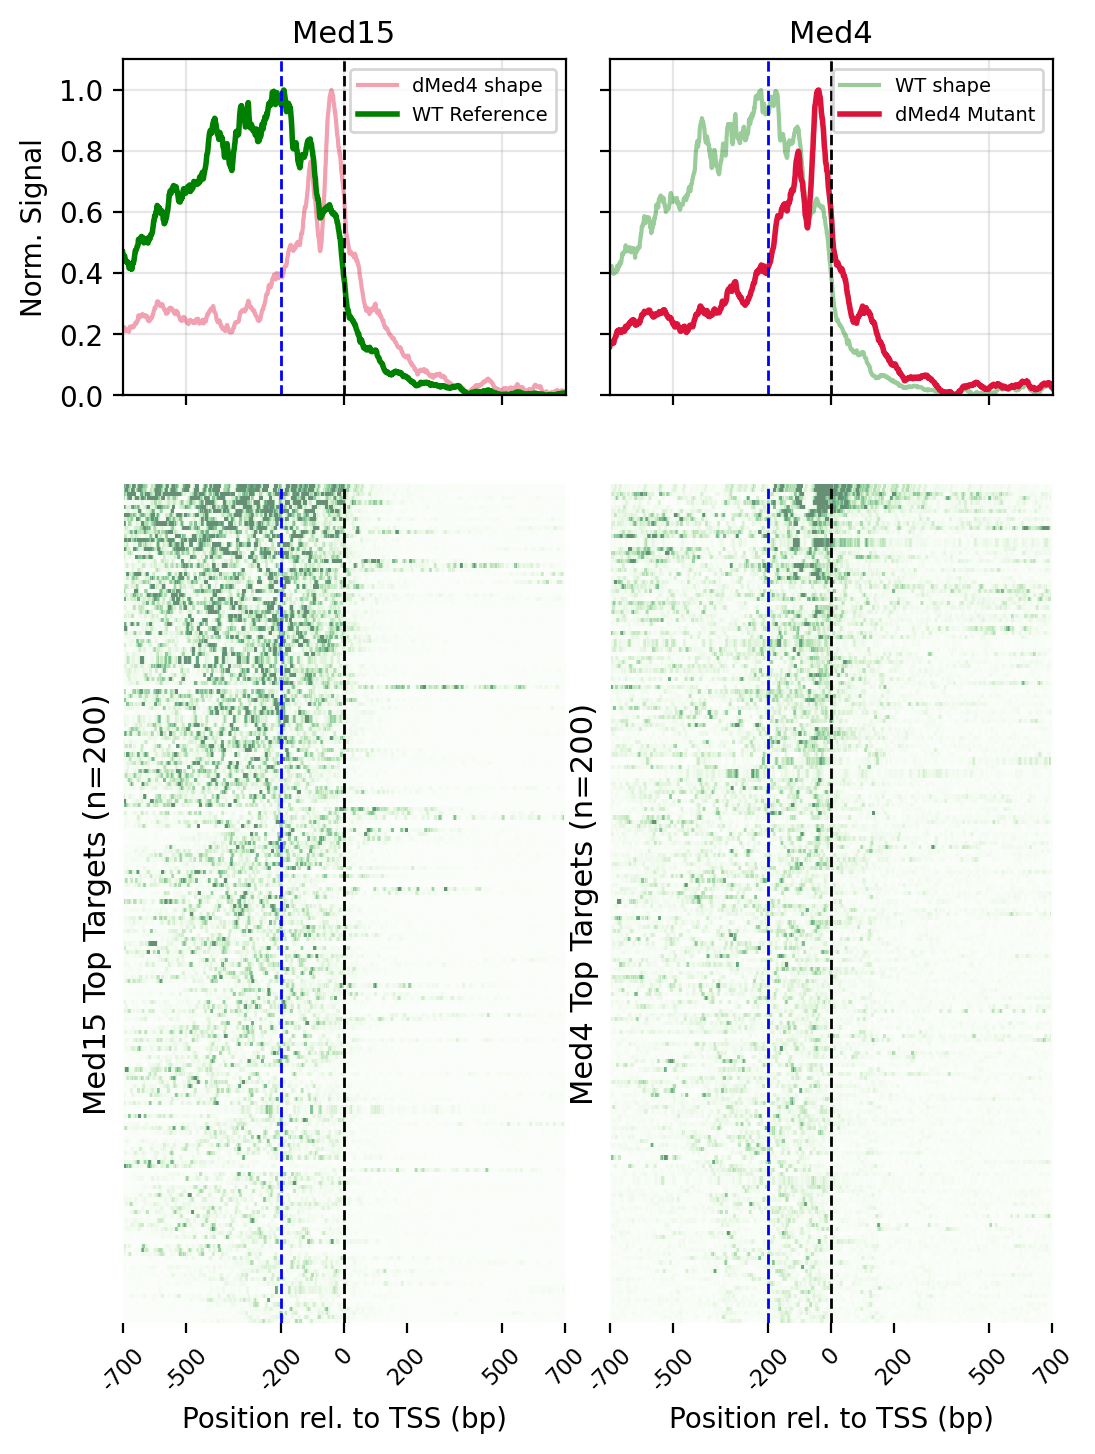

In [37]:
window_start, window_end = -700, 700
x_window = np.arange(window_start, window_end + 1) # Length: 1401
smoothing_window_meta = 30 
smoothing_window_heat = 10

reference_index = gp.index
promoter_binding_signals.columns = [str(c).replace("_2000bp_signals.gz", "") for c in promoter_binding_signals.columns]

# Find Columns
wt_strain_name = "Med15_WT_Mnase" 
med4_cols = [c for c in promoter_binding_signals.columns if any(m.lower() in str(c).lower() for m in ['med4_', '_med4', 'med4'])]
med4_strain_name = med4_cols[0] if med4_cols else None

if not med4_strain_name:
    raise ValueError("Could not find Med4 in promoter_binding_signals columns!")

def load_and_clean_data(strain_name):
    path = promoter_binding_signals[strain_name].loc["path"]
    df = pd.read_pickle(path).fillna(0)
    df.columns = range(-2000, 2000)
    return df

wt_df = load_and_clean_data(wt_strain_name)
med4_df = load_and_clean_data(med4_strain_name)


valid_wt_targets = wt_df.index.intersection(med15_top_targets)
valid_med4_targets = med4_df.index.intersection(med4_top_targets)

# Extract raw matrices restricted to the -700 to +700 window
wt_raw = wt_df.loc[valid_wt_targets, window_start:window_end]
med4_raw = med4_df.loc[valid_med4_targets, window_start:window_end]

# CROSS-TARGET MATRICES
med4_on_wt_raw = med4_df.loc[valid_wt_targets, window_start:window_end]
wt_on_med4_raw = wt_df.loc[valid_med4_targets, window_start:window_end]

# --- Calculate Normalized Metaprofiles ---
def get_norm_meta(df_raw):
    meta = df_raw.mean(axis=0).rolling(window=smoothing_window_meta, center=True, min_periods=1).mean()
    if meta.max() - meta.min() > 0:
        meta = (meta - meta.min()) / (meta.max() - meta.min())
    return meta

# Main profiles
wt_meta = get_norm_meta(wt_raw)
med4_meta = get_norm_meta(med4_raw)

# Background profiles
med4_cross_meta = get_norm_meta(med4_on_wt_raw)
wt_cross_meta = get_norm_meta(wt_on_med4_raw)

# --- Calculate Heatmap Matrices ---
wt_heat = wt_raw.T.rolling(window=smoothing_window_heat, center=True).mean().T.fillna(0)

med4_heat = med4_raw.T.rolling(window=smoothing_window_heat, center=True).mean().T.fillna(0)

# Sort each heatmap INDEPENDENTLY by its own signal strength
wt_sort_order = wt_heat.sum(axis=1).sort_values(ascending=False).index
wt_heat = wt_heat.loc[wt_sort_order]

med4_sort_order = med4_heat.sum(axis=1).sort_values(ascending=False).index
med4_heat = med4_heat.loc[med4_sort_order]



# 4. Plotting

fig = plt.figure(figsize=(6, 8))
gs = fig.add_gridspec(2, 2, height_ratios=[1, 2.5], width_ratios=[1, 1], hspace=0.15, wspace=0.1)

ax_meta_wt = fig.add_subplot(gs[0, 0])
ax_meta_med4 = fig.add_subplot(gs[0, 1], sharey=ax_meta_wt)
ax_heat_wt = fig.add_subplot(gs[1, 0])

ax_heat_med4 = fig.add_subplot(gs[1, 1])

wt_color = 'green'

# --- PANEL A: WT Metaprofile ---
# Plot background (Med4 on WT targets)
ax_meta_wt.plot(x_window, med4_cross_meta.values, color='crimson', linewidth=1.5, alpha=0.4, label='dMed4 shape', rasterized=True)
# Plot main (WT on WT targets)
ax_meta_wt.plot(x_window, wt_meta.values, color=wt_color, linewidth=2, label='WT Reference', rasterized=True)

ax_meta_wt.set_title("Med15", fontsize=11)
ax_meta_wt.set_ylabel("Norm. Signal", fontsize=10)
ax_meta_wt.legend(loc='upper right', fontsize=7)

# --- PANEL B: Med4 Metaprofile ---
# Plot background (WT on Med4 targets)
ax_meta_med4.plot(x_window, wt_cross_meta.values, color=wt_color, linewidth=1.5, alpha=0.4, label='WT shape', rasterized=True)
# Plot main (Med4 on Med4 targets)
ax_meta_med4.plot(x_window, med4_meta.values, color='crimson', linewidth=2, label='dMed4 Mutant', rasterized=True)

ax_meta_med4.set_title("Med4", fontsize=11)
ax_meta_med4.tick_params(labelleft=False)
ax_meta_med4.legend(loc='upper right', fontsize=7)

# Format both metaprofiles
for ax in [ax_meta_wt, ax_meta_med4]:
    ax.axvline(0, color='black', linestyle='--', linewidth=1)
    ax.axvline(-200, color='blue', linestyle='--', linewidth=1)
    ax.set_xlim(window_start, window_end)
    ax.set_ylim(0, 1.1)
    # Hide X-ticks to merge visually with heatmap
    ax.tick_params(labelbottom=False) 
    ax.grid(True, alpha=0.3)

# --- PANEL C: WT Heatmap ---
sns.heatmap(
    wt_heat, cmap=pastel_cmap, ax=ax_heat_wt, 
    cbar=False, yticklabels=False, xticklabels=False, 
    vmax=100, rasterized=True
)
# Update Y-label to specify Med15 targets
ax_heat_wt.set_ylabel(f"Med15 Top Targets (n={len(valid_wt_targets)})", fontsize=11)

# --- PANEL D: Med4 Heatmap ---
sns.heatmap(
    med4_heat, cmap=pastel_cmap, ax=ax_heat_med4, 
    cbar=False, yticklabels=False, xticklabels=False, 
    vmax=40, rasterized=True
)
# Update Y-label to specify Med4 targets
ax_heat_med4.set_ylabel(f"Med4 Top Targets (n={len(valid_med4_targets)})", fontsize=11)

# Format Heatmap Axes
idx_TSS = 700 # 0 bp position
idx_UAS = 500 # -200 bp position

for ax in [ax_heat_wt, ax_heat_med4]:
    ax.axvline(idx_TSS, color='black', linestyle='--', linewidth=1)
    ax.axvline(idx_UAS, color='blue', linestyle='--', linewidth=1)
    
    # Map the ticks correctly to base pairs for a -700 to 700 window
    ticks_locs = [0, 200, 500, 700, 900, 1200, 1400]
    ticks_labels = [-700, -500, -200, 0, 200, 500, 700]
    ax.set_xticks(ticks_locs)
    ax.set_xticklabels(ticks_labels, rotation=45, fontsize=8)
    ax.set_xlabel("Position rel. to TSS (bp)", fontsize=10)

plt.tight_layout()
plt.subplots_adjust(top=0.9)
plt.show()

## Figure 1C

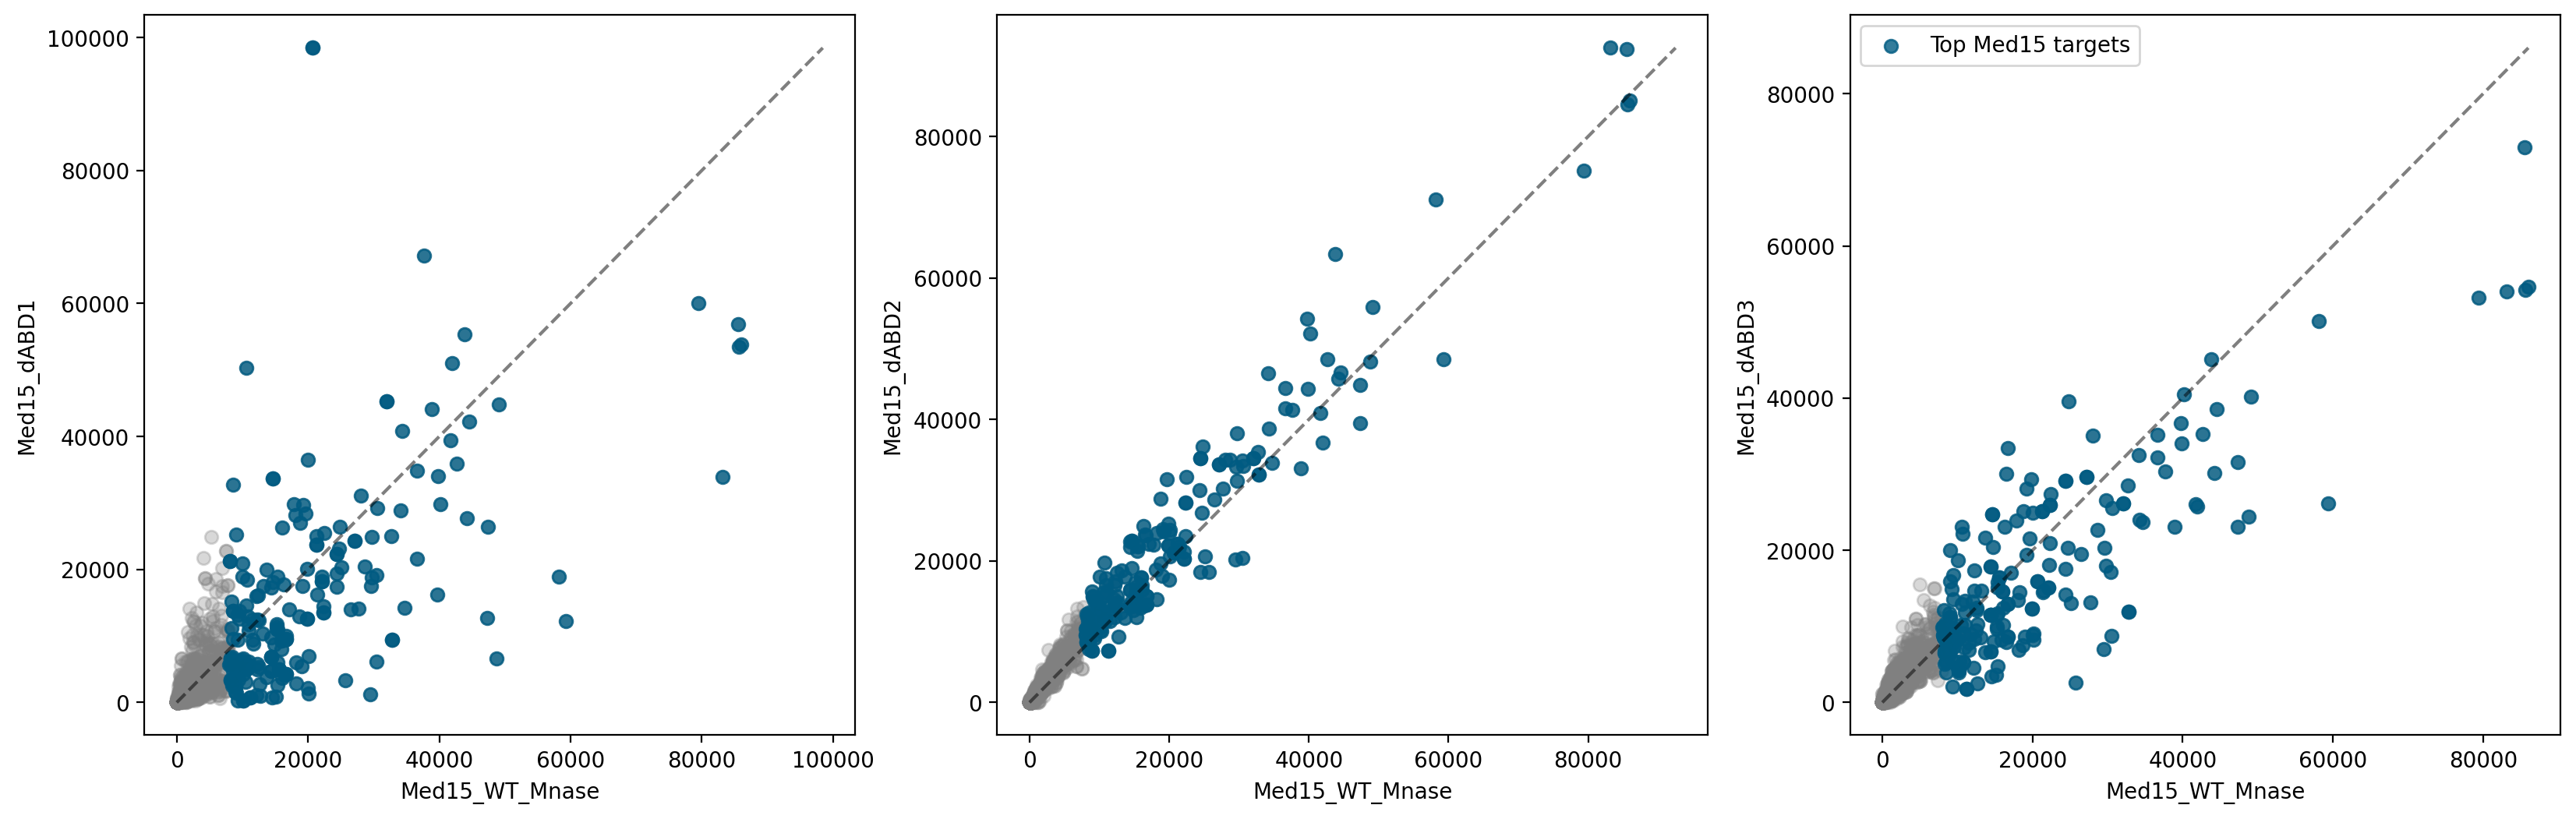

In [38]:
fig, axes = plt.subplots(1,3, figsize=(20, 6))
axes[0].scatter(WT_system_data['Med15_WT_Mnase'], WT_system_data['Med15_dABD1'], 
        alpha=0.3, 
        color='grey'
    )
axes[0].scatter(
        WT_system_data['Med15_WT_Mnase'].loc[med15_top_targets], WT_system_data['Med15_dABD1'].loc[med15_top_targets],
        alpha=0.8, 
        color='#005b82', edgecolor='#005b82',
        label='Top Med15 targets'
    )

max_val = max(WT_system_data['Med15_WT_Mnase'].max(), WT_system_data['Med15_dABD1'].max())
axes[0].plot([0, max_val], [0, max_val], '--', color='black', alpha=0.5)
    
axes[0].set_xlabel('Med15_WT_Mnase')
axes[0].set_ylabel('Med15_dABD1')

axes[1].scatter(WT_system_data['Med15_WT_Mnase'], WT_system_data['Med15_dABD2'], 
        alpha=0.3, 
        color='grey'
    )
axes[1].scatter(
        WT_system_data['Med15_WT_Mnase'].loc[med15_top_targets], WT_system_data['Med15_dABD2'].loc[med15_top_targets],
        alpha=0.8, 
        color='#005b82', edgecolor='#005b82',
        label='Top Med15 targets'
    )

max_val = max(WT_system_data['Med15_WT_Mnase'].max(), WT_system_data['Med15_dABD2'].max())
axes[1].plot([0, max_val], [0, max_val], '--', color='black', alpha=0.5)
    
axes[1].set_xlabel('Med15_WT_Mnase')
axes[1].set_ylabel('Med15_dABD2')

axes[2].scatter(WT_system_data['Med15_WT_Mnase'], WT_system_data['Med15_dABD3'], 
        alpha=0.3, 
        color='grey'
    )
axes[2].scatter(
        WT_system_data['Med15_WT_Mnase'].loc[med15_top_targets], WT_system_data['Med15_dABD3'].loc[med15_top_targets],
        alpha=0.8, 
        color='#005b82', edgecolor='#005b82',
        label='Top Med15 targets'
    )

max_val = max(WT_system_data['Med15_WT_Mnase'].max(), WT_system_data['Med15_dABD3'].max())
axes[2].plot([0, max_val], [0, max_val], '--', color='black', alpha=0.5)
    
axes[2].set_xlabel('Med15_WT_Mnase')
axes[2].set_ylabel('Med15_dABD3')
plt.legend()

plt.show()

## Figure 1D

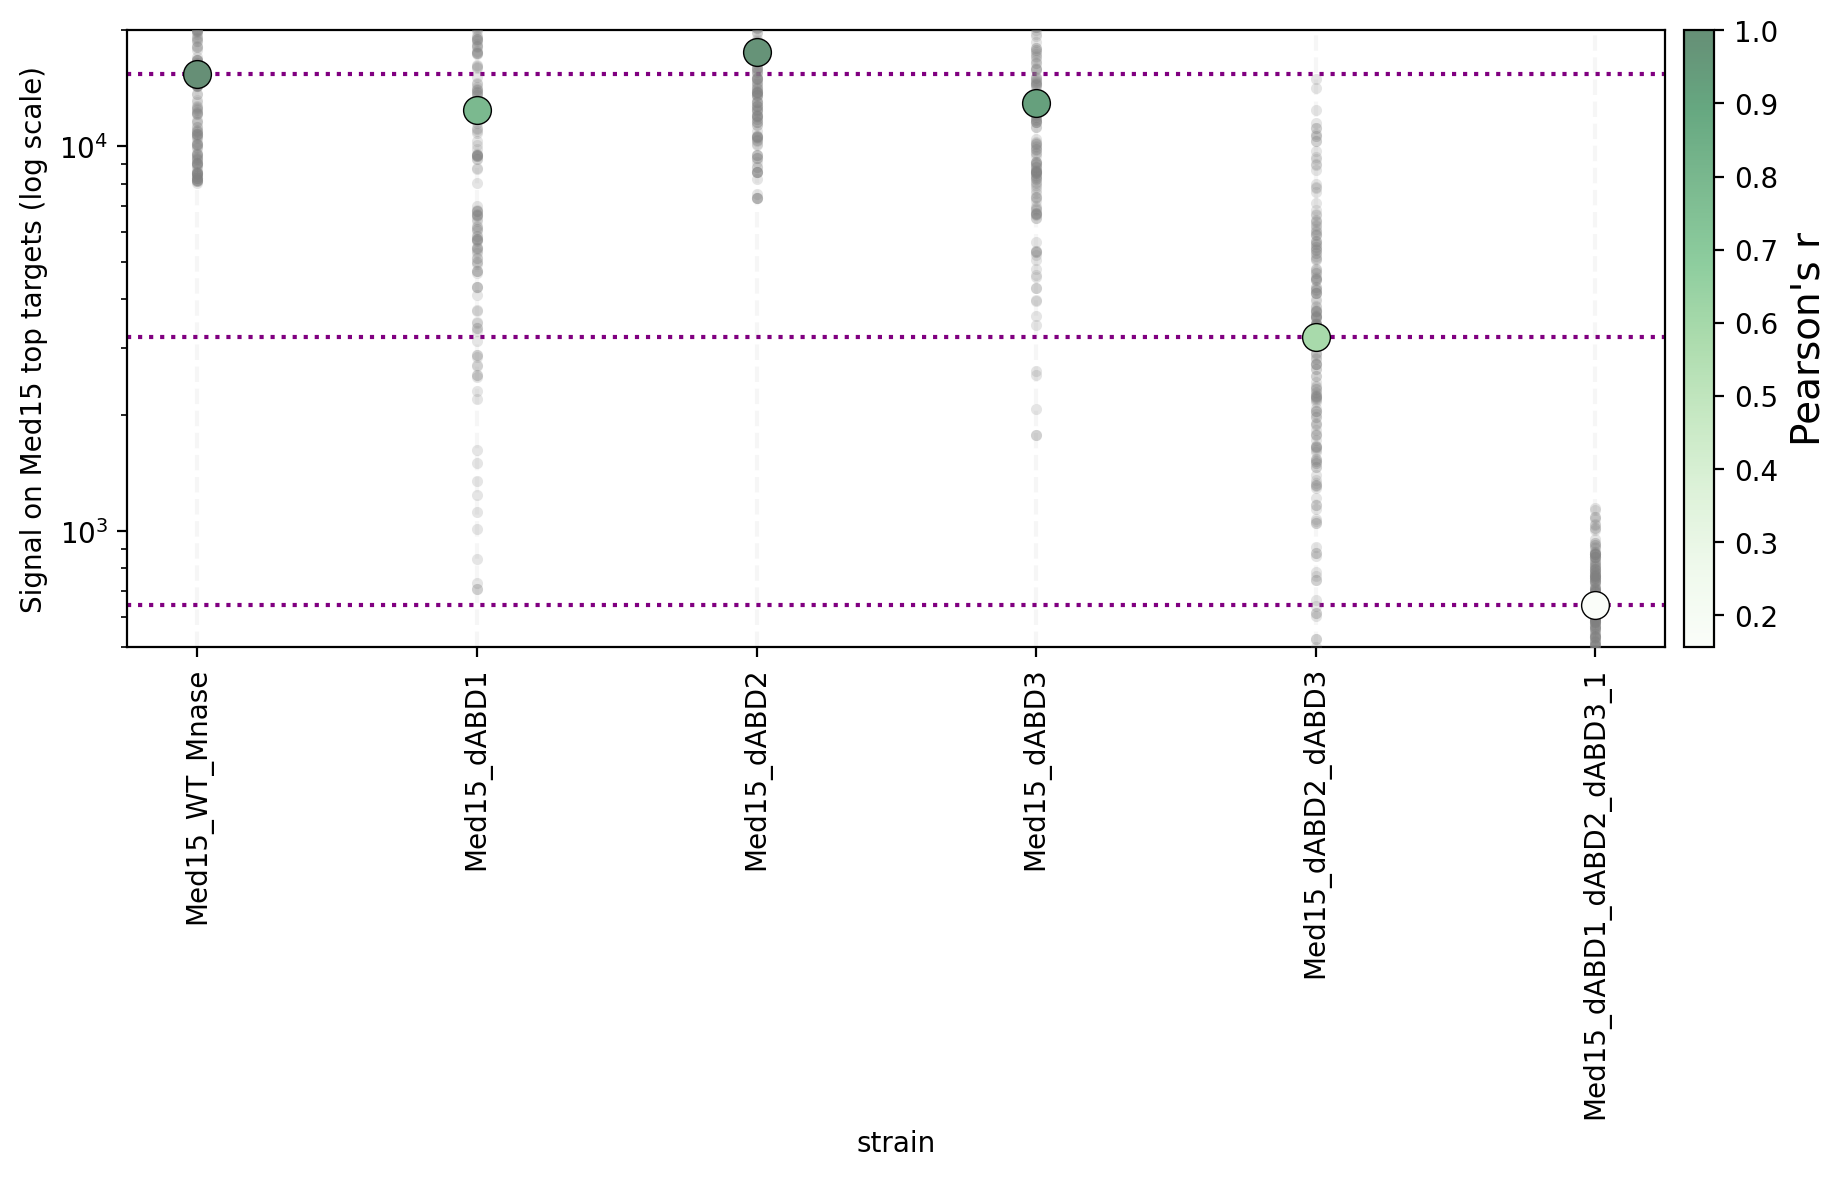

In [39]:
dABDs = WT_system_data[['Med15_WT_Mnase', 'Med15_dABD1', 'Med15_dABD2', 'Med15_dABD3','Med15_dABD2_dABD3','Med15_dABD1_dABD2_dABD3_1']]
df_top = dABDs.loc[med15_top_targets].copy()
df_top['gene'] = df_top.index

df_long = df_top.melt(
    id_vars='gene',
    var_name='strain',
    value_name='signal'
).dropna()


median_df = (
    df_long
    .groupby('strain')['signal']
    .median()
    .reset_index(name='median_signal')
)


WT_col = 'Med15_WT_Mnase'
corr_with_WT = dABDs[dABDs.columns].corr()[WT_col]
corr_with_WT = corr_with_WT.reindex(dABDs.columns)  # ensure same order


median_df['corr_to_WT'] = median_df['strain'].map(corr_with_WT)


median_df = median_df.set_index('strain').reindex(dABDs.columns).reset_index()


norm = Normalize(
    vmin=median_df['corr_to_WT'].min(),
    vmax=median_df['corr_to_WT'].max()
)



plt.figure(figsize=(10, 6))


sns.stripplot(
    data=df_long,
    x='strain',
    y='signal',
    order=dABDs.columns,       
    color='grey',
    alpha=0.2,
    jitter=False,              
    size=4
)


for _, row in median_df.iterrows():
    if pd.isna(row['median_signal']):
        continue  
    plt.scatter(
        x=row['index'],
        y=row['median_signal'],
        color=pastel_cmap(norm(row['corr_to_WT'])),
        edgecolor='black',
        s=100,
        linewidth=0.5,
        zorder=10
    )


for strain in dABDs.columns:
    plt.axvline(x=strain, color='lightgrey', linestyle='--', alpha=0.2)



target_strain = 'Med15_dABD1_dABD2_dABD3_1'
subset = median_df.loc[median_df['index'] == target_strain, 'median_signal']
med15_N600_avg = subset.mean() if not subset.empty else None
if med15_N600_avg is not None:
    plt.axhline(med15_N600_avg, color='purple', linestyle=':', label=f'{target_strain} binding profile')

target_strain = 'Med15_WT_Mnase'
subset = median_df.loc[median_df['index'] == target_strain, 'median_signal']
med15_N600_avg = subset.mean() if not subset.empty else None
if med15_N600_avg is not None:
    plt.axhline(med15_N600_avg, color='purple', linestyle=':', label=f'{target_strain} binding profile')

target_strain = 'Med15_dABD2_dABD3'
subset = median_df.loc[median_df['index'] == target_strain, 'median_signal']
med15_N600_avg = subset.mean() if not subset.empty else None
if med15_N600_avg is not None:
    plt.axhline(med15_N600_avg, color='purple', linestyle=':', label=f'{target_strain} binding profile')


sm = cm.ScalarMappable(norm=norm, cmap=pastel_cmap)
cbar = plt.colorbar(sm, ax=plt.gca(), pad=0.01) 
cbar.set_label("Pearson's r", fontsize=14)


plt.xticks(rotation=90)
plt.ylim(500,20000)
plt.yscale('log')
plt.ylabel('Signal on Med15 top targets (log scale)')
plt.tight_layout()
plt.show()


## Figure 1E

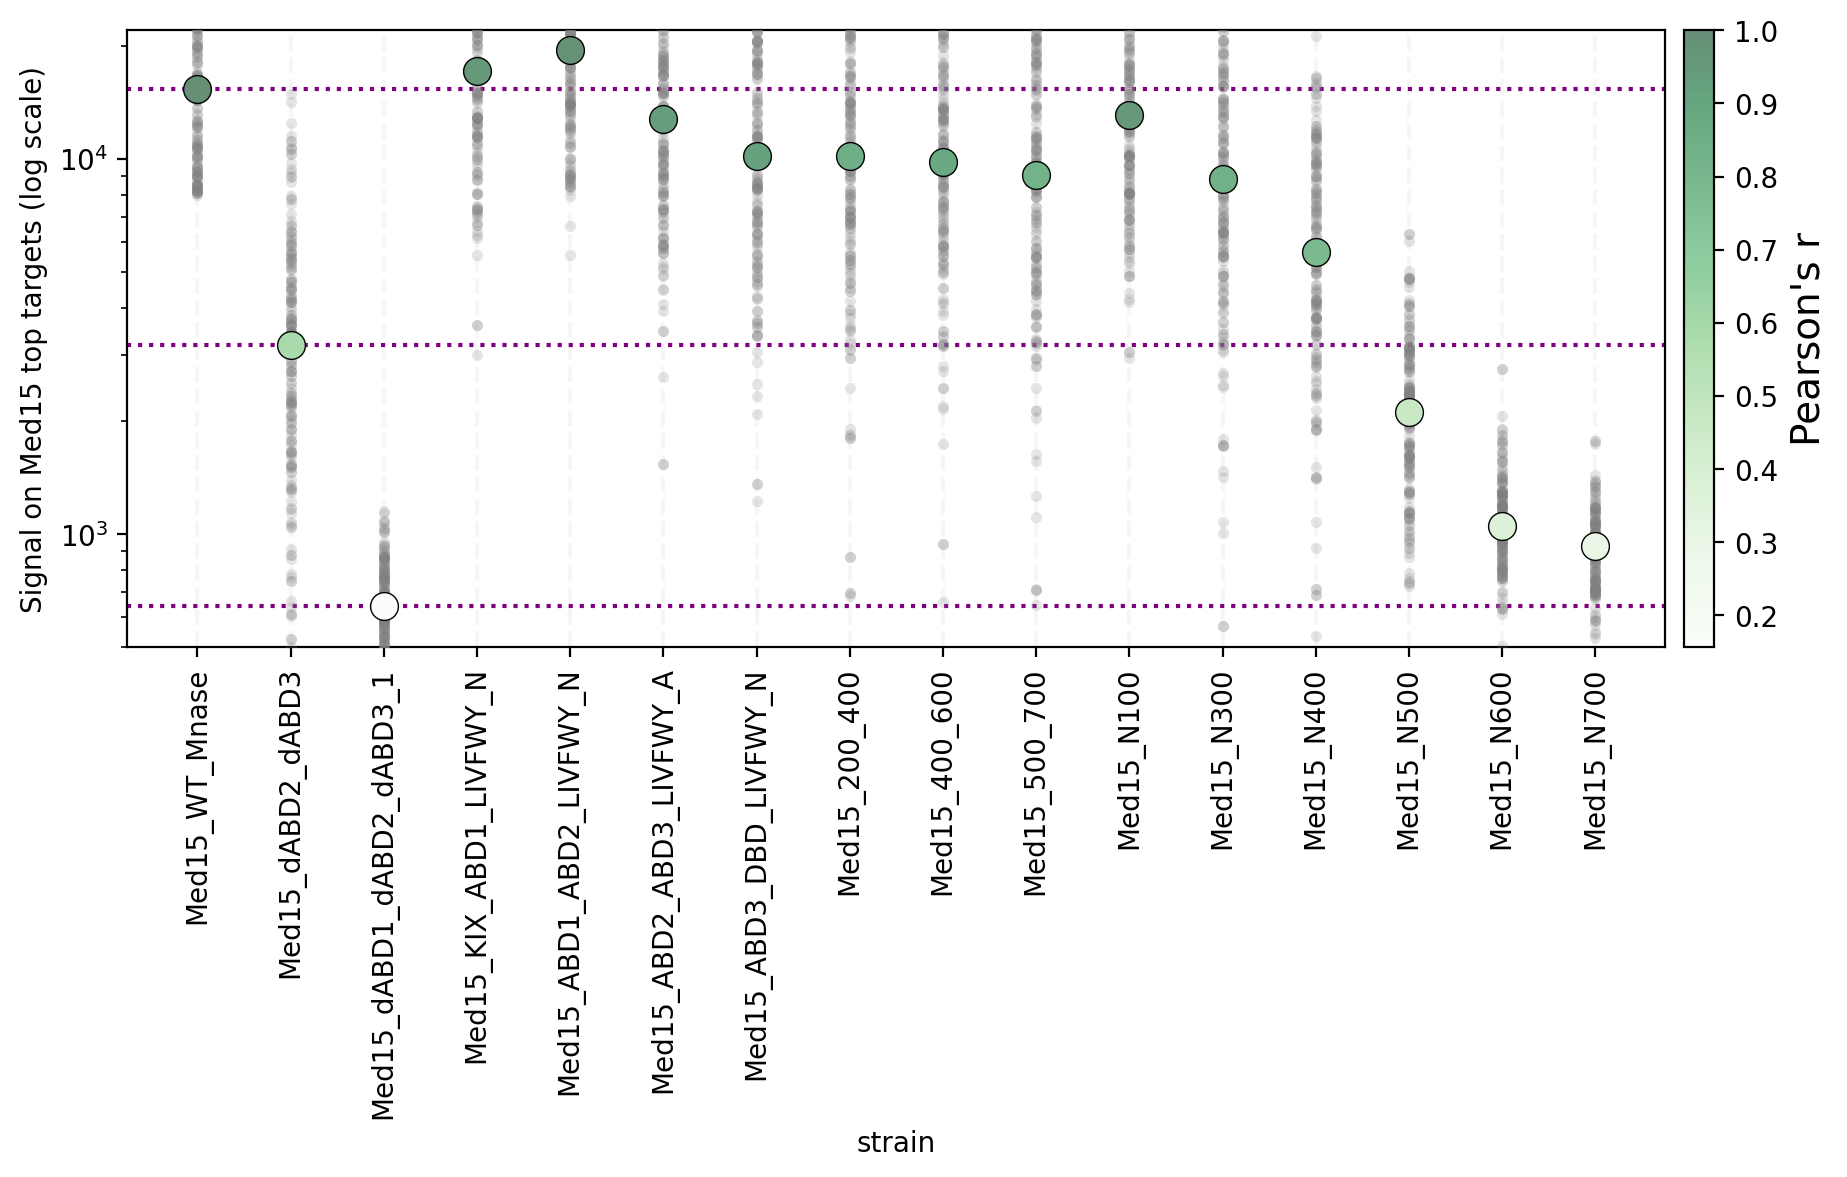

In [42]:
dABDs = WT_system_data[['Med15_WT_Mnase','Med15_dABD2_dABD3','Med15_dABD1_dABD2_dABD3_1', 'Med15_KIX_ABD1_LIVFWY_N','Med15_ABD1_ABD2_LIVFWY_N', 'Med15_ABD2_ABD3_LIVFWY_A','Med15_ABD3_DBD_LIVFWY_N','Med15_200_400', 'Med15_400_600', 'Med15_500_700','Med15_N100', 'Med15_N300', 'Med15_N400', 'Med15_N500','Med15_N600','Med15_N700']]
df_top = dABDs.loc[med15_top_targets].copy()
df_top['gene'] = df_top.index

df_long = df_top.melt(
    id_vars='gene',
    var_name='strain',
    value_name='signal'
).dropna()


median_df = (
    df_long
    .groupby('strain')['signal']
    .median()
    .reset_index(name='median_signal')
)


WT_col = 'Med15_WT_Mnase'
corr_with_WT = dABDs[dABDs.columns].corr()[WT_col]
corr_with_WT = corr_with_WT.reindex(dABDs.columns)  # ensure same order


median_df['corr_to_WT'] = median_df['strain'].map(corr_with_WT)


median_df = median_df.set_index('strain').reindex(dABDs.columns).reset_index()


norm = Normalize(
    vmin=median_df['corr_to_WT'].min(),
    vmax=median_df['corr_to_WT'].max()
)



plt.figure(figsize=(10, 6))


sns.stripplot(
    data=df_long,
    x='strain',
    y='signal',
    order=dABDs.columns,       
    color='grey',
    alpha=0.2,
    jitter=False,              
    size=4
)


for _, row in median_df.iterrows():
    if pd.isna(row['median_signal']):
        continue  
    plt.scatter(
        x=row['index'],
        y=row['median_signal'],
        color=pastel_cmap(norm(row['corr_to_WT'])),
        edgecolor='black',
        s=100,
        linewidth=0.5,
        zorder=10
    )


for strain in dABDs.columns:
    plt.axvline(x=strain, color='lightgrey', linestyle='--', alpha=0.2)



target_strain = 'Med15_dABD1_dABD2_dABD3_1'
subset = median_df.loc[median_df['index'] == target_strain, 'median_signal']
med15_N600_avg = subset.mean() if not subset.empty else None
if med15_N600_avg is not None:
    plt.axhline(med15_N600_avg, color='purple', linestyle=':', label=f'{target_strain} binding profile')

target_strain = 'Med15_WT_Mnase'
subset = median_df.loc[median_df['index'] == target_strain, 'median_signal']
med15_N600_avg = subset.mean() if not subset.empty else None
if med15_N600_avg is not None:
    plt.axhline(med15_N600_avg, color='purple', linestyle=':', label=f'{target_strain} binding profile')

target_strain = 'Med15_dABD2_dABD3'
subset = median_df.loc[median_df['index'] == target_strain, 'median_signal']
med15_N600_avg = subset.mean() if not subset.empty else None
if med15_N600_avg is not None:
    plt.axhline(med15_N600_avg, color='purple', linestyle=':', label=f'{target_strain} binding profile')


sm = cm.ScalarMappable(norm=norm, cmap=pastel_cmap)
cbar = plt.colorbar(sm, ax=plt.gca(), pad=0.01) 
cbar.set_label("Pearson's r", fontsize=14)


plt.xticks(rotation=90)
plt.yscale('log')
plt.ylim(500,22000)
plt.ylabel('Signal on Med15 top targets (log scale)')
plt.tight_layout()
plt.show()


# Figure 2

## Figure 2A

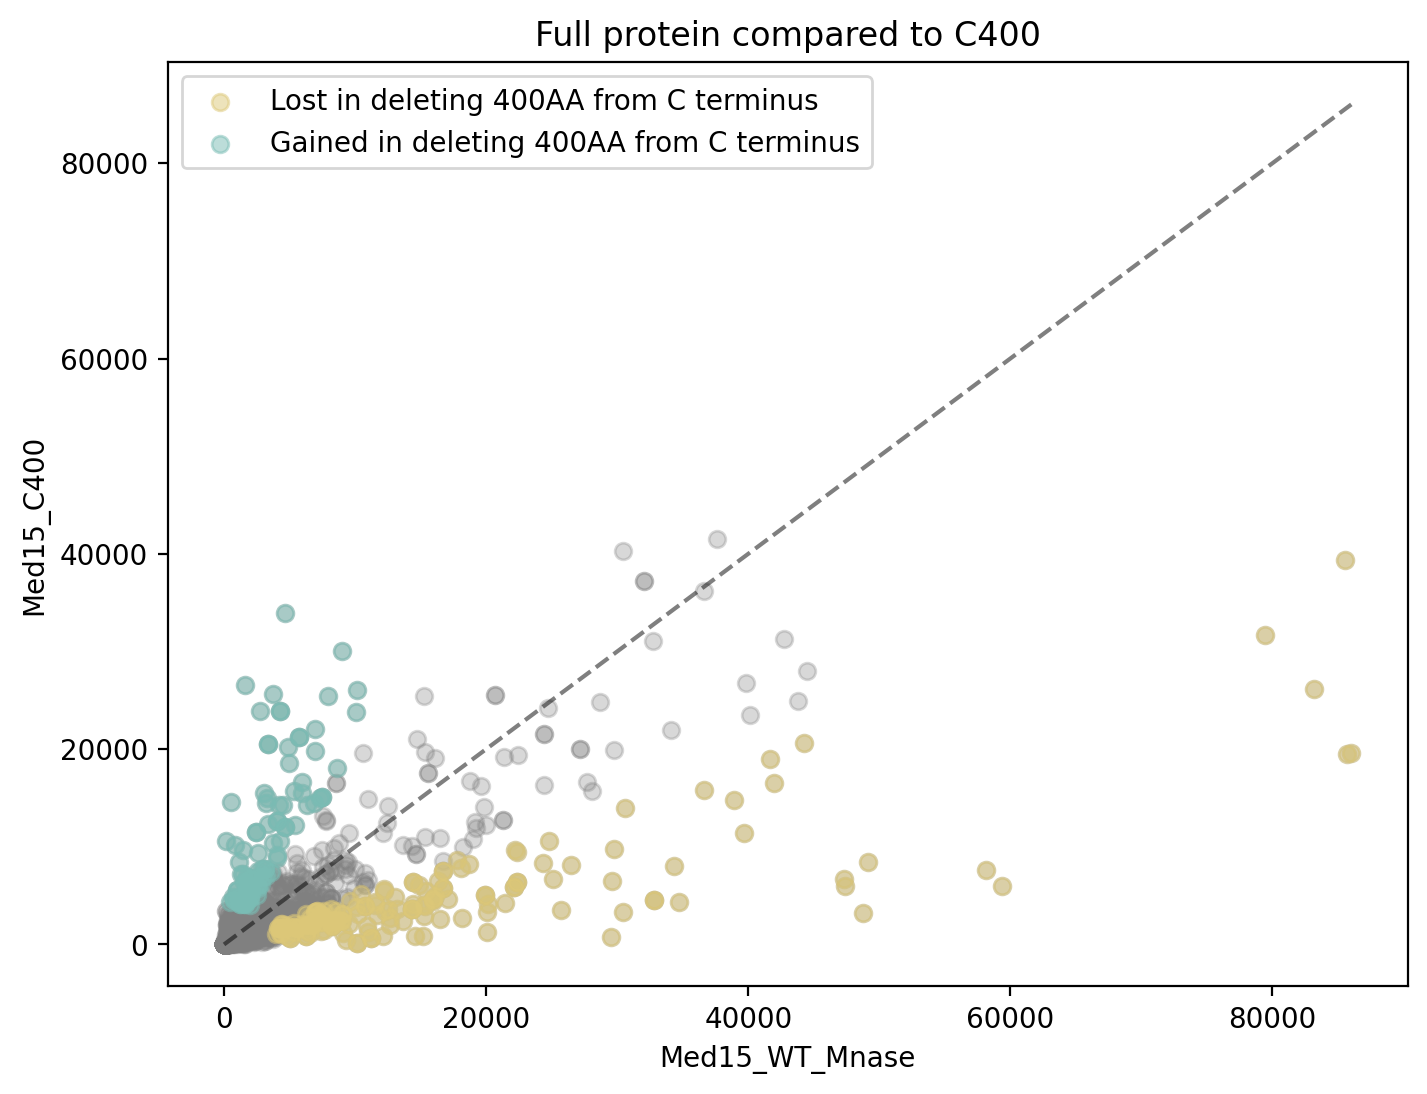

In [43]:
fig, axes = plt.subplots(1, figsize=(8, 6))
plt.scatter(WT_system_data['Med15_WT_Mnase'], WT_system_data['Med15_C400'], 
        alpha=0.3, 
        color='grey'
    )
plt.scatter(
        WT_system_data['Med15_WT_Mnase'].loc[lost_in_dC], WT_system_data['Med15_C400'].loc[lost_in_dC],
        alpha=0.5, 
        color='#DDC878', edgecolor='#DDC878',
        label='Lost in deleting 400AA from C terminus'
    )
plt.scatter(
        WT_system_data['Med15_WT_Mnase'].loc[gained_in_dC], WT_system_data['Med15_C400'].loc[gained_in_dC],
        alpha=0.5, 
        color='#7ABDB5', edgecolor='#7ABDB5',
        label='Gained in deleting 400AA from C terminus'
    )
max_val = max(WT_system_data['Med15_C400'].max(), WT_system_data['Med15_WT_Mnase'].max())
plt.plot([0, max_val], [0, max_val], '--', color='black', alpha=0.5)
    
plt.ylabel('Med15_C400')
plt.xlabel('Med15_WT_Mnase')
plt.legend()
plt.title(f'Full protein compared to C400')
plt.show()

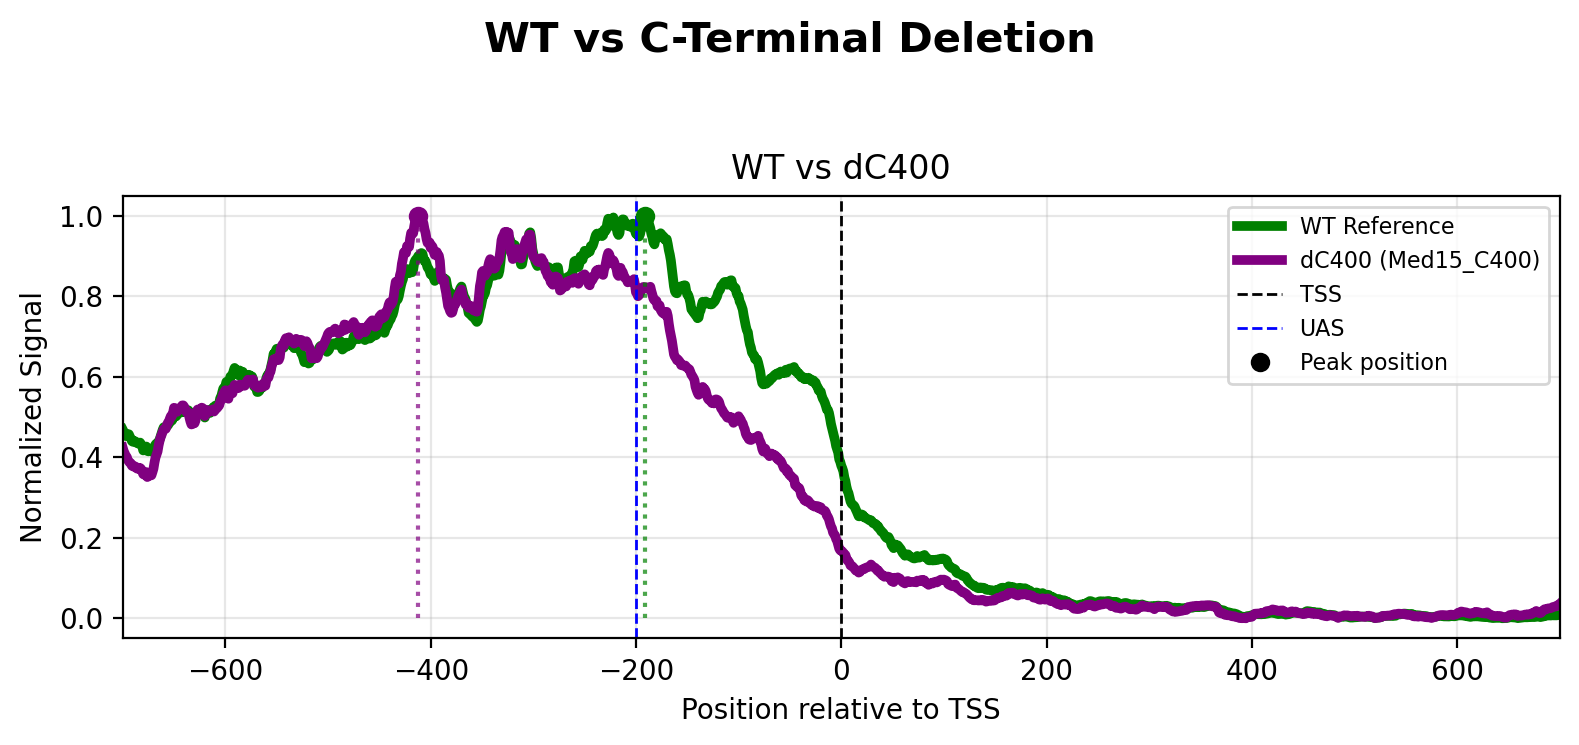

In [44]:
# 1. Define window and x-axis
window_start = -700
window_end = 700
x = np.arange(-700, 701)

# Smoothing parameter (in base pairs)
smoothing_window = 30 

# Define your reference index 
reference_index = gp.index

# ONLY plot on the Top Med15 targets
target_genes = med15_top_targets

# Clean up the strain names in the dataframe columns for cleaner plot titles
promoter_binding_signals.columns = [str(c).replace("_2000bp_signals.gz", "") for c in promoter_binding_signals.columns]

# 3. Pre-load the Wild-Type reference data ONCE for efficiency
wt_strain_name = "Med15_WT_Mnase" 
wt_path = promoter_binding_signals[wt_strain_name].loc["path"]
wt_df = pd.read_pickle(wt_path).fillna(0)

# --- FIX: Paste index and columns for WT if needed ---
if isinstance(wt_df.index, pd.RangeIndex) or wt_df.index.dtype == 'int64':
    if len(wt_df) == len(reference_index):
        wt_df.index = reference_index
    else:
        print(f"Warning: {wt_strain_name} length ({len(wt_df)}) mismatch with reference")

if wt_df.columns.min() == 0 and wt_df.columns.max() == wt_df.shape[1] - 1:
    start_col = -(wt_df.shape[1] // 2)
    wt_df.columns = range(start_col, start_col + wt_df.shape[1])


# ==========================================
# HELPER FUNCTIONS
# ==========================================
def get_normalized_metaprofile(df, genes):
    """Subsets the dataframe to valid genes, calculates the smoothed mean, and normalizes 0 to 1."""
    valid_genes = df.index.intersection(genes)
    subset = df.loc[valid_genes, window_start:window_end]
    if subset.empty:
        return None
    
    meta = subset.mean(axis=0).rolling(window=smoothing_window, center=True, min_periods=1).mean()
    c_min, c_max = meta.min(), meta.max()
    if c_max - c_min > 0:
        meta = (meta - c_min) / (c_max - c_min)
    return meta

def find_col(match_strings):
    """Safely finds the column name in promoter_binding_signals containing the target substring."""
    for c in promoter_binding_signals.columns:
        if any(m.lower() in str(c).lower() for m in match_strings):
            return c
    return match_strings[0] # Fallback to prevent crash

# Calculate the WT metaprofile globally since it's used in every plot
wt_meta = get_normalized_metaprofile(wt_df, target_genes)

def plot_metaprofile_group(fig_title, mutants_dict, wt_color='green'):
    """Generates a figure with subplots comparing WT against a specific dictionary of mutants."""
    n_plots = max(1, len(mutants_dict))
    fig, axes = plt.subplots(n_plots, 1, figsize=(8, 3.5 * n_plots), sharex=True)
    if n_plots == 1:
        axes = [axes]
        
    fig.suptitle(fig_title, fontsize=15, y=0.98 if n_plots > 1 else 1.05, fontweight='bold')
    
    # CASE 1: Plotting WT Alone
    if not mutants_dict:
        ax = axes[0]
        ax.plot(x, wt_meta.values, color=wt_color, linewidth=2, label='WT Reference', rasterized=True)
        
        # Plot peak
        peak_x_wt = x[np.argmax(wt_meta.values)]
        ax.plot(peak_x_wt, 1.0, 'o', color=wt_color, markersize=6, zorder=5, rasterized=True)
        ax.vlines(x=peak_x_wt, ymin=0, ymax=1.0, color=wt_color, linestyle=':', linewidth=1.5, alpha=0.7, rasterized=True)
        
        ax.set_title("Metaprofile on Top Med15 Targets")
        ax.set_ylabel("Normalized Signal")
        ax.axvline(0, color='black', linestyle='--', linewidth=1, label='TSS')
        ax.axvline(-200, color='blue', linestyle='--', linewidth=1, label='UAS')
        ax.plot([], [], 'o', color='black', label='Peak position') # Added to legend
        ax.grid(True, alpha=0.3)
        ax.legend(loc='upper right')
        
    # CASE 2: Plotting Mutants vs WT
    else:
        colors = ['purple', 'orange', 'dodgerblue', 'crimson']
        for i, ((mut_label, mut_col), ax) in enumerate(zip(mutants_dict.items(), axes)):
            
            if mut_col not in promoter_binding_signals.columns:
                ax.text(0.5, 0.5, f"Strain '{mut_col}' not found in data", ha='center')
                continue
                
            path = promoter_binding_signals[mut_col].loc["path"]
            mut_df = pd.read_pickle(path).fillna(0)

            # Fix mutant index/columns if needed
            if isinstance(mut_df.index, pd.RangeIndex) or mut_df.index.dtype == 'int64':
                if len(mut_df) == len(reference_index):
                    mut_df.index = reference_index
            if mut_df.columns.min() == 0 and mut_df.columns.max() == mut_df.shape[1] - 1:
                start_col = -(mut_df.shape[1] // 2)
                mut_df.columns = range(start_col, start_col + mut_df.shape[1])

            mut_meta = get_normalized_metaprofile(mut_df, target_genes)
            
            if mut_meta is None:
                ax.text(0.5, 0.5, "No genes found", ha='center')
                continue

            # Plotting the lines
            ax.plot(x, wt_meta.values, color=wt_color, linewidth=3.5, label='WT Reference', rasterized=True)
            ax.plot(x, mut_meta.values, color=colors[i%len(colors)], linewidth=3.5, label=f"{mut_label} ({mut_col})", rasterized=True)
            
            # --- Visualizing the Peak Shift ---
            peak_x_wt = x[np.argmax(wt_meta.values)]
            peak_x_curr = x[np.argmax(mut_meta.values)]
            
            ax.plot(peak_x_wt, 1.0, 'o', color=wt_color, markersize=6, zorder=5, rasterized=True)
            ax.plot(peak_x_curr, 1.0, 'o', color=colors[i%len(colors)], markersize=6, zorder=5, rasterized=True)
            
            ax.vlines(x=peak_x_wt, ymin=0, ymax=1.0, color=wt_color, linestyle=':', linewidth=1.5, alpha=0.7, rasterized=True)
            ax.vlines(x=peak_x_curr, ymin=0, ymax=1.0, color=colors[i%len(colors)], linestyle=':', linewidth=1.5, alpha=0.7, rasterized=True)

            # Subplot formatting
            ax.set_title(f"WT vs {mut_label}")
            ax.set_ylabel("Normalized Signal")
            ax.axvline(0, color='black', linestyle='--', linewidth=1, label='TSS')
            ax.axvline(-200, color='blue', linestyle='--', linewidth=1, label='UAS')
            
            # Add proxy artist for peak position legend
            ax.plot([], [], 'o', color='black', label='Peak position')
            
            ax.grid(True, alpha=0.3)
            ax.legend(loc='upper right', fontsize=8)

    axes[-1].set_xlabel("Position relative to TSS")
    axes[-1].set_xlim(window_start, window_end)
    plt.tight_layout()
    if n_plots > 1:
        plt.subplots_adjust(top=0.92) 
    plt.show()

# ==========================================
# 4. EXECUTE PLOTS
# ==========================================


# 2. WT vs C-Terminal Mutants
c_term_mutants = {
    'dC400': find_col(['C400'])
}
plot_metaprofile_group("WT vs C-Terminal Deletion", mutants_dict=c_term_mutants, wt_color="green")


## Figure 2B

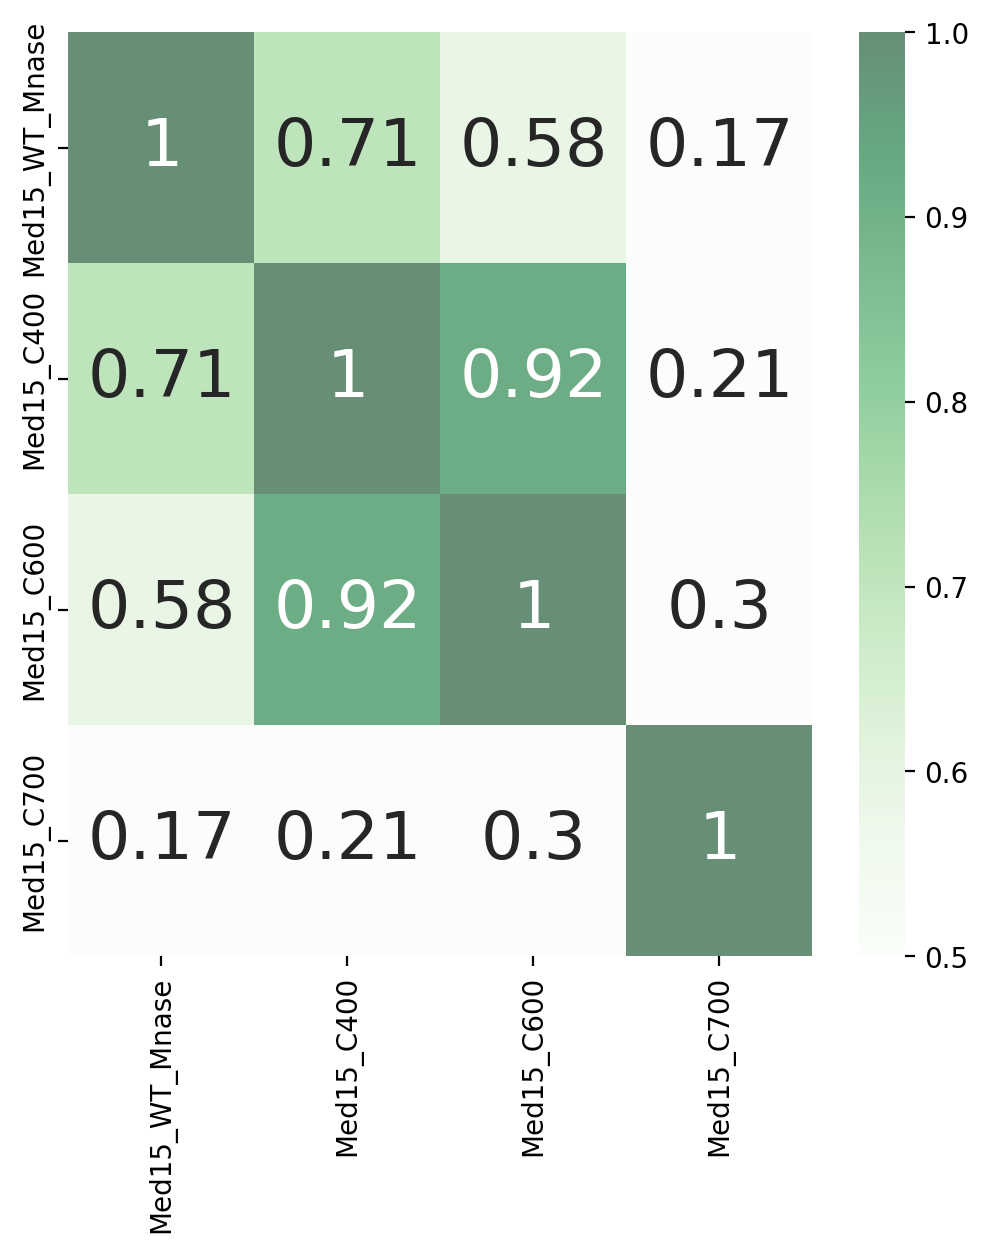

In [45]:
corr_matrix = WT_system_data.filter(regex='Med15_WT_Mnase|_C400|C600|C700').corr().abs()

filtered_corr_matrix = corr_matrix

plt.subplots(figsize=(6,6))
heatmap = sns.heatmap(filtered_corr_matrix, annot=True, fmt=".2g", cmap=pastel_cmap, vmax=1, vmin=0.5, annot_kws={"size": 24, 'rotation':0})

plt.show()

## Figure 2C

In [46]:
Figure_2C = WT_system_data[['Med15_WT_Mnase','Med15_C100', 'Med15_C200', 'Med15_C300',
       'Med15_C400', 'Med15_C600', 'Med15_C700','Med15_700_900','Med15_dDBD', 'Med15_800_1000',
       'Med15_900_1080','Med15_DBD_END_LIVFWY_N','Med15_Mnase_LIVFWY_Shift_DBD_END', 'Med15_DBD_END_QN_G',
       'Med15_DBD_END_Q_N']]

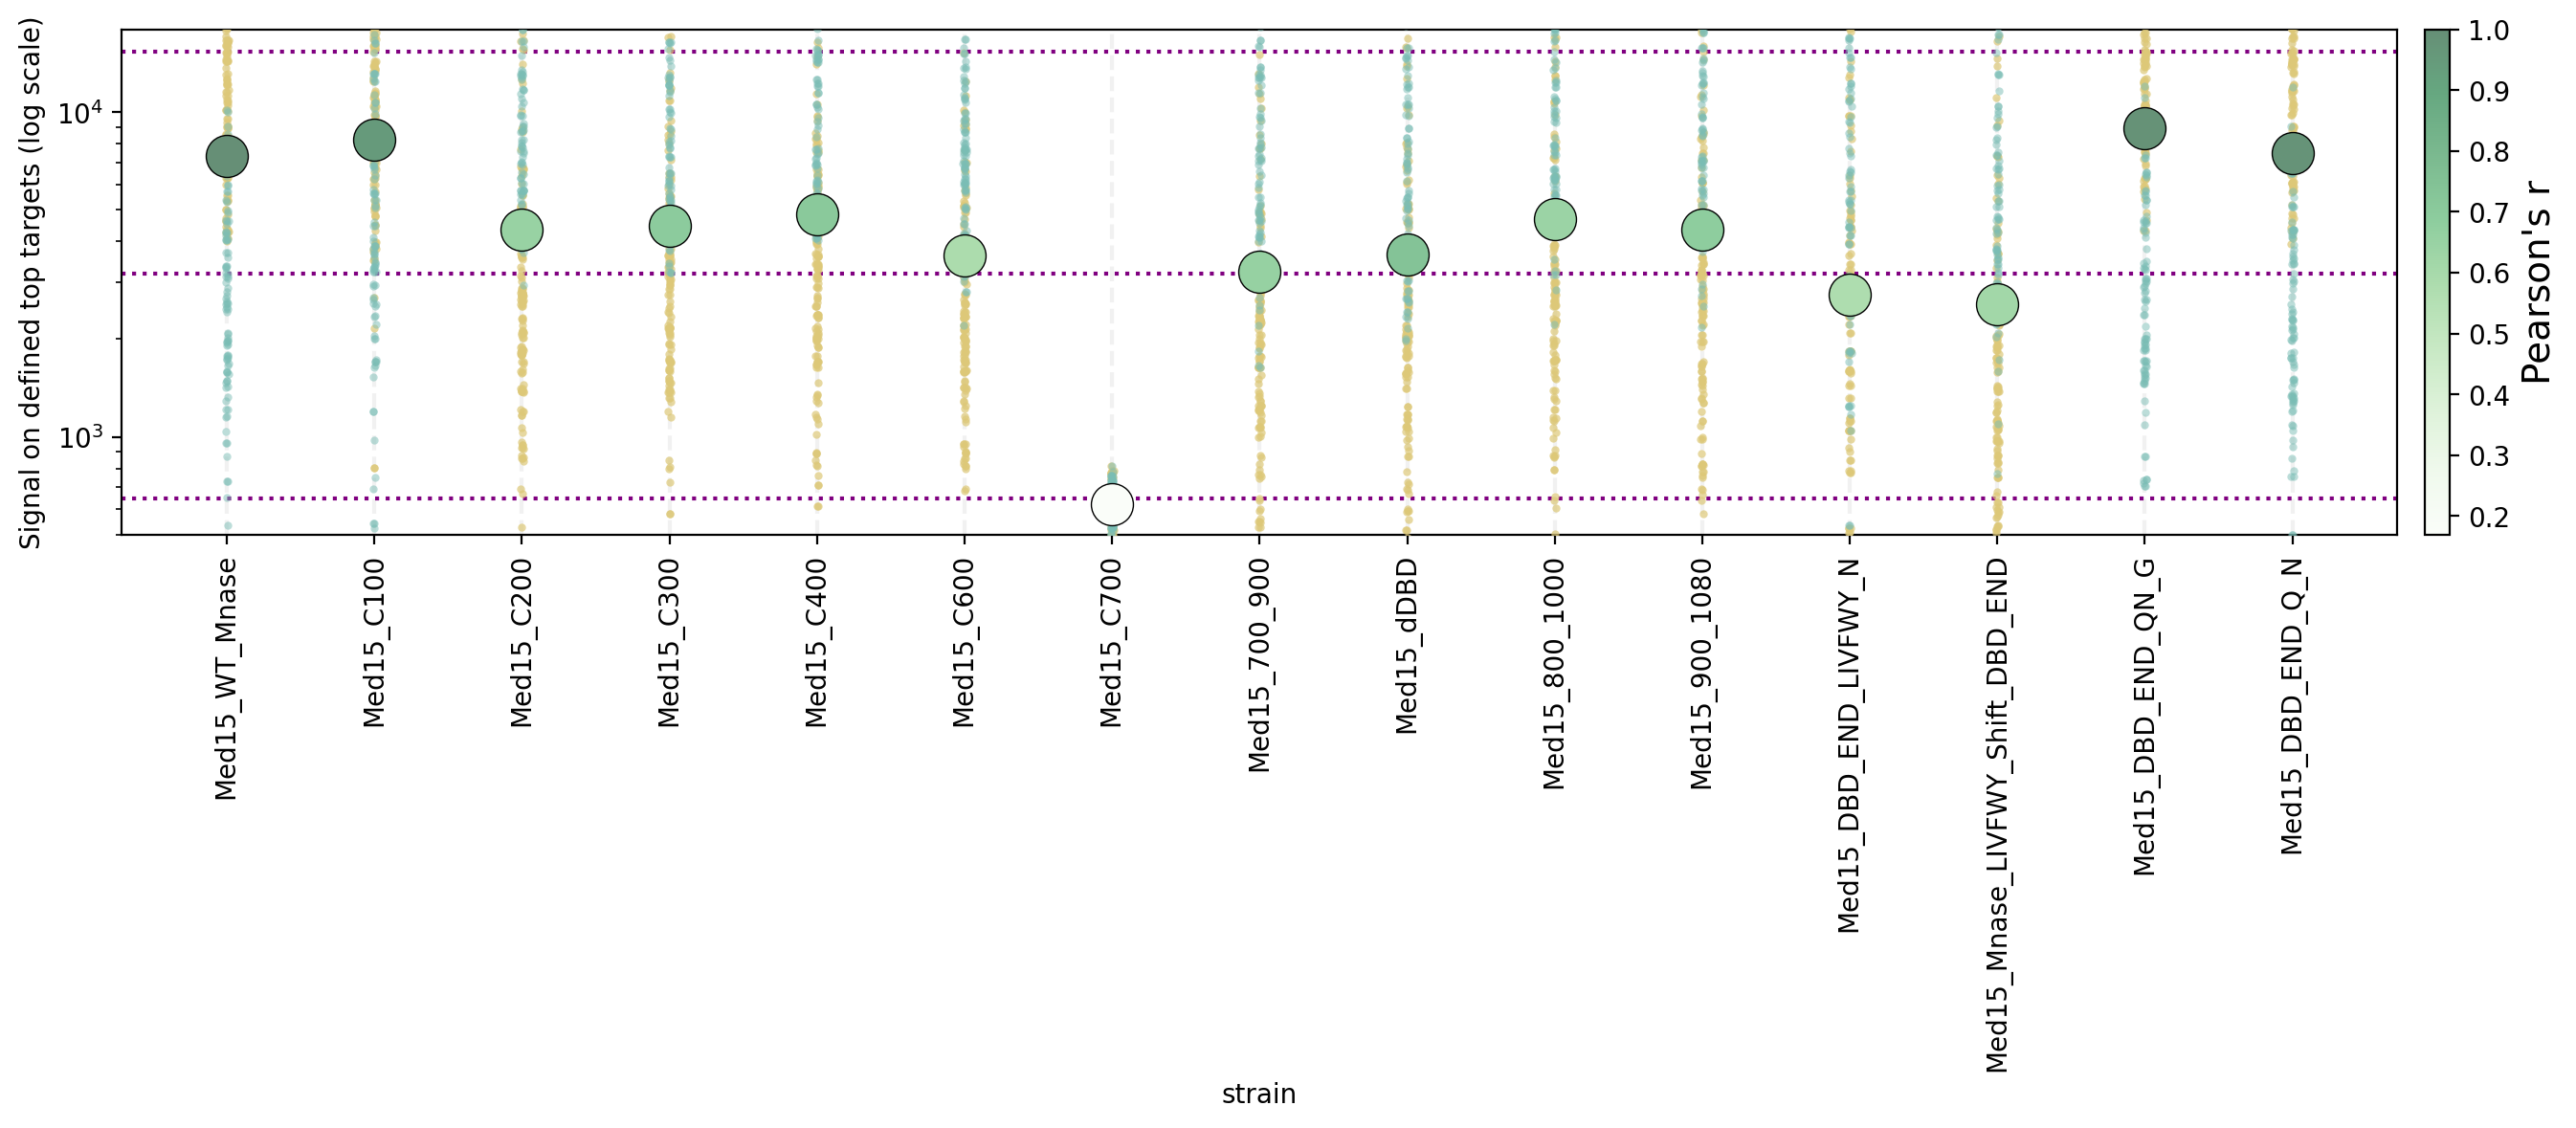

In [47]:
df_top = Figure_2C.loc[lost_in_dC + gained_in_dC].copy()
df_top['gene'] = df_top.index

df_long = df_top.melt(
    id_vars='gene',
    var_name='strain',
    value_name='signal'
).dropna()


median_df = (
    df_long
    .groupby('strain')['signal']
    .median()
    .reset_index(name='median_signal')
)


WT_col = 'Med15_WT_Mnase'
corr_with_WT = Figure_2C[Figure_2C.columns].corr()[WT_col]
corr_with_WT = corr_with_WT.reindex(Figure_2C.columns)  # ensure same order


median_df['corr_to_WT'] = median_df['strain'].map(corr_with_WT)


median_df = median_df.set_index('strain').reindex(Figure_2C.columns).reset_index()


norm = Normalize(
    vmin=median_df['corr_to_WT'].min(),
    vmax=median_df['corr_to_WT'].max()
)



plt.figure(figsize=(15, 6))


sns.stripplot(
    data=df_long[df_long['gene'].isin(lost_in_dC)],
    x='strain',
    y='signal',
    order=Figure_2C.columns,
    color='#DDC878',
    alpha=0.7,
    jitter=0.01,
    size=3
)
sns.stripplot(
    data=df_long[df_long['gene'].isin(gained_in_dC)],
    x='strain',
    y='signal',
    order=Figure_2C.columns,
    color='#7ABDB5',
    edgecolor='#7ABDB5',
    alpha=0.5,
    jitter=0.01,
    size=3
)

for _, row in median_df.iterrows():
    if pd.isna(row['median_signal']):
        continue
    plt.scatter(
        x=row['index'],
        y=row['median_signal'],
        color=pastel_cmap(norm(row['corr_to_WT'])),
        edgecolor='black',
        s=250,
        linewidth=0.5,
        zorder=10
    )


for strain in Figure_2C.columns:
    plt.axvline(x=strain, color='lightgrey', linestyle='--', alpha=0.3)


valid_targets = WT_system_data.index.intersection(med15_top_targets)


target_wt = 'Med15_WT_Mnase'
if target_wt in WT_system_data.columns:
    val_wt = WT_system_data.loc[valid_targets, target_wt].median()
    plt.axhline(val_wt, color='purple', linestyle=':', label=f'{target_wt} profile')


target_d23 = 'Med15_dABD2_dABD3'
if target_d23 in WT_system_data.columns:
    val_d23 = WT_system_data.loc[valid_targets, target_d23].median()
    plt.axhline(val_d23, color='purple', linestyle=':', label=f'{target_d23} profile')


target_d123 = 'Med15_dABD1_dABD2_dABD3_1'
if target_d123 in WT_system_data.columns:
    val_d123 = WT_system_data.loc[valid_targets, target_d123].median()
    plt.axhline(val_d123, color='purple', linestyle=':', label=f'{target_d123} profile')
    
    
sm = cm.ScalarMappable(norm=norm, cmap=pastel_cmap)
cbar = plt.colorbar(sm, ax=plt.gca(), pad=0.01)
cbar.set_label("Pearson's r", fontsize=14)


plt.xticks(rotation=90)
plt.yscale('log')
plt.ylim(500,18000)
plt.ylabel('Signal on defined top targets (log scale)')
plt.tight_layout()
plt.show()


# Figure 3

## Figure 3B

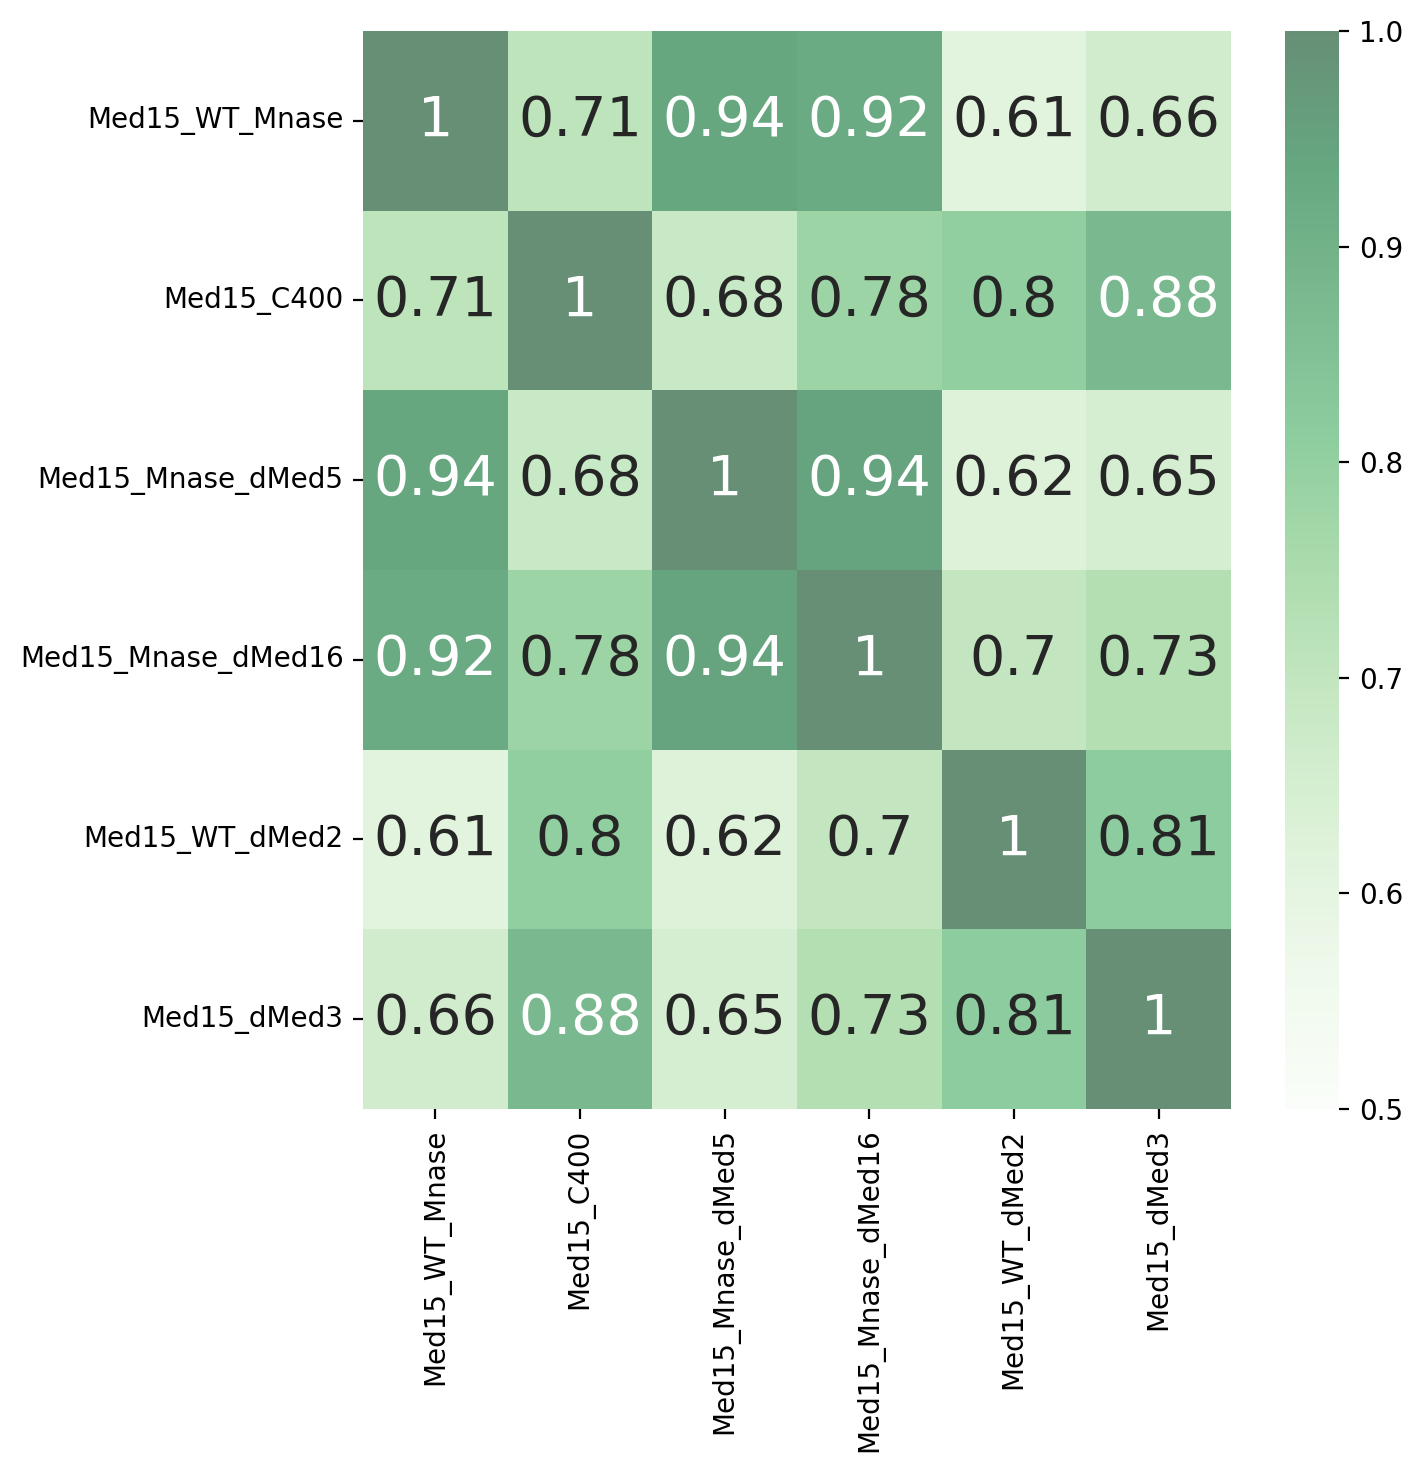

In [48]:
corr_matrix = WT_system_data[['Med15_WT_Mnase',"Med15_C400",'Med15_Mnase_dMed5','Med15_Mnase_dMed16','Med15_WT_dMed2', 'Med15_dMed3']].corr().abs()


filtered_corr_matrix = corr_matrix

plt.subplots(figsize=(7,7))
heatmap = sns.heatmap(filtered_corr_matrix, annot=True, fmt=".2g", cmap=pastel_cmap, vmax=1, vmin=0.5, annot_kws={"size": 20, 'rotation':0})

plt.show()

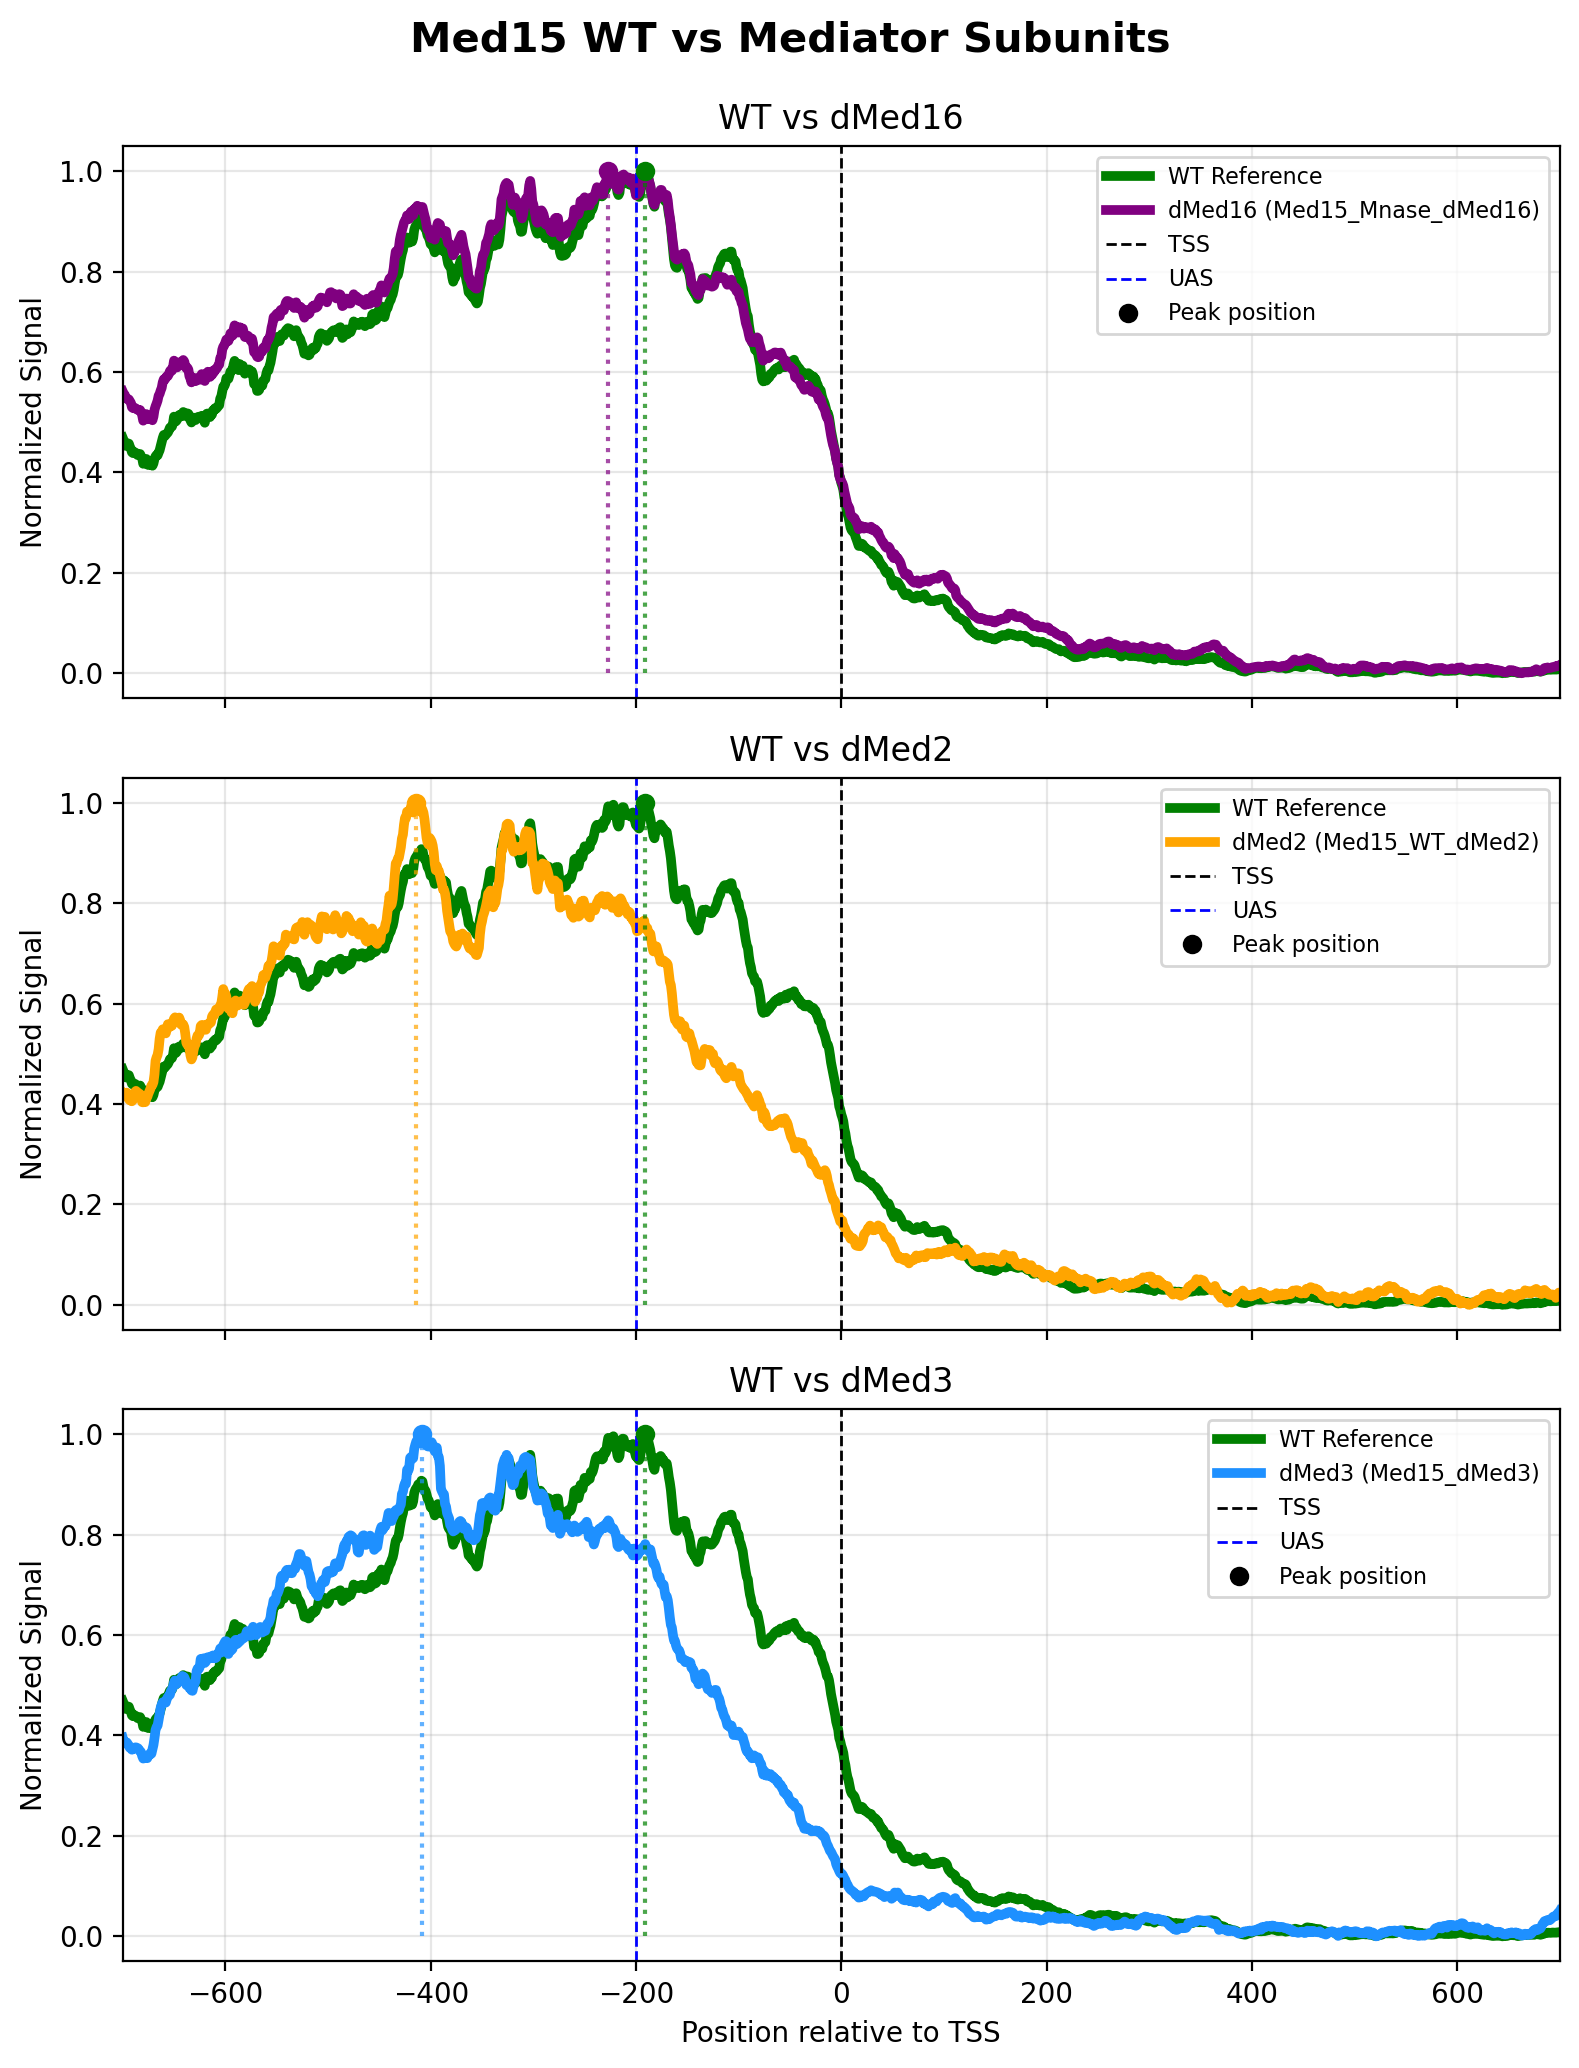

In [49]:
# 1. Define window and x-axis
window_start = -700
window_end = 700
x = np.arange(-700, 701)

# Smoothing parameter (in base pairs)
smoothing_window = 30 

# Define your reference index 
reference_index = gp.index

# ONLY plot on the Top Med15 targets
target_genes = med15_top_targets

# Clean up the strain names in the dataframe columns for cleaner plot titles
promoter_binding_signals.columns = [str(c).replace("_2000bp_signals.gz", "") for c in promoter_binding_signals.columns]

# 3. Pre-load the Wild-Type reference data ONCE for efficiency
wt_strain_name = "Med15_WT_Mnase" 
wt_path = promoter_binding_signals[wt_strain_name].loc["path"]
wt_df = pd.read_pickle(wt_path).fillna(0)

# --- FIX: Paste index and columns for WT if needed ---
if isinstance(wt_df.index, pd.RangeIndex) or wt_df.index.dtype == 'int64':
    if len(wt_df) == len(reference_index):
        wt_df.index = reference_index
    else:
        print(f"Warning: {wt_strain_name} length ({len(wt_df)}) mismatch with reference")

if wt_df.columns.min() == 0 and wt_df.columns.max() == wt_df.shape[1] - 1:
    start_col = -(wt_df.shape[1] // 2)
    wt_df.columns = range(start_col, start_col + wt_df.shape[1])

med_mutants = {
    'dMed16': find_col(['Med16']),
    'dMed2': find_col(['WT_dMed2']),
    'dMed3': find_col(['Med15_dMed3']),
}
plot_metaprofile_group("Med15 WT vs Mediator Subunits", mutants_dict=med_mutants, wt_color="green")

## Figure 3C

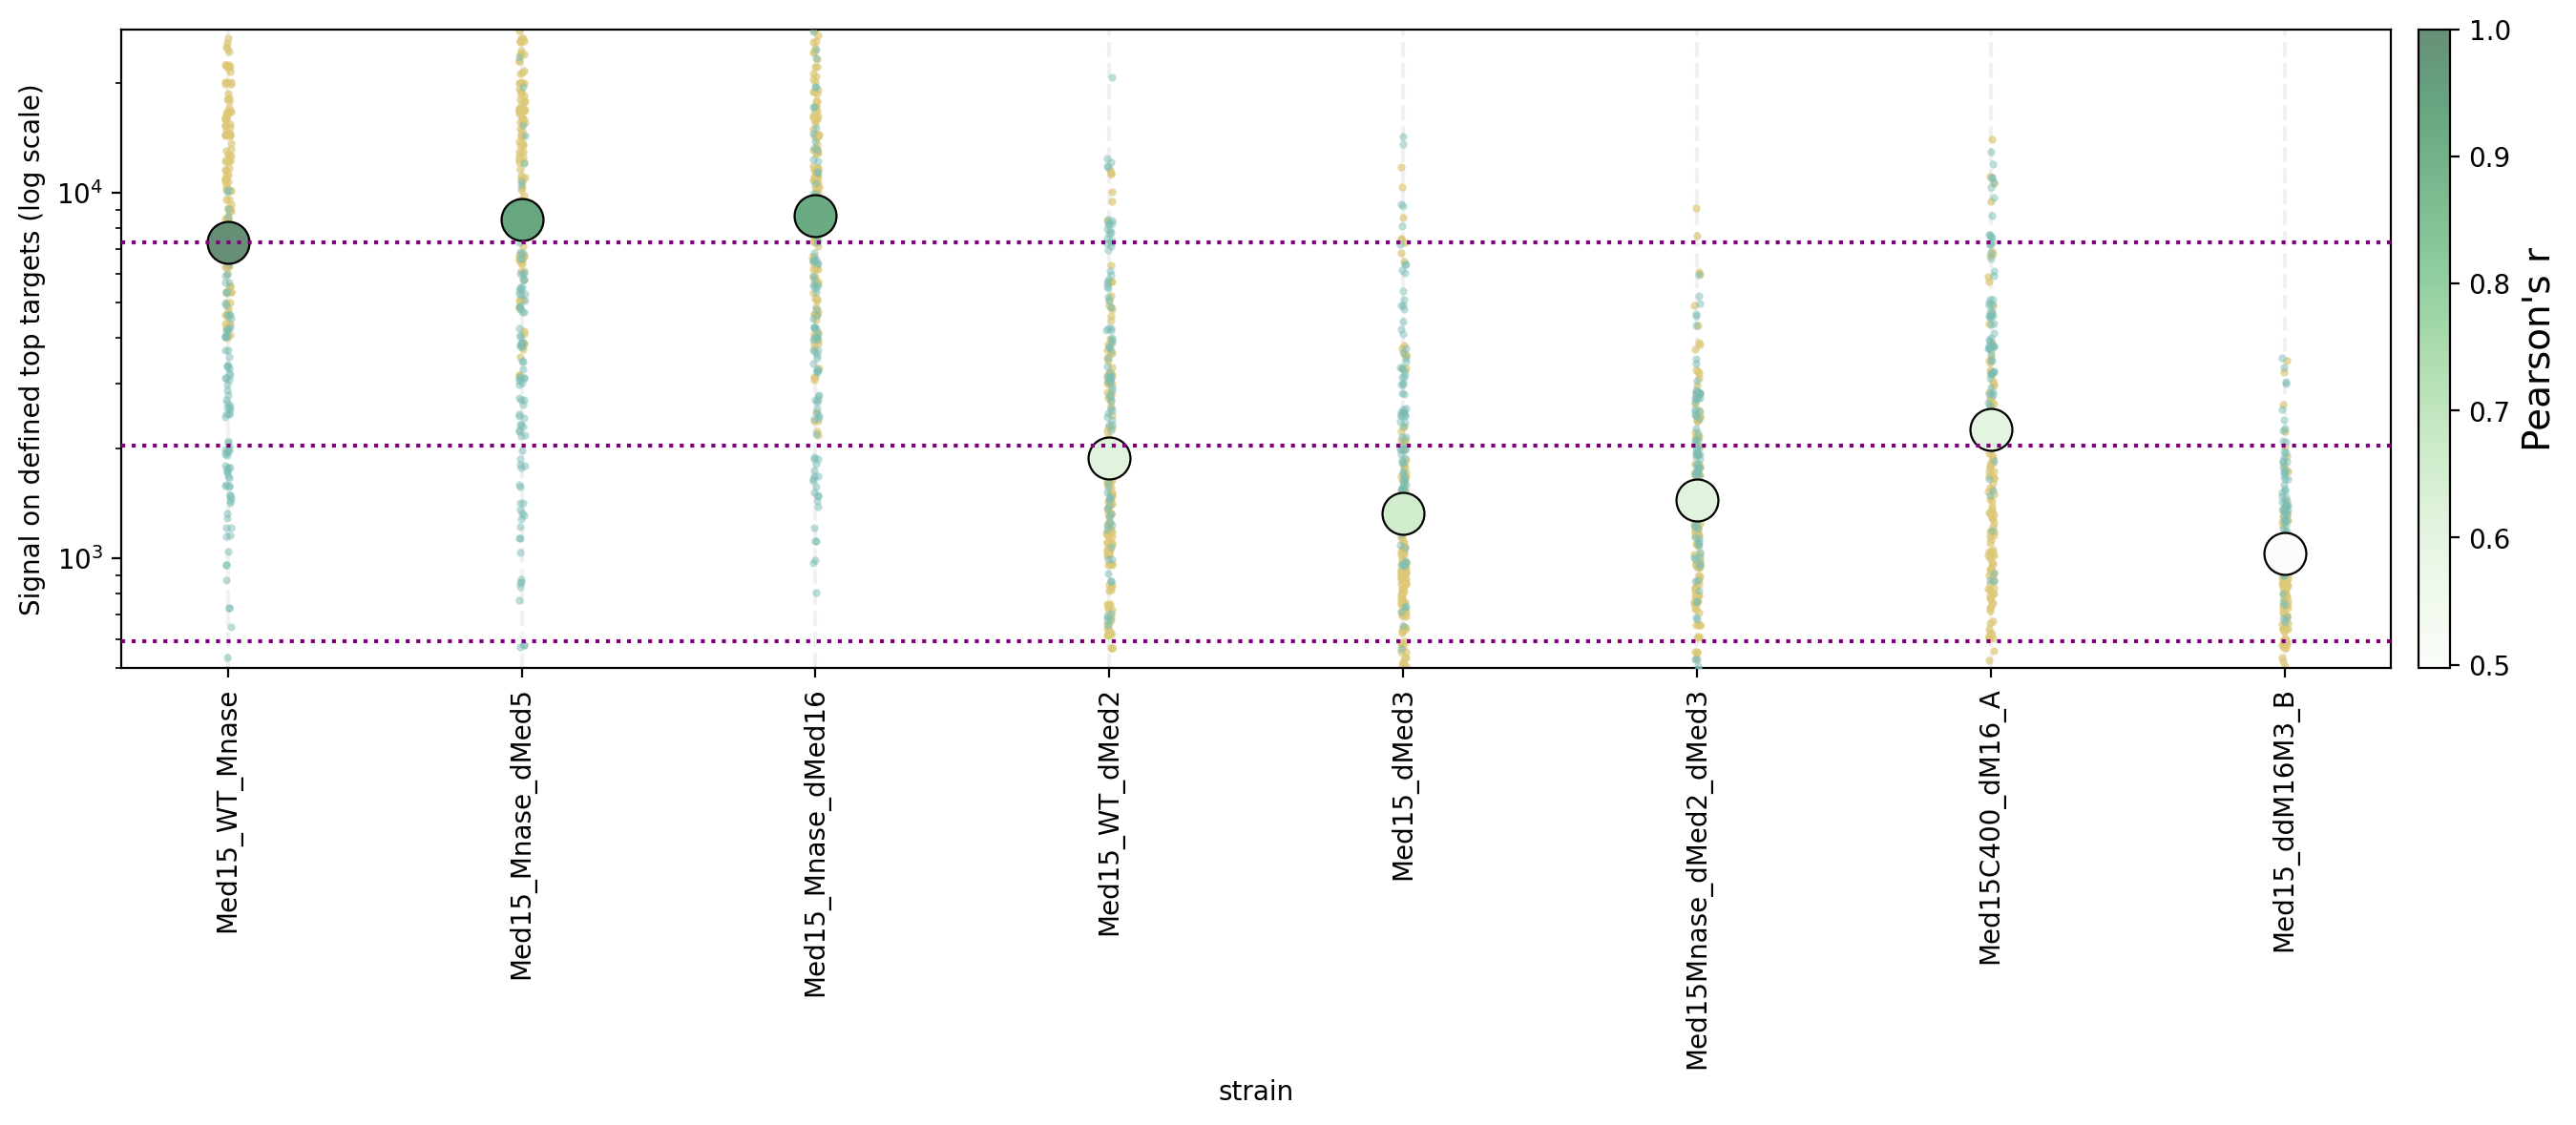

In [50]:
wt_cols = [
    'Med15_WT_Mnase', 'Med15_Mnase_dMed5', 'Med15_Mnase_dMed16',
    'Med15_WT_dMed2', 'Med15_dMed3', 'Med15Mnase_dMed2_dMed3','Med15C400_dM16_A', 'Med15_ddM16M3_B'
]

WT_part = WT_system_data.loc[~WT_system_data.index.duplicated(keep='first'), wt_cols]

Figure_3C = WT_part.loc[:, ~WT_part.columns.duplicated()]

combined_targets = list(set(lost_in_dC + gained_in_dC).intersection(Figure_3C.index))

df_top = Figure_3C.loc[combined_targets].copy()
df_top['gene'] = df_top.index

df_long = df_top.melt(
    id_vars='gene',
    var_name='strain',
    value_name='signal'
).dropna()

median_df = (
    df_long
    .groupby('strain')['signal']
    .median()
    .reset_index(name='median_signal')
)

WT_col = 'Med15_WT_Mnase'
corr_with_WT = Figure_3C.corr()[WT_col]
corr_with_WT = corr_with_WT.reindex(Figure_3C.columns)

median_df['corr_to_WT'] = median_df['strain'].map(corr_with_WT)

median_df = median_df.set_index('strain').reindex(Figure_3C.columns).reset_index()

if 'index' in median_df.columns:
    median_df = median_df.rename(columns={'index': 'strain'})

norm = Normalize(
    vmin=median_df['corr_to_WT'].min(),
    vmax=median_df['corr_to_WT'].max()
)


plt.figure(figsize=(15, 6))

# A. Background Stripplot for "Lost" targets (Gold)
sns.stripplot(
    data=df_long[df_long['gene'].isin(lost_in_dC)],
    x='strain',
    y='signal',
    order=Figure_3C.columns,
    color='#DDC878',
    alpha=0.7,
    jitter=0.01,
    size=3,
    zorder=2,
    rasterized=True
)

# B. Background Stripplot for "Gained" targets (Teal)
sns.stripplot(
    data=df_long[df_long['gene'].isin(gained_in_dC)],
    x='strain',
    y='signal',
    order=Figure_3C.columns,
    color='#7ABDB5',
    edgecolor='#7ABDB5',
    alpha=0.5,
    jitter=0.01,
    size=3,
    zorder=3,
    rasterized=True
)

# C. Vertical gridlines
for strain in Figure_3C.columns:
    plt.axvline(x=strain, color='lightgrey', linestyle='--', alpha=0.3, zorder=1)

# D. Overlay Medians
for _, row in median_df.iterrows():
    if pd.isna(row['median_signal']):
        continue
    plt.scatter(
        x=row['strain'],  
        y=row['median_signal'],
        color=pastel_cmap(norm(row['corr_to_WT'])),
        edgecolor='black',
        s=250,
        linewidth=0.8,
        zorder=10,
        rasterized=True
    )

# E. Horizontal Baseline References (Purple Lines)
baseline_strains = [
    'Med15_dABD1_dABD2_dABD3_1',
    'Med15_WT_Mnase',
    'Med15_dABD2_dABD3'
]

for target_strain in baseline_strains:
    if target_strain in median_df['strain'].values:
        subset = median_df.loc[median_df['strain'] == target_strain, 'median_signal']
        avg_signal = subset.mean() if not subset.empty else None
    elif target_strain in WT_system_data.columns:
        valid_targets = WT_system_data.index.intersection(combined_targets)
        avg_signal = WT_system_data.loc[valid_targets, target_strain].median()
    else:
        avg_signal = None

    if avg_signal is not None and not pd.isna(avg_signal):
        plt.axhline(avg_signal, color='purple', linestyle=':', label=f'{target_strain} binding profile', zorder=15)

sm = cm.ScalarMappable(norm=norm, cmap=pastel_cmap)
cbar = plt.colorbar(sm, ax=plt.gca(), pad=0.01) 
cbar.set_label("Pearson's r", fontsize=14)

plt.xticks(rotation=90)
plt.yscale('log')
plt.ylim(500, 28000)
plt.ylabel('Signal on defined top targets (log scale)')

plt.tight_layout()
plt.show()

## Figure 3D

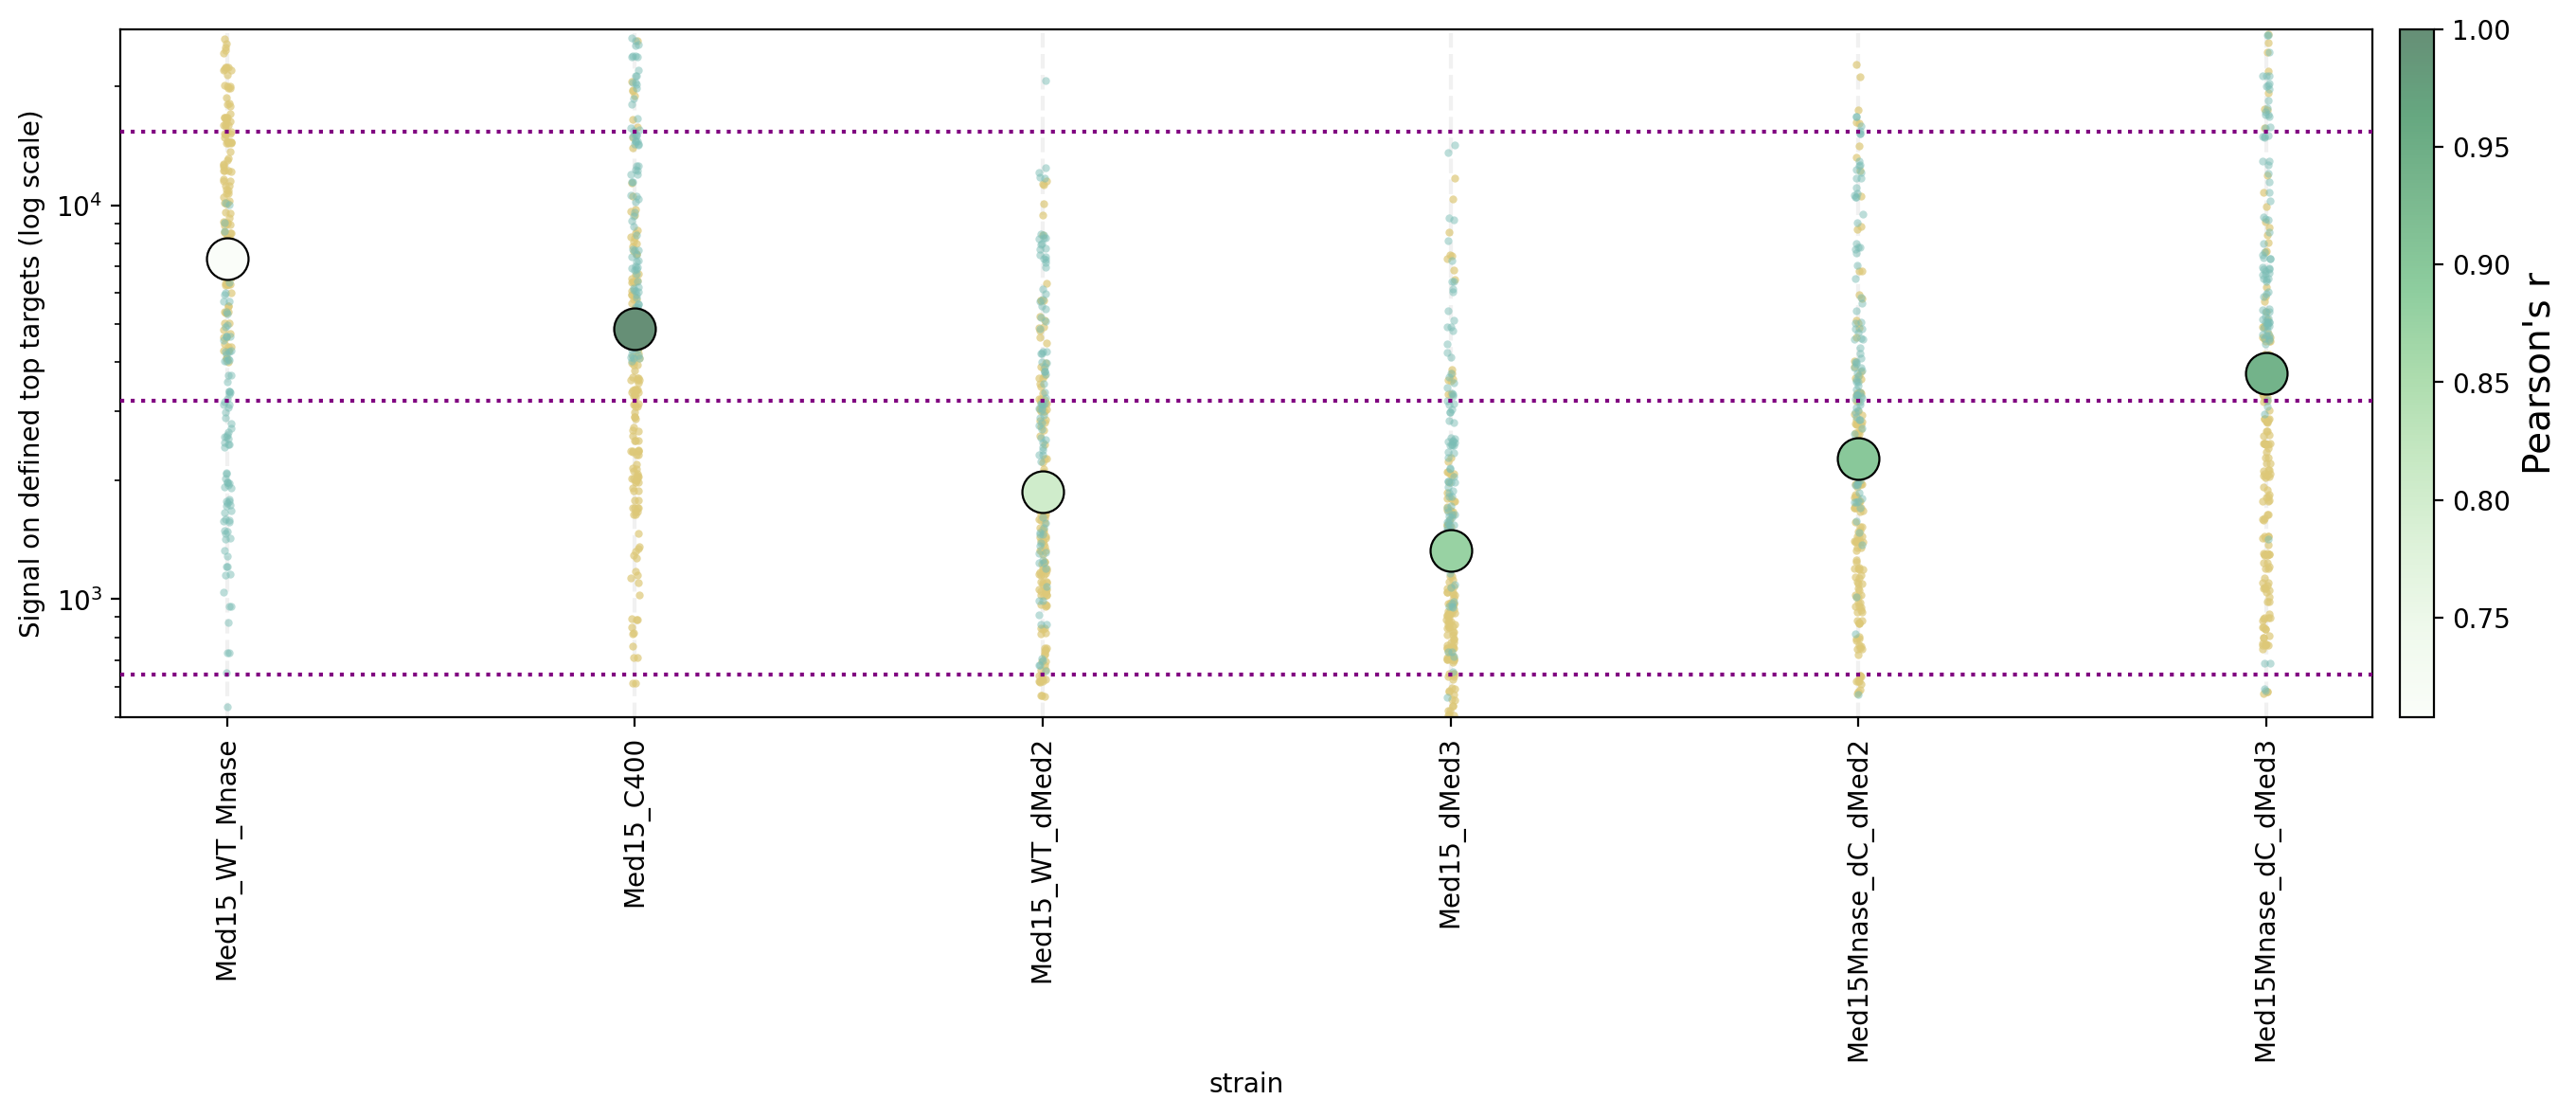

In [53]:
wt_cols = [
    'Med15_WT_Mnase', 'Med15_C400',
    'Med15_WT_dMed2', 'Med15_dMed3','Med15Mnase_dC_dMed2',
       'Med15Mnase_dC_dMed3'
]

WT_part = WT_system_data.loc[~WT_system_data.index.duplicated(keep='first'), wt_cols]

Figure_3D = WT_part.loc[:, ~WT_part.columns.duplicated()]

combined_targets = list(set(lost_in_dC + gained_in_dC).intersection(Figure_3D.index))

df_top = Figure_3D.loc[combined_targets].copy()
df_top['gene'] = df_top.index

df_long = df_top.melt(
    id_vars='gene',
    var_name='strain',
    value_name='signal'
).dropna()

median_df = (
    df_long
    .groupby('strain')['signal']
    .median()
    .reset_index(name='median_signal')
)

WT_col = 'Med15_C400'
corr_with_WT = Figure_3D.corr()[WT_col]
corr_with_WT = corr_with_WT.reindex(Figure_3D.columns)

median_df['corr_to_WT'] = median_df['strain'].map(corr_with_WT)

median_df = median_df.set_index('strain').reindex(Figure_3D.columns).reset_index()

if 'index' in median_df.columns:
    median_df = median_df.rename(columns={'index': 'strain'})

norm = Normalize(
    vmin=median_df['corr_to_WT'].min(),
    vmax=median_df['corr_to_WT'].max()
)


plt.figure(figsize=(15, 6))

# A. Background Stripplot for "Lost" targets (Gold)
sns.stripplot(
    data=df_long[df_long['gene'].isin(lost_in_dC)],
    x='strain',
    y='signal',
    order=Figure_3D.columns,
    color='#DDC878',
    alpha=0.7,
    jitter=0.01,
    size=3,
    zorder=2,
    rasterized=True
)

# B. Background Stripplot for "Gained" targets (Teal)
sns.stripplot(
    data=df_long[df_long['gene'].isin(gained_in_dC)],
    x='strain',
    y='signal',
    order=Figure_3D.columns,
    color='#7ABDB5',
    edgecolor='#7ABDB5',
    alpha=0.5,
    jitter=0.01,
    size=3,
    zorder=3,
    rasterized=True
)

# C. Vertical gridlines
for strain in Figure_3D.columns:
    plt.axvline(x=strain, color='lightgrey', linestyle='--', alpha=0.3, zorder=1)

# D. Overlay Medians
for _, row in median_df.iterrows():
    if pd.isna(row['median_signal']):
        continue
    plt.scatter(
        x=row['strain'],  
        y=row['median_signal'],
        color=pastel_cmap(norm(row['corr_to_WT'])),
        edgecolor='black',
        s=250,
        linewidth=0.8,
        zorder=10,
        rasterized=True
    )

baseline_strains = {
    'Med15_WT_Mnase': ':',      
    'Med15_dABD2_dABD3': ':' ,          
    'Med15_dABD1_dABD2_dABD3_1': ':'     
}

valid_top_targets = WT_system_data.index.intersection(med15_top_targets)

for target_strain, line_style in baseline_strains.items():
    if target_strain in WT_system_data.columns:
        avg_signal = WT_system_data.loc[valid_top_targets, target_strain].median()
        
        if pd.notna(avg_signal):
            plt.axhline(
                avg_signal, 
                color='purple', 
                linestyle=line_style, 
                label=f'{target_strain} baseline', 
                zorder=15
            )

sm = cm.ScalarMappable(norm=norm, cmap=pastel_cmap)
cbar = plt.colorbar(sm, ax=plt.gca(), pad=0.01) 
cbar.set_label("Pearson's r", fontsize=14)

plt.xticks(rotation=90)
plt.yscale('log')
plt.ylim(500, 28000)
plt.ylabel('Signal on defined top targets (log scale)')

plt.tight_layout()
plt.show()

## Figure 3E

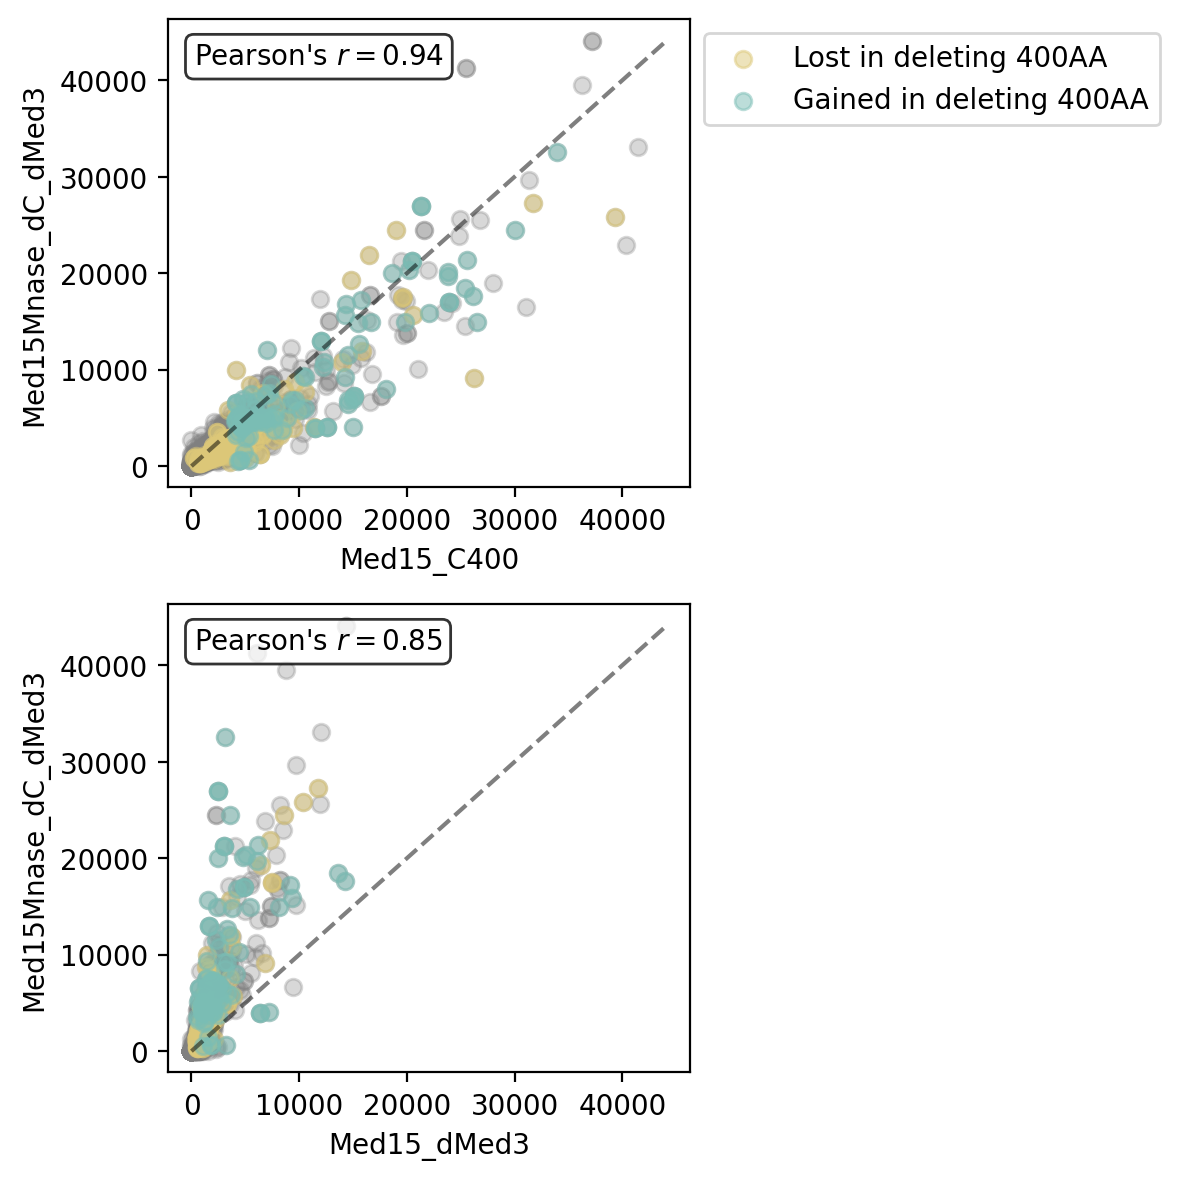

In [54]:
def plot_med_comparison(ax, df, x_col, y_col, lost_idx, gained_idx):
    # Drop NaNs to calculate correlation correctly
    valid_data = df[[x_col, y_col]].dropna()
    corr, _ = pearsonr(valid_data[x_col], valid_data[y_col])
    
    # Base scatter (all points)
    ax.scatter(df[x_col], df[y_col], alpha=0.3, color='grey')
    
    # Highlighted groups
    ax.scatter(df[x_col].loc[lost_idx], df[y_col].loc[lost_idx],
               alpha=0.5, color='#DDC878', edgecolor='#DDC878',
               label='Lost in deleting 400AA')
    ax.scatter(df[x_col].loc[gained_idx], df[y_col].loc[gained_idx],
               alpha=0.5, color='#7ABDB5', edgecolor='#7ABDB5',
               label='Gained in deleting 400AA')
    
    # Unity line (y=x)
    max_val = max(df[x_col].max(), df[y_col].max())
    ax.plot([0, max_val], [0, max_val], '--', color='black', alpha=0.5)
    
    # Add Pearson R text to the plot
    ax.text(0.05, 0.95, f"Pearson's $r = {corr:.2f}$", 
            transform=ax.transAxes, verticalalignment='top',
            bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
    
    ax.set_xlabel(x_col)
    ax.set_ylabel(y_col)
    
fig1, axes1 = plt.subplots(2, 1, figsize=(6, 6))
plot_med_comparison(axes1[0], Figure_3D, 'Med15_C400', 'Med15Mnase_dC_dMed3', lost_in_dC, gained_in_dC)
plot_med_comparison(axes1[1], Figure_3D, 'Med15_dMed3', 'Med15Mnase_dC_dMed3', lost_in_dC, gained_in_dC)
axes1[0].legend(loc='upper left', bbox_to_anchor=(1, 1))
fig1.tight_layout()
plt.show()

# Figure 4

## Figure 4B

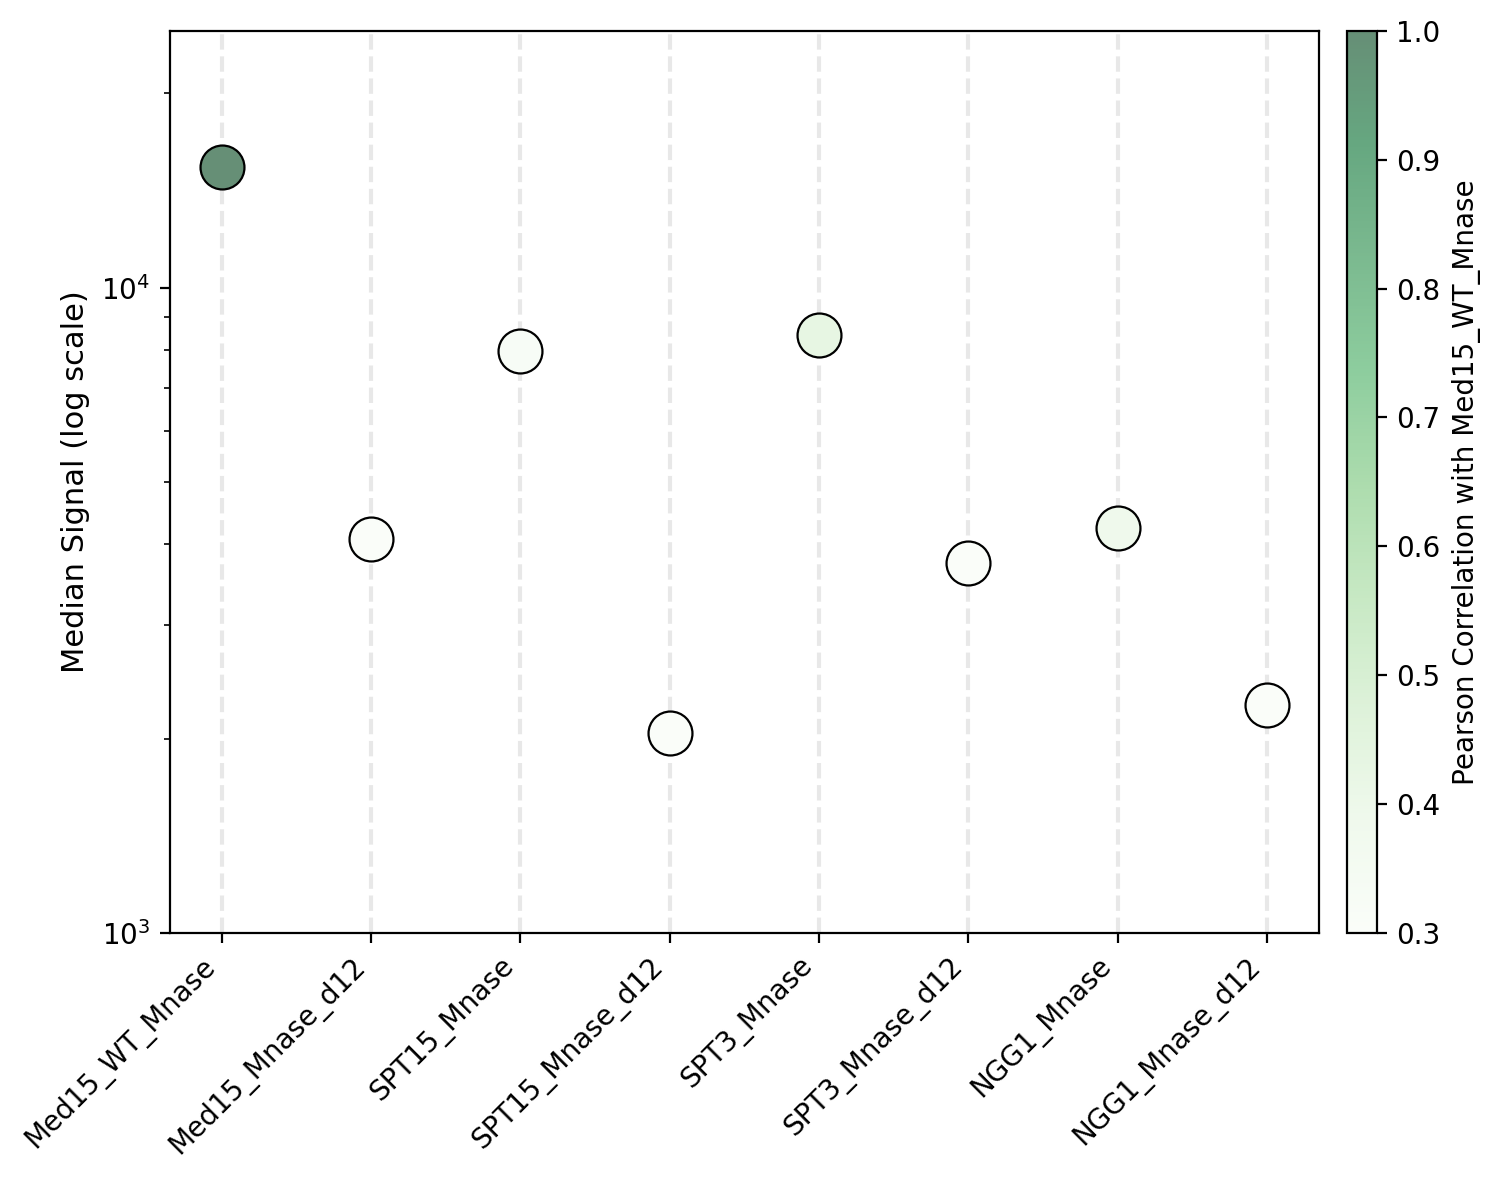

In [56]:
paired_order = [
    'Med15_WT_Mnase', 'Med15_Mnase_d12',
    'SPT15_Mnase', 'SPT15_Mnase_d12',
    'SPT3_Mnase', 'SPT3_Mnase_d12',
    'NGG1_Mnase', 'NGG1_Mnase_d12'
]


valid_cols = [c for c in paired_order if c in WT_d12.columns]

target_genes = med15_top_targets
df_sub = WT_d12[valid_cols].loc[WT_d12.index.intersection(target_genes)].dropna()

median_series = df_sub.median()

WT_ref_col = 'Med15_WT_Mnase'
corr_series = df_sub.corr()[WT_ref_col]

# Build a plotting dataframe
plot_df = pd.DataFrame({
    'strain': valid_cols,
    'median_signal': [median_series[c] for c in valid_cols],
    'corr_to_WT': [corr_series[c] for c in valid_cols]
})


norm = Normalize(vmin=0.3, vmax=1.0) 

fig, ax = plt.subplots(figsize=(8, 6))

for i, strain in enumerate(valid_cols):
    ax.axvline(x=i, color='lightgrey', linestyle='--', alpha=0.5, zorder=1)

for i, row in plot_df.iterrows():
    if pd.isna(row['median_signal']):
        continue
        
    ax.scatter(
        x=i, 
        y=row['median_signal'],
        color=pastel_cmap(norm(row['corr_to_WT'])),
        edgecolor='black',
        s=250,
        linewidth=0.8,
        zorder=10,
        rasterized=True
    )

ax.set_yscale('log')
ax.set_ylim(1000, 25000) 

ax.set_xticks(range(len(valid_cols)))
ax.set_xticklabels(valid_cols, rotation=45, ha='right', fontsize=10)
ax.set_ylabel('Median Signal (log scale)', fontsize=11)

sm = cm.ScalarMappable(norm=norm, cmap=pastel_cmap)
cbar = fig.colorbar(sm, ax=ax, pad=0.02, aspect=30)
cbar.set_label(f'Pearson Correlation with {WT_ref_col}', fontsize=10)


plt.tight_layout()
plt.show()

## Figures 4C+D

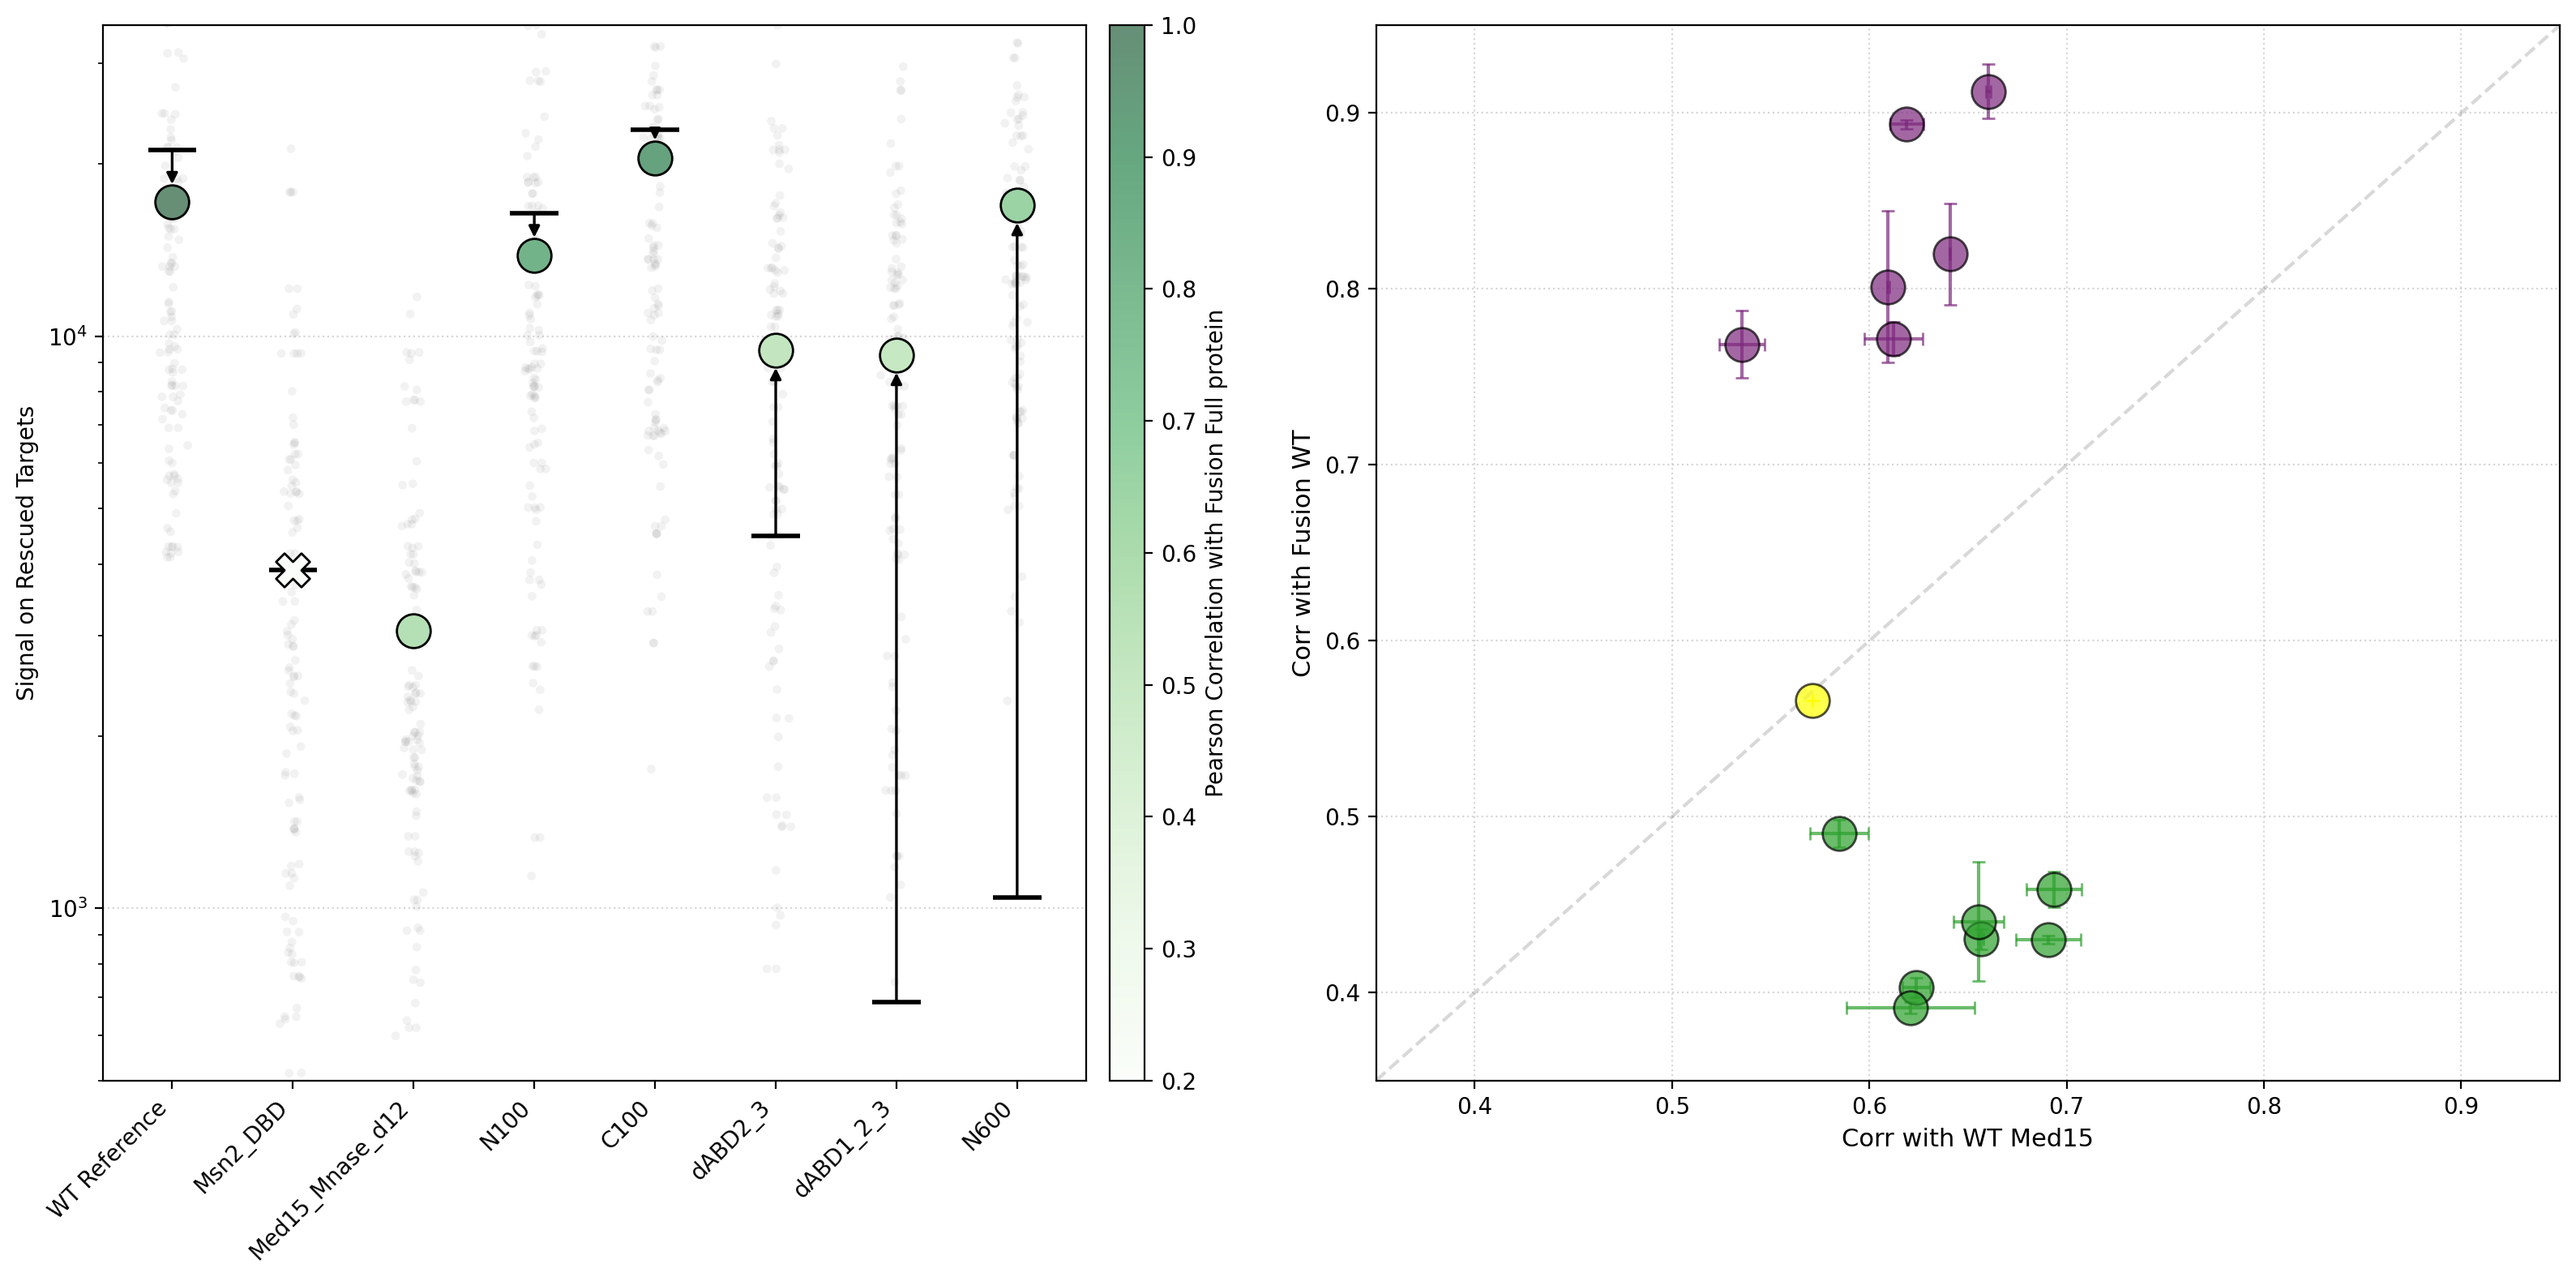

In [57]:
panel_1_map = [
    ('WT Reference', 'med15_msn2dbd_mnase', 'Med15_WT_Mnase'),
    ('Msn2_DBD', None, 'Msn2_DBD'),
    ('Med15_Mnase_d12', 'Med15_Mnase_d12', None),
    ('N100', 'N100', 'Med15_N100'),
    ('C100', 'Med15_Msn2_DBD_C100', 'Med15_C100'),
    ('dABD2_3', 'Fusion_dABD2_dABD3', 'Med15_dABD2_dABD3'),
    ('dABD1_2_3', 'Fusion_dABD1_dABD2_dABD3', 'Med15_dABD1_dABD2_dABD3_1'),
    ('N600', 'N600', 'Med15_N600')
]

# Mutation groups for the integrated scatter panel
n_term_abd_map = [
    ('dABD2', 'dABD2', 'Med15_dABD2'),
    ('dABD1', 'dABD1', 'Med15_dABD1'),
    ('d200_400', 'd200_400', 'Med15_200_400'),
    ('dABD3', 'dABD3', 'Med15_dABD3'),
    ('N300', 'N300', 'Med15_N300'),
    ('N400', 'N400', 'Med15_N400')
]

c_term_map = [
    ('C200', 'Med15_Msn2_DBD_C200', 'Med15_C200'),
    ('C300', 'Med15_Msn2_DBD_C300', 'Med15_C300'),
    ('C400', 'Med15_Msn2_DBD_C400', 'Med15_C400'),
    ('C600', 'Med15_Msn2_DBD_C600', 'Med15_C600'),
    ('dDBD', 'dDBD', 'Med15_dDBD'),
    ('d700_900', 'd700_900', 'Med15_700_900'),
    ('d800_1000', 'd800_1000', 'Med15_800_1000'),
    ('dMed2', 'Med15_Fusion_dMed2', 'Med15_WT_dMed2')
]
norm_corr = Normalize(vmin=0.2, vmax=1.0)
DOT_DIAMETER = 15
DOT_AREA = DOT_DIAMETER**2 

WT_sys = WT_system_data[~WT_system_data.index.duplicated(keep='first')]
d12_sys = d12_system_data[~d12_system_data.index.duplicated(keep='first')]
common_idx = WT_sys.index.intersection(d12_sys.index)

fold_change_threshold = 2
signal_threshold = 4000
targets_lost_rescued = list(common_idx[
    (WT_sys.loc[common_idx, 'Med15_WT_Mnase'] > signal_threshold) &
    (WT_sys.loc[common_idx, 'Med15_WT_Mnase'] > fold_change_threshold * d12_sys.loc[common_idx, 'Med15_Mnase_d12']) &
    (d12_sys.loc[common_idx, 'med15_msn2dbd_mnase'] > signal_threshold) &
    (d12_sys.loc[common_idx, 'med15_msn2dbd_mnase'] > fold_change_threshold * d12_sys.loc[common_idx, 'Med15_Mnase_d12'])
])
valid_targs = d12_sys.index.intersection(targets_lost_rescued)

def get_mutation_tag(col_name):
    if not col_name: return [""]
    clean = col_name.replace('Med15_Mnase_', '').replace('med15_msn2dbd_mnase_', '')
    clean = clean.replace('Med15_Msn2_DBD_', '').replace('Med15_Msn2DBD_', '').replace('Med15_', '')
    if re.match(r'^d\d+_\d+', clean): return [clean, clean[1:]]
    return [clean]

def find_replicates(col_name, repeat_df_cols, is_msn2=False):
    if not col_name: return []
    tags = get_mutation_tag(col_name)
    matches = []
    for rep in repeat_df_cols:
        base_rep = re.sub(r'_\d+$', '', rep)
        for tag in tags:
            valid_bases = [tag, f"Med15_{tag}", f"Med15_Mnase_{tag}"]
            if is_msn2: valid_bases += [f"med15_msn2dbd_mnase_{tag}", f"Med15_Msn2_DBD_{tag}", f"d{tag}"]
            if base_rep in valid_bases:
                if rep not in matches: matches.append(rep)
    return matches

def get_stats(label, d12_col, wt_col):
    col_to_check = d12_col if (d12_col and d12_col in d12_sys.columns) else wt_col
    sys_df = d12_sys if (d12_col and d12_col in d12_sys.columns) else WT_sys
    if not col_to_check or col_to_check not in sys_df.columns: return None
    s_mut = sys_df.loc[valid_targs, col_to_check]
    s_fusion_ref = d12_sys.loc[valid_targs, 'med15_msn2dbd_mnase']
    s_wt_ref = WT_sys.loc[valid_targs, 'Med15_WT_Mnase']
    return s_mut.corr(s_fusion_ref), s_mut.corr(s_wt_ref), s_mut.mean()

fig, (ax0, ax1) = plt.subplots(1, 2, figsize=(16, 8))


for i, (label, d12_col, wt_col) in enumerate(panel_1_map):
    stats = get_stats(label, d12_col, wt_col)
    wt_val = WT_sys.loc[valid_targs, wt_col].mean() if wt_col and wt_col in WT_sys.columns else np.nan
    if not pd.isna(wt_val):
        ax0.hlines(wt_val, i-0.2, i+0.2, color='black', lw=2, zorder=5)

    target_vals = d12_sys.loc[valid_targs, d12_col].dropna() if d12_col else WT_sys.loc[valid_targs, wt_col].dropna()
    jitter = np.random.normal(0, 0.04, size=len(target_vals))
    ax0.scatter(i + jitter, target_vals, color='gray', alpha=0.1, s=15, edgecolor='none', zorder=2, rasterized=True)

    if stats:
        node_color = pastel_cmap(norm_corr(stats[0]))
        d12_val = d12_sys.loc[valid_targs, d12_col].mean() if d12_col and d12_col in d12_sys.columns else np.nan
        m_val = d12_val if not pd.isna(d12_val) else wt_val
        marker = 'o' if not pd.isna(d12_val) else 'X'
        ax0.scatter(i, m_val, color=node_color, edgecolor='black', s=DOT_AREA, marker=marker, zorder=6, rasterized=True)

    if not pd.isna(wt_val) and not pd.isna(d12_val):
        ax0.annotate('', xy=(i, d12_val), xytext=(i, wt_val),
                    arrowprops=dict(arrowstyle='-|>', color='black', lw=1.2, shrinkA=0, shrinkB=8), zorder=4)

ax0.set_yscale('log')
ax0.set_ylim(500, 35000)
ax0.set_xticks(range(len(panel_1_map)))
ax0.set_xticklabels([m[0] for m in panel_1_map], rotation=45, ha='right')
ax0.set_ylabel("Signal on Rescued Targets")
ax0.grid(axis='y', linestyle=':', alpha=0.5)


 
sm = cm.ScalarMappable(norm=norm_corr, cmap=pastel_cmap)
cbar = fig.colorbar(sm, ax=ax0, pad=0.02, aspect=30)
cbar.set_label('Pearson Correlation with Fusion Full protein', fontsize=10)


for mapping, color, group_label in [(n_term_abd_map, '#7d287d', 'N-Term/ABD'), (c_term_map, '#2ca02c', 'C-Terminal')]:
    for label, d12_col, wt_col in mapping:
        stats = get_stats(label, d12_col, wt_col)
        if stats:
            wt_reps = find_replicates(wt_col, wt_system_repeats.columns)
            x_err = np.std([wt_system_repeats.loc[valid_targs, r].corr(WT_sys.loc[valid_targs, 'Med15_WT_Mnase']) for r in wt_reps]) if len(wt_reps) > 1 else 0

            is_c = label.startswith('C') or 'C' in label
            target_df = msn2_dbd_c_repeats if is_c else msn2_dbd_repeats
            msn2_reps = find_replicates(d12_col, target_df.columns, is_msn2=True)
            y_err = np.std([target_df.loc[valid_targs, r].corr(d12_sys.loc[valid_targs, 'med15_msn2dbd_mnase']) for r in msn2_reps]) if len(msn2_reps) > 1 else 0

            marker_color = 'yellow' if label == 'dMed2' else color

            ax1.errorbar(stats[1], stats[0], xerr=x_err, yerr=y_err, fmt='o', color=marker_color,
                         markersize=DOT_DIAMETER, markeredgecolor='black', alpha=0.7, capsize=3, zorder=5)

ax1.set_xlim(0.35, 0.95)
ax1.set_ylim(0.35, 0.95)
ax1.plot([0.35, 0.95], [0.35, 0.95], '--', color='gray', alpha=0.3)
ax1.set_xlabel("Corr with WT Med15", fontsize=11)
ax1.set_ylabel("Corr with Fusion WT", fontsize=11)
ax1.grid(True, linestyle=':', alpha=0.5)

plt.tight_layout()

plt.show()

## Figure 4E

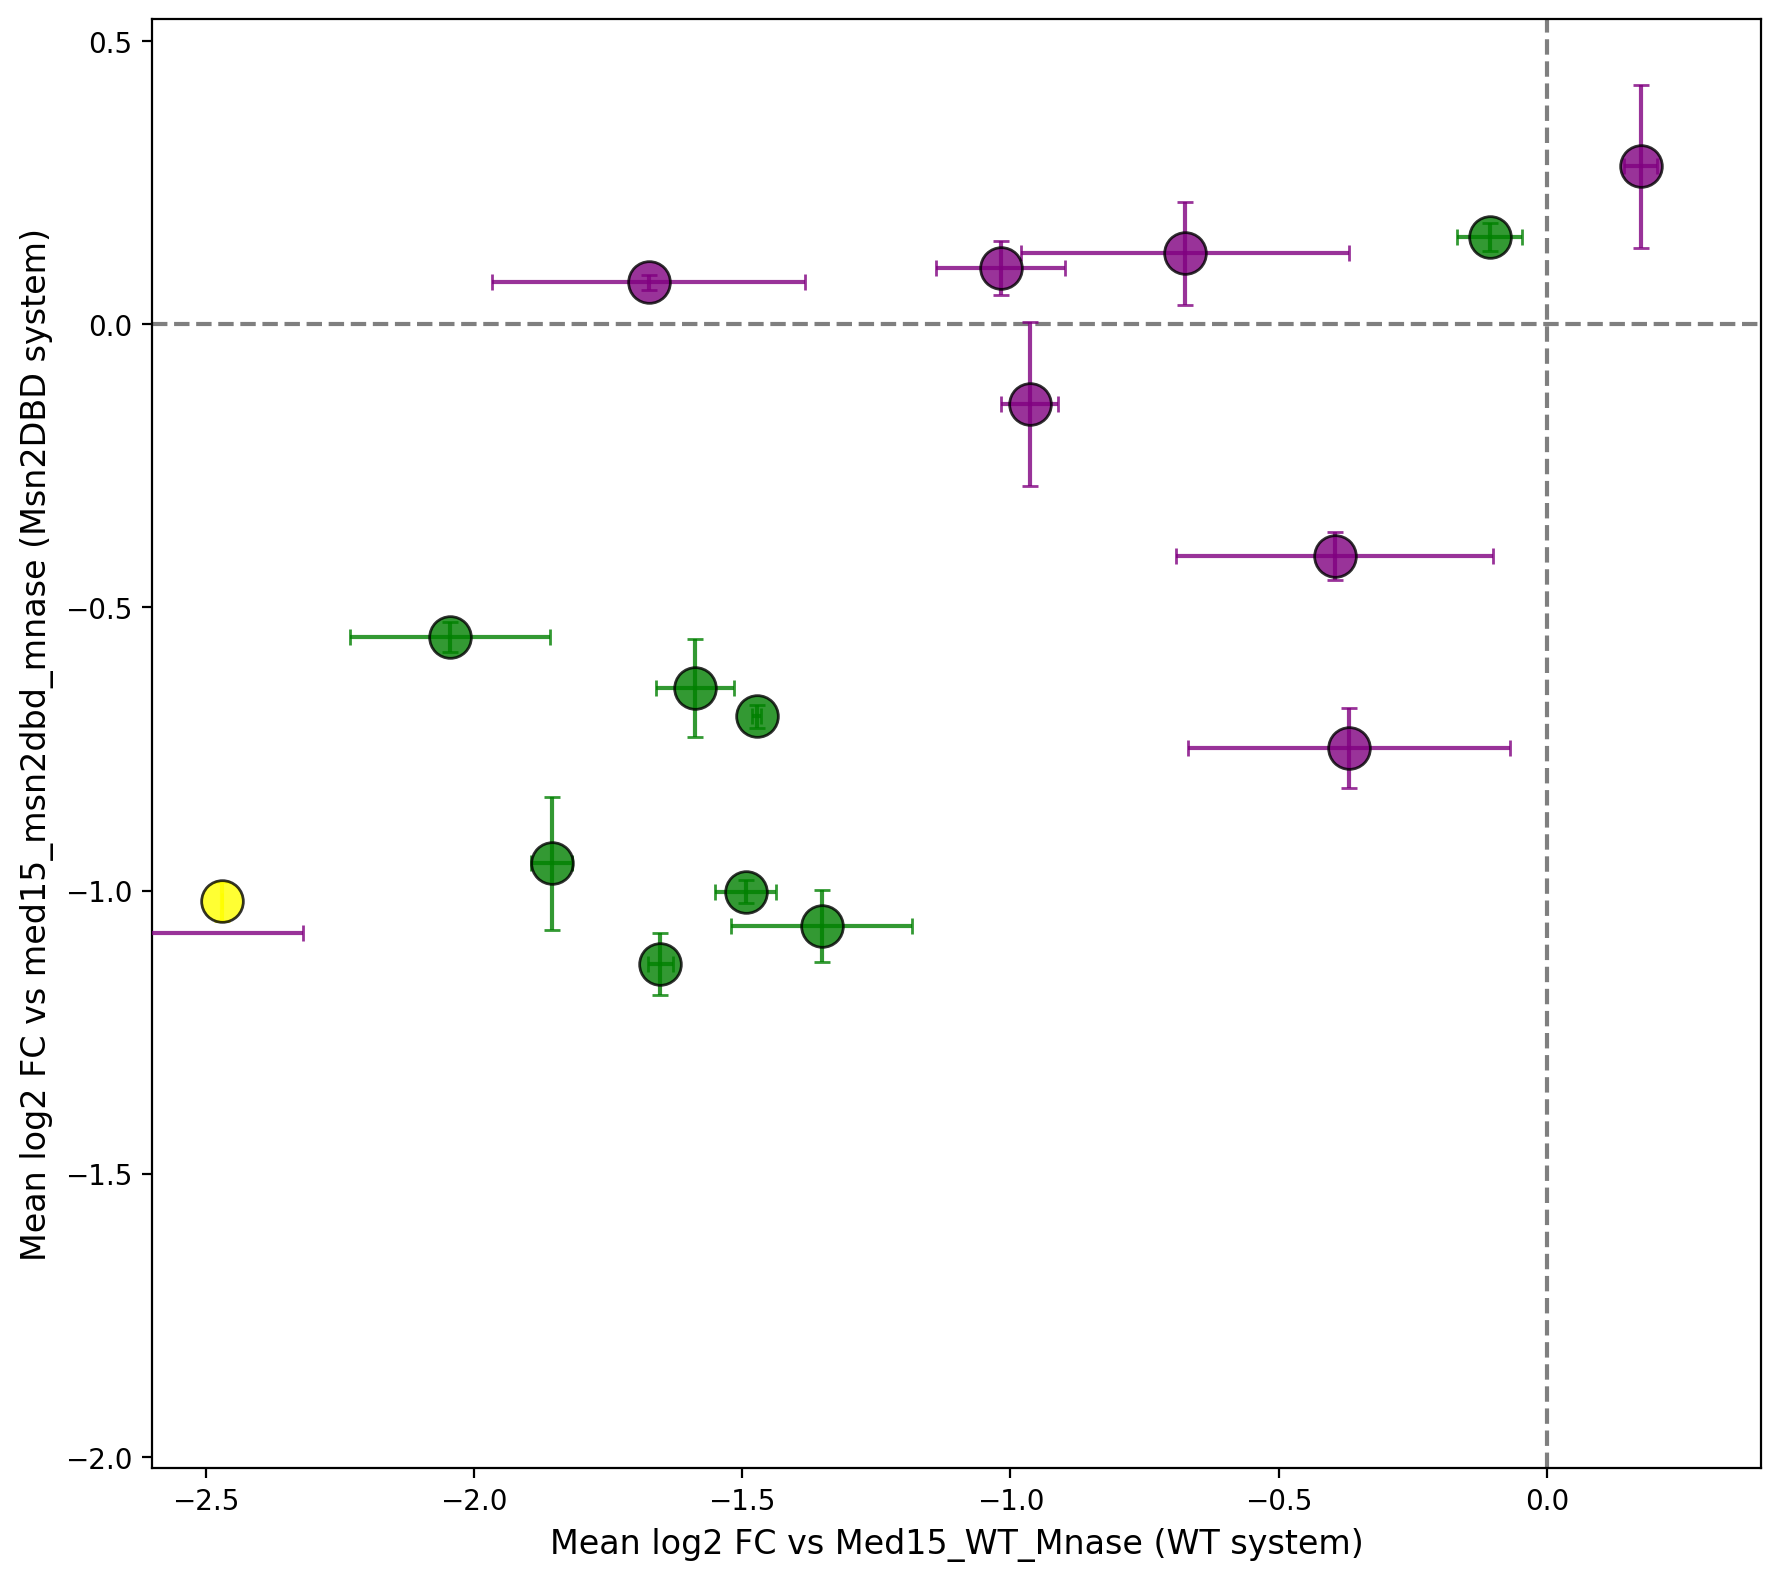

In [58]:
column_mapping = {
    'Med15_200_400': 'd200_400',
    'Med15_700_900': 'd700_900',
    'Med15_800_1000': 'd800_1000',
    'Med15_N100': 'N100',
    'Med15_N200': 'N200',
    'Med15_N300': 'N300',
    'Med15_N400': 'N400',
    'Med15_N600': 'N600',
    'Med15_N800': 'N800',
    'Med15_C100': 'Med15_Msn2_DBD_C100',
    'Med15_C200': 'Med15_Msn2_DBD_C200',
    'Med15_C300': 'Med15_Msn2_DBD_C300',
    'Med15_C400': 'Med15_Msn2_DBD_C400',
    'Med15_C600': 'Med15_Msn2_DBD_C600',
    'Med15_C700': 'Med15_Msn2_DBD_C700',
    'Med15_C800': 'Med15_Msn2_DBD_C800',  
    'Med15_dABD1': 'dABD1',
    'Med15_dABD2': 'dABD2',
    'Med15_dABD3': 'dABD3',
    'Med15_dDBD': 'dDBD',
    'Med15_WT_dMed2': 'Med15_Fusion_dMed2'
}

WT_columns = ['Med15_WT_Mnase'] + list(column_mapping.keys())
msn2_columns = ['med15_msn2dbd_mnase'] + list(column_mapping.values())


WT_filtered = WT_system_data[WT_columns].rename(columns=column_mapping)


msn2_filtered = d12_system_data[msn2_columns]

color_rules = [
    (r'd200|N100|N200|N300|N400|N600|N800|dABD1|dABD2|dABD3', 'purple'),
    (r'd700_900|d800_1000|dDBD|Med15_Msn2_DBD_C|dMed2', 'green'),
]

WT_sub = WT_filtered.loc[WT_filtered.index.intersection(lost_in_d12_gained_in_fusion)]
msn2_sub = msn2_filtered.loc[msn2_filtered.index.intersection(lost_in_d12_gained_in_fusion)]

mutant_columns_WT = [col for col in WT_filtered.columns if col != 'Med15_WT_Mnase']
mutant_columns_msn2 = [col for col in msn2_filtered.columns if col != 'med15_msn2dbd_mnase']

mutant_columns_WT.sort()
mutant_columns_msn2.sort()

def get_mutation_tag(col_name):
    """Extracts the core mutation string (e.g. N100, dABD1) ignoring system prefixes."""
    clean = col_name.replace('Med15_Mnase_', '').replace('med15_msn2dbd_mnase_', '')
    clean = clean.replace('Med15_Msn2_DBD_', '').replace('Med15_Msn2DBD_', '').replace('Med15_', '')
    
    if re.match(r'^d\d+_\d+', clean):
        return [clean, clean[1:]] 
    return [clean]

def find_wt_replicates(wt_col, wt_repeat_cols):
    tags = get_mutation_tag(wt_col)
    matches = []
    for rep in wt_repeat_cols:
        base_rep = re.sub(r'_\d+$', '', rep) # Remove replicate numbers like _1
        for tag in tags:
            if base_rep in [f"Med15_{tag}", f"Med15_Mnase_{tag}", tag]:
                if rep not in matches: matches.append(rep)
    return matches

def find_msn2_replicates(msn2_col, msn2_repeat_cols):
    tags = get_mutation_tag(msn2_col)
    matches = []
    for rep in msn2_repeat_cols:
        base_rep = re.sub(r'_\d+$', '', rep)
        for tag in tags:

            if base_rep in [tag, f"d{tag}", f"med15_msn2dbd_mnase_{tag}", f"Med15_{tag}", f"Med15_Msn2_DBD_{tag}"]:
                if rep not in matches: matches.append(rep)
    return matches

wt_ref_cols = ['Med15_Mnase_WT_1', 'Med15_Mnase_WT_2']

msn2_ref_cols = [c for c in msn2_dbd_repeats.columns if 'med15_msn2dbd_mnase' in c and re.search(r'_\d+$', c)]
msn2_c_ref_cols = [c for c in msn2_dbd_c_repeats.columns if ('med15_msn2dbd_mnase' in c or 'Med15_Msn2_DBD_WT' in c) and re.search(r'_\d+$', c)]

wt_ref_signal = wt_system_repeats[wt_ref_cols].mean(axis=1)
msn2_ref_signal = msn2_dbd_repeats[msn2_ref_cols].mean(axis=1)
msn2_c_ref_signal = msn2_dbd_c_repeats[msn2_c_ref_cols].mean(axis=1) if len(msn2_c_ref_cols) > 0 else msn2_ref_signal


plt.figure(figsize=(9, 8))

for wt_col, msn2_col in zip(mutant_columns_WT, mutant_columns_msn2):

    wt_valid = WT_sub[(WT_sub['Med15_WT_Mnase'] > 0) & WT_sub[wt_col].notna()]
    msn2_valid = msn2_sub[(msn2_sub['med15_msn2dbd_mnase'] > 0) & msn2_sub[msn2_col].notna()]

    wt_fold_change = wt_valid[wt_col] / wt_valid['Med15_WT_Mnase']
    msn2_fold_change = msn2_valid[msn2_col] / msn2_valid['med15_msn2dbd_mnase']

    wt_log2_fc = np.log2(wt_fold_change[wt_fold_change > 0])
    msn2_log2_fc = np.log2(msn2_fold_change[msn2_fold_change > 0])

    common_genes = wt_log2_fc.index.intersection(msn2_log2_fc.index)
    if len(common_genes) == 0:
        continue
        
    x_mean = wt_log2_fc.loc[common_genes].mean()
    y_mean = msn2_log2_fc.loc[common_genes].mean()

    wt_mut_cols = find_wt_replicates(wt_col, wt_system_repeats.columns)
        
    rep_x_means = []
    for rep in wt_mut_cols:
        fc = wt_system_repeats[rep] / wt_ref_signal
        log2_fc = np.log2(fc[(fc > 0) & wt_system_repeats[rep].notna()])
        common_rep = log2_fc.index.intersection(common_genes)
        if len(common_rep) > 0: rep_x_means.append(log2_fc.loc[common_rep].mean())
            
    x_err = np.std(rep_x_means, ddof=1) if len(rep_x_means) > 1 else 0.0

    # --- Vertical Error (Msn2) ---
    tag = get_mutation_tag(msn2_col)[0]
    is_c_mut = tag.startswith('C')
    
    target_msn2_repeats = msn2_dbd_c_repeats if is_c_mut else msn2_dbd_repeats
    target_msn2_ref = msn2_c_ref_signal if is_c_mut else msn2_ref_signal
    
    msn2_mut_cols = find_msn2_replicates(msn2_col, target_msn2_repeats.columns)

    if len(msn2_mut_cols) == 0:
        msn2_mut_cols = find_msn2_replicates(msn2_col, Repeats.columns)
        target_msn2_repeats = Repeats 
        

        
    rep_y_means = []
    for rep in msn2_mut_cols:
        fc = target_msn2_repeats[rep] / target_msn2_ref
        log2_fc = np.log2(fc[(fc > 0) & target_msn2_repeats[rep].notna()])
        common_rep = log2_fc.index.intersection(common_genes)
        if len(common_rep) > 0: rep_y_means.append(log2_fc.loc[common_rep].mean())
            
    y_err = np.std(rep_y_means, ddof=1) if len(rep_y_means) > 1 else 0.0

    # --- Color Assignment ---
    assigned_color = 'gray'
    for pattern, color in color_rules:
        if re.search(pattern, wt_col):
            assigned_color = color; break
            
    # THE FIX: Explicit override for dMed2
    if 'dMed2' in wt_col or 'dMed2' in msn2_col:
        assigned_color = 'yellow'

    plt.errorbar(x_mean, y_mean, xerr=x_err, yerr=y_err, color=assigned_color, alpha=0.8, 
                 fmt='o', markersize=15, markeredgecolor='black', capsize=3, linewidth=1.5, zorder=3)
plt.axhline(0, color='black', linestyle='--', alpha=0.5, zorder=0) 
plt.axvline(0, color='black', linestyle='--', alpha=0.5, zorder=0) 

plt.xlim(-2.6, 0.4)
# plt.ylim(-1.5, 0.4) 
plt.xlabel('Mean log2 FC vs Med15_WT_Mnase (WT system)', fontsize=12)
plt.ylabel('Mean log2 FC vs med15_msn2dbd_mnase (Msn2DBD system)', fontsize=12)
plt.tight_layout()

plt.show()

## Figure 4F

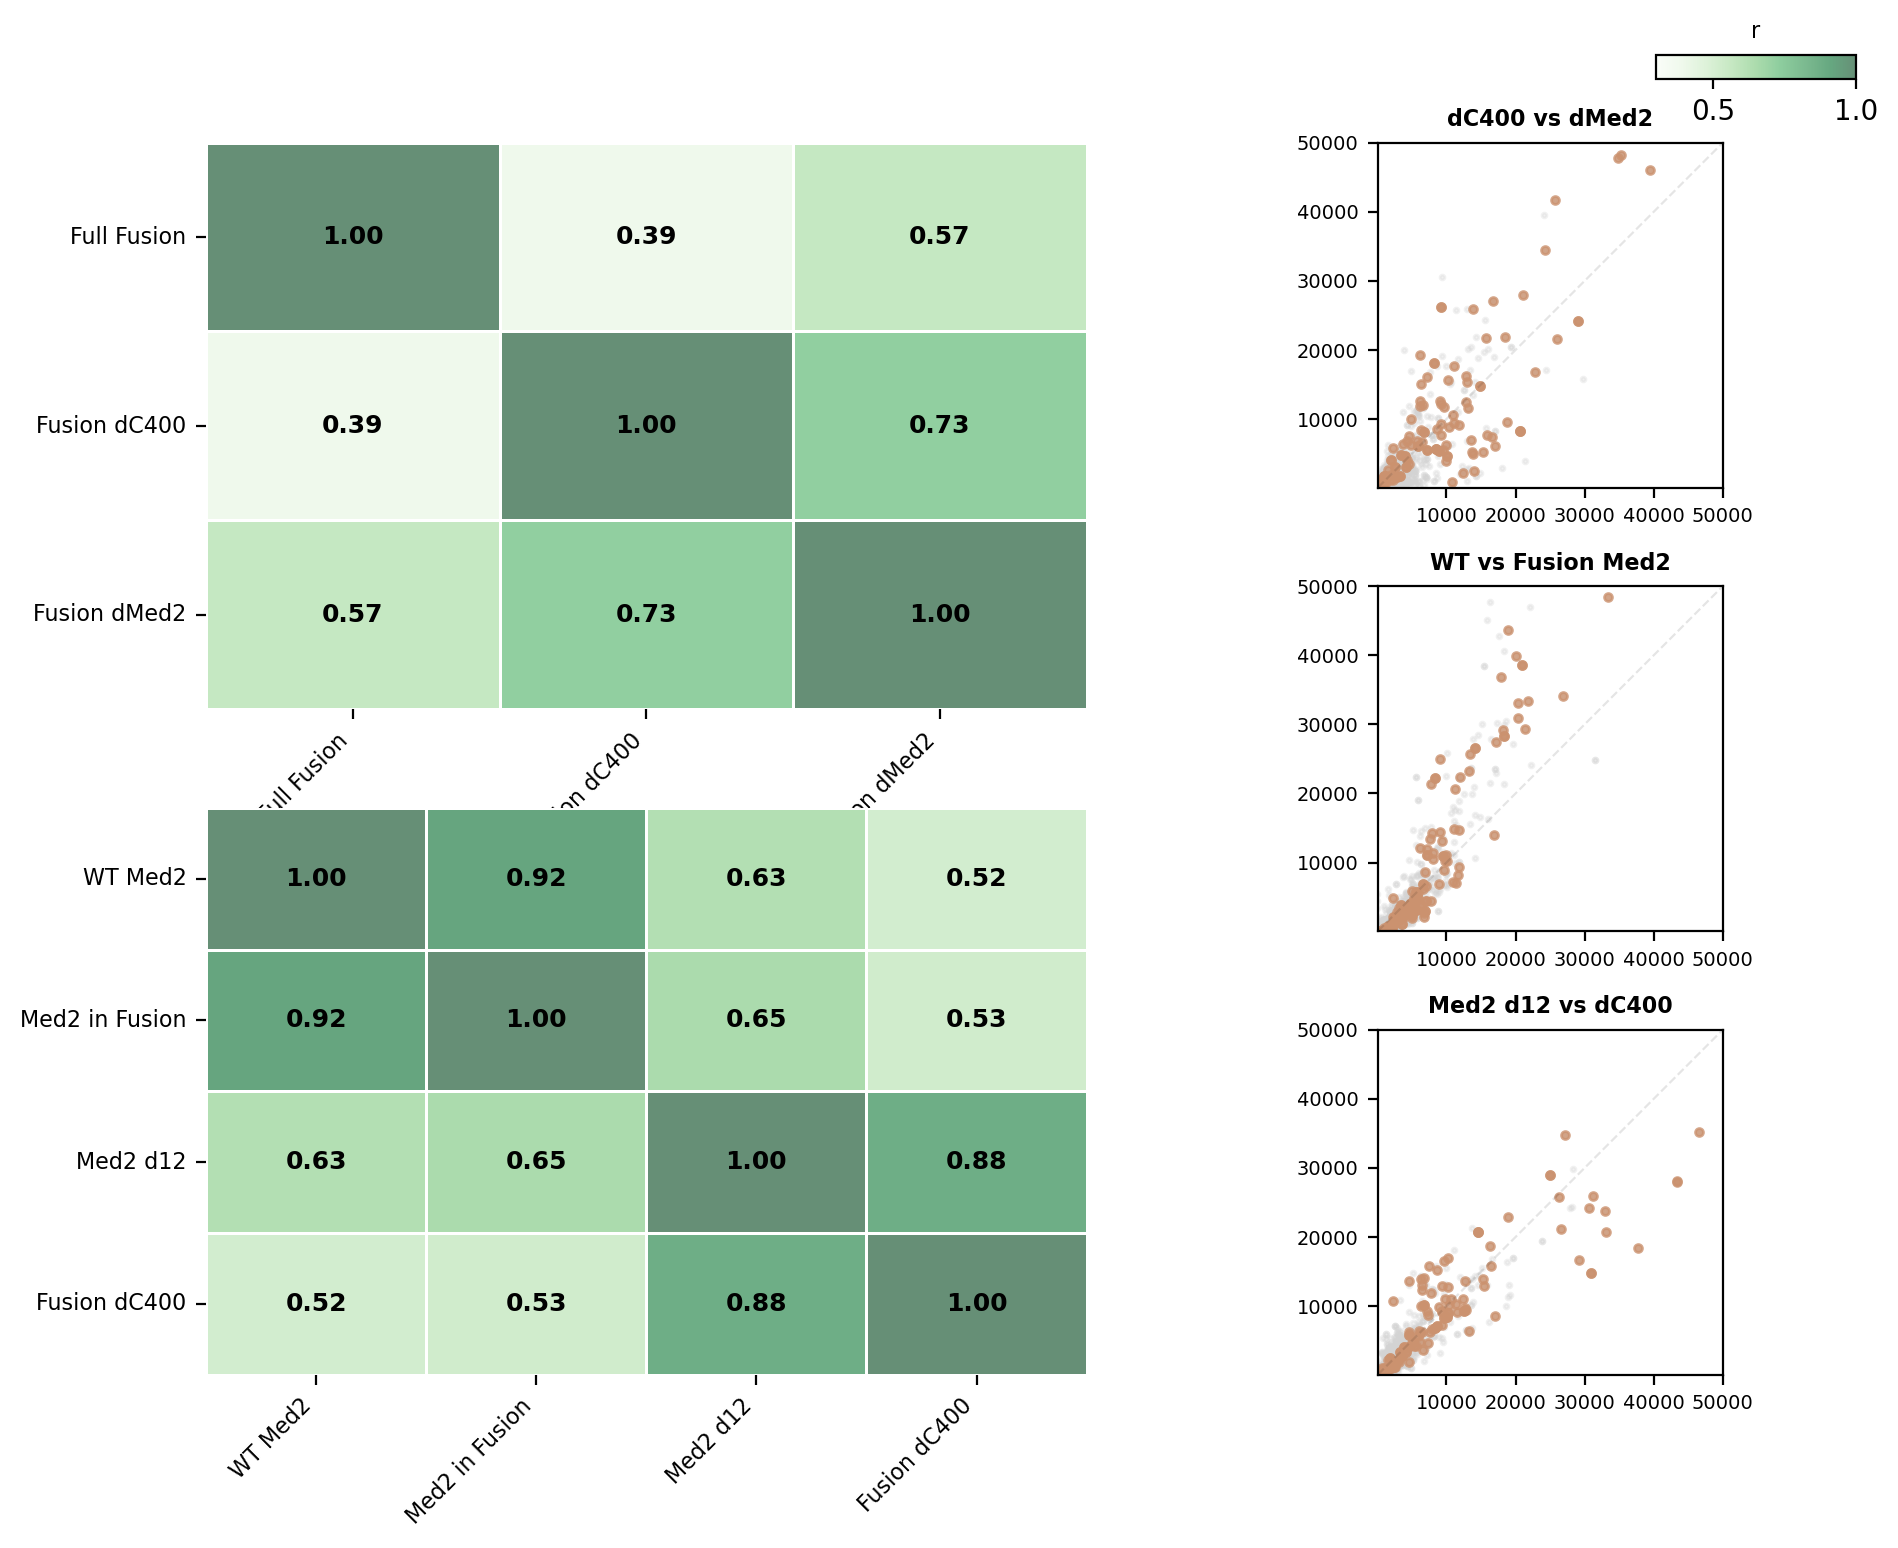

In [59]:
WT_sys = WT_system_data[~WT_system_data.index.duplicated(keep='first')]
d12_sys = d12_system_data[~d12_system_data.index.duplicated(keep='first')]
common_idx = WT_sys.index.intersection(d12_sys.index)

wt_ref_col, fusion_ref_col, d12_unfused_col = 'Med15_WT_Mnase', 'med15_msn2dbd_mnase', 'Med15_Mnase_d12'
fold_change_threshold, signal_threshold = 2, 4000

wt_signal = WT_sys.loc[common_idx, wt_ref_col]
d12_signal = d12_sys.loc[common_idx, d12_unfused_col] if d12_unfused_col in d12_sys.columns else pd.Series(0, index=common_idx)
fusion_signal = d12_sys.loc[common_idx, fusion_ref_col] if fusion_ref_col in d12_sys.columns else pd.Series(0, index=common_idx)

targets_lost_rescued = common_idx[
    (wt_signal > signal_threshold) & 
    (wt_signal > fold_change_threshold * d12_signal) & 
    (fusion_signal > signal_threshold) & 
    (fusion_signal > fold_change_threshold * d12_signal)
]
valid_targs = d12_sys.index.intersection(targets_lost_rescued)

h1_labels = ['Full Fusion', 'Fusion dC400', 'Fusion dMed2']
h1_configs = {
    'Full Fusion': ('med15_msn2dbd_mnase', d12_sys), 
    'Fusion dC400': ('Med15_Msn2_DBD_C400', d12_sys), 
    'Fusion dMed2': ('Med15_Fusion_dMed2', d12_sys)
}

h2_labels = ['WT Med2', 'Med2 in Fusion', 'Med2 d12', 'Fusion dC400']
h2_configs = {
    'WT Med2': ('Med2_Mnase', WT_sys), 
    'Med2 in Fusion': ('Med15_Msn2DBD_Med2_Mnase', d12_sys), 
    'Med2 d12': ('d12_Med2_Mnase', d12_sys), 
    'Fusion dC400': ('Med15_Msn2_DBD_C400', d12_sys)
}

def get_restricted_corr_matrix(labels, config_dict, target_subset):
    data = pd.DataFrame(index=target_subset)
    for lbl in labels:
        col, df = config_dict[lbl]
        if col in df.columns: data[lbl] = df.loc[target_subset, col]
    return data.dropna().corr()

corr1 = get_restricted_corr_matrix(h1_labels, h1_configs, valid_targs)
corr2 = get_restricted_corr_matrix(h2_labels, h2_configs, valid_targs)

HIGHLIGHT_COLOR = '#CB926F'


fig = plt.figure(figsize=(10, 8))


gs = fig.add_gridspec(6, 2, hspace=0.8, wspace=0.4, width_ratios=[1.5, 0.7])

ax_h1 = fig.add_subplot(gs[0:3, 0])  
ax_h2 = fig.add_subplot(gs[3:6, 0])  

ax_s1 = fig.add_subplot(gs[0:2, 1]) 
ax_s2 = fig.add_subplot(gs[2:4, 1])  
ax_s3 = fig.add_subplot(gs[4:6, 1])  

# --- Plot Heatmaps ---
heatmap_args = {
    'annot': True, 'cmap': pastel_cmap, 'vmin': 0.3, 'vmax': 1.0, 'fmt': ".2f",
    'annot_kws': {"weight": "bold", "fontsize": 9, "color": "black"},
    'linewidths': 1, 'cbar': False

}

sns.heatmap(corr1, ax=ax_h1, **heatmap_args)

sns.heatmap(corr2, ax=ax_h2, **heatmap_args)


# --- Smaller Layered Scatters ---
def plot_compact_scatter(ax, df_x, col_x, df_y, col_y, title):
    common = df_x.index.intersection(df_y.index)
    
    # Background (grey dots)
    ax.scatter(df_x.loc[common, col_x], df_y.loc[common, col_y], color='lightgrey', s=3, alpha=0.3)
    # Foreground (highlighted top targets)
    ax.scatter(df_x.loc[valid_targs, col_x], df_y.loc[valid_targs, col_y], color=HIGHLIGHT_COLOR, s=8, alpha=0.8)
    
    lims = [100, 50000]
    ax.set_xlim(lims)
    ax.set_ylim(lims)
    
    # Diagonal reference line
    ax.plot(lims, lims, 'k--', alpha=0.1, lw=0.8)
    ax.set_title(title, fontsize=8, fontweight='bold')
    ax.tick_params(axis='both', labelsize=7)
    
    # THE FIX: Force the plot box to be a perfect square, preventing it from stretching!
    ax.set_box_aspect(1)

plot_compact_scatter(ax_s1, d12_sys, 'Med15_Msn2_DBD_C400', d12_sys, 'Med15_Fusion_dMed2', "dC400 vs dMed2")
plot_compact_scatter(ax_s2, WT_sys, 'Med2_Mnase', d12_sys, 'Med15_Msn2DBD_Med2_Mnase', "WT vs Fusion Med2")
plot_compact_scatter(ax_s3, d12_sys, 'd12_Med2_Mnase', d12_sys, 'Med15_Msn2_DBD_C400', "Med2 d12 vs dC400")

# --- Formatting ---
for ax in [ax_h1, ax_h2]:
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right', fontsize=8)
    ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=8)

# Colorbar (Small, top right, above scatterplots)
cbar_ax = fig.add_axes([0.85, 0.92, 0.1, 0.015]) 
sm = cm.ScalarMappable(norm=plt.Normalize(0.3, 1.0), cmap=pastel_cmap)
fig.colorbar(sm, cax=cbar_ax, orientation='horizontal')
cbar_ax.set_title("r", fontsize=8)

plt.show()

# SupFigure 1

## SupFigure 1A

/tmp/ipykernel_229869/1393207727.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


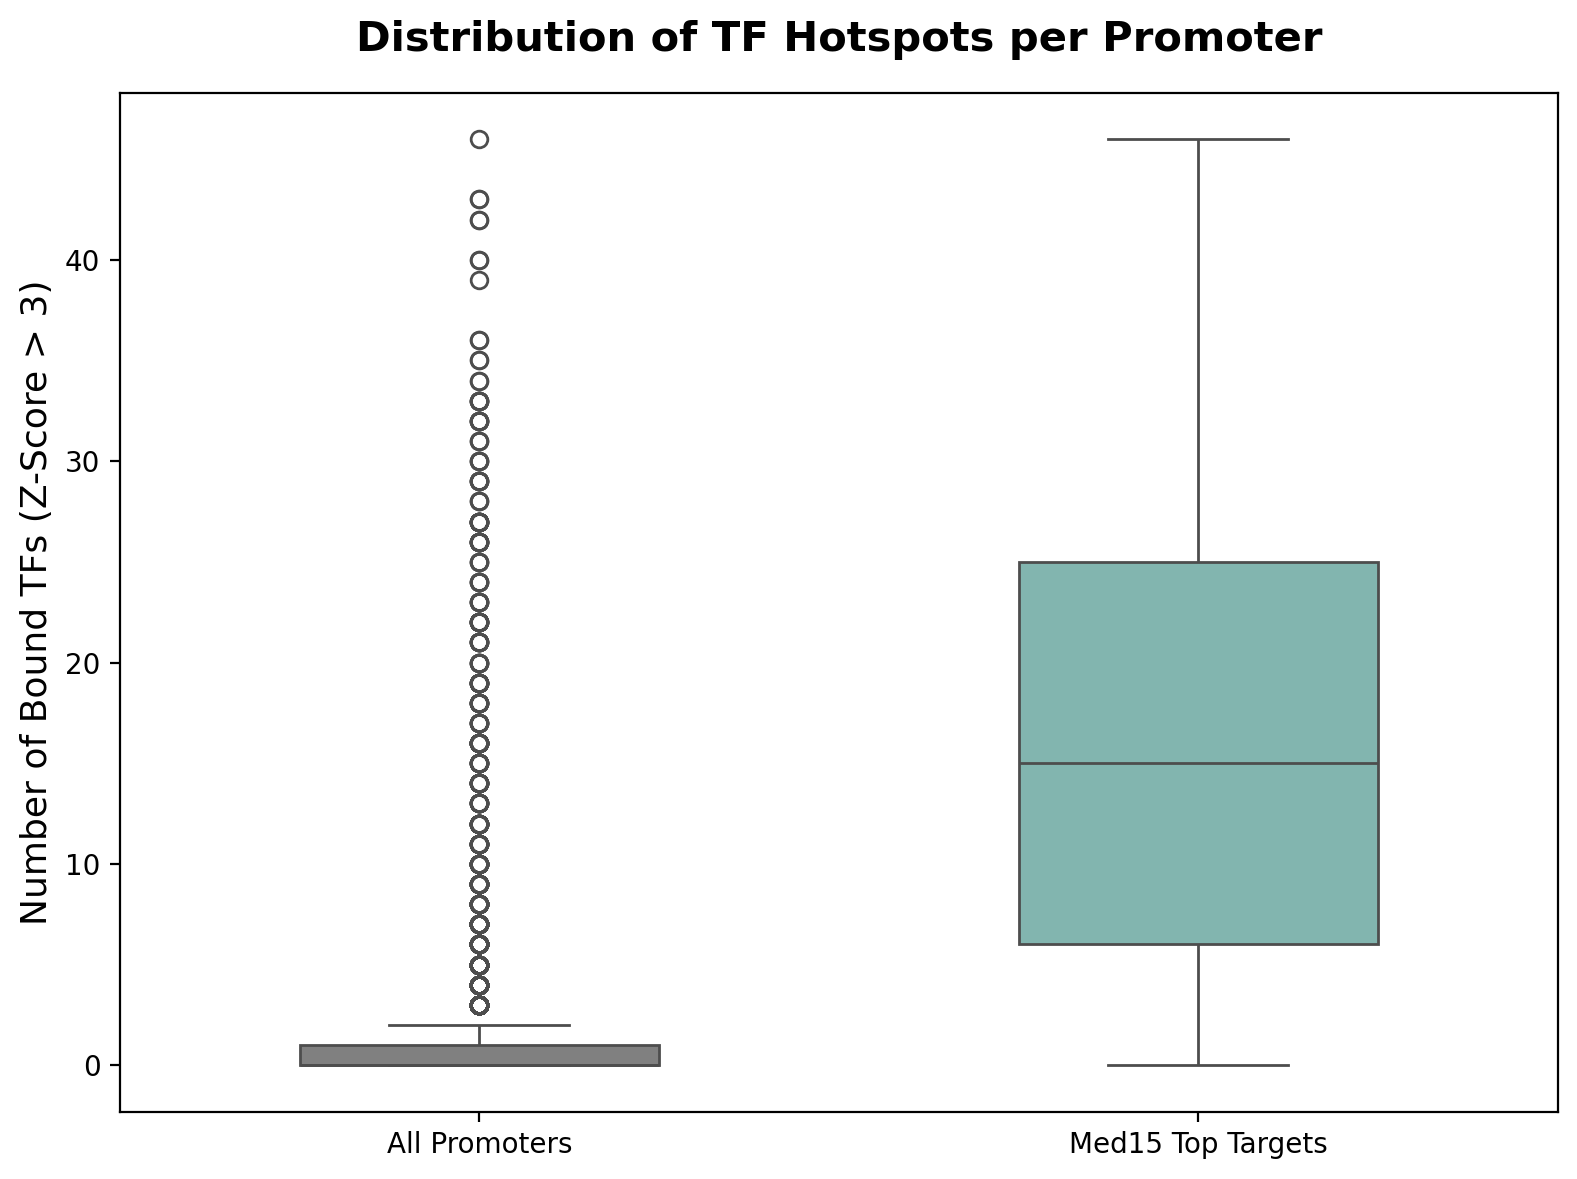

In [60]:
z_scores = (all_TFs - all_TFs.mean()) / all_TFs.std()

valid_targets = z_scores.index.intersection(med15_top_targets)
z_threshold = 3


tf_counts_all = (z_scores > z_threshold).sum(axis=1)

df_all = pd.DataFrame({
    'Bound TF Count': tf_counts_all,
    'Group': 'All Promoters'
})

df_top = pd.DataFrame({
    'Bound TF Count': tf_counts_all.loc[valid_targets],
    'Group': 'Med15 Top Targets'
})

df_plot = pd.concat([df_all, df_top]).reset_index(drop=True)
fig, ax = plt.subplots(figsize=(8, 6))

# Box plot
sns.boxplot(
    data=df_plot,
    x='Group',
    y='Bound TF Count',
    palette={'All Promoters': 'gray', 'Med15 Top Targets': '#7ABDB5'},
    width=0.5,
    ax=ax
)

ax.set_title('Distribution of TF Hotspots per Promoter', fontsize=15, fontweight='bold', pad=15)
ax.set_xlabel('') 
ax.set_ylabel(f'Number of Bound TFs (Z-Score > {z_threshold})', fontsize=13)

plt.tight_layout()
plt.show()

## SupFigure 1B

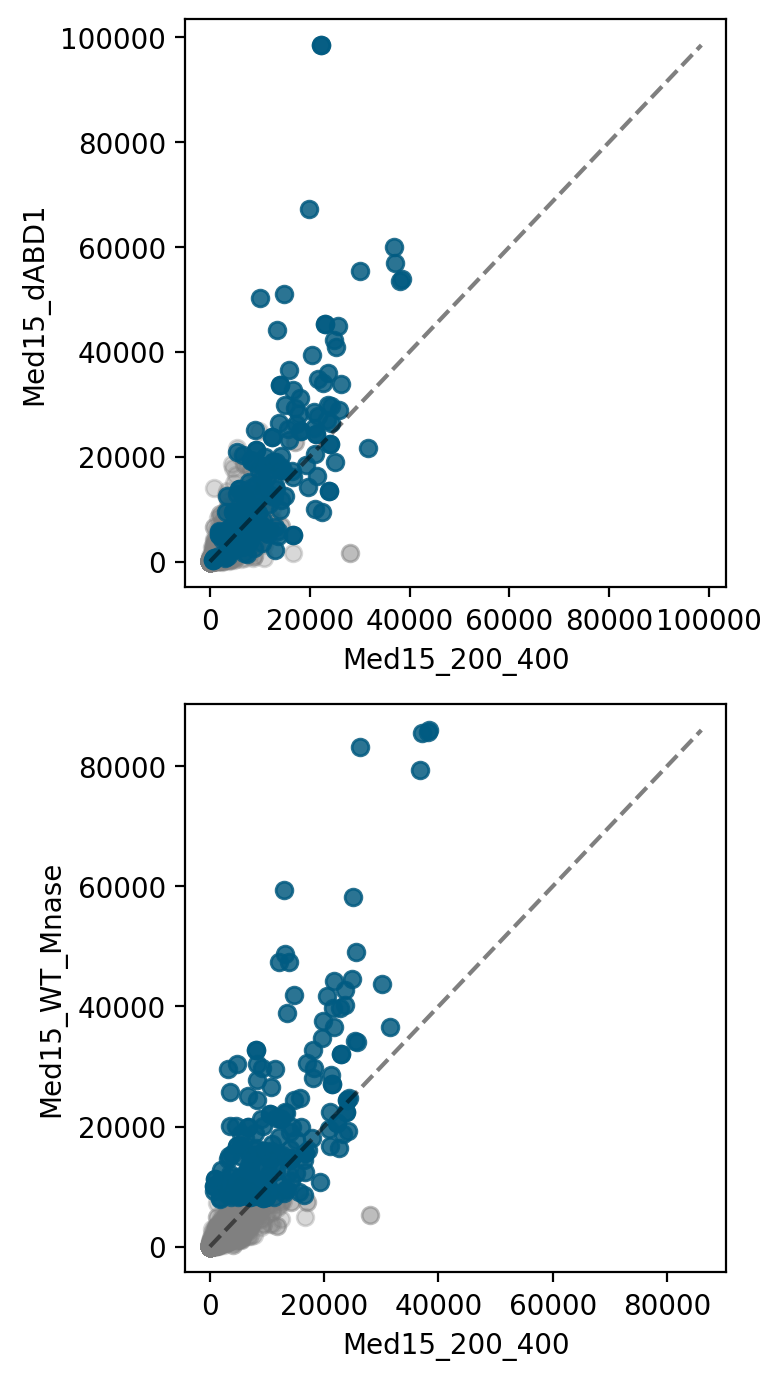

In [61]:
fig, axes = plt.subplots(2, 1, figsize=(4, 7))

ax1 = axes[0]
ax1.scatter(
    WT_system_data['Med15_200_400'], WT_system_data['Med15_dABD1'], 
    alpha=0.3, color='grey', rasterized=True, label='All genes'
)
ax1.scatter(
    WT_system_data['Med15_200_400'].loc[med15_top_targets], WT_system_data['Med15_dABD1'].loc[med15_top_targets],
    alpha=0.8, color='#005b82', edgecolor='#005b82',
    label='Top Med15 targets', rasterized=True
)

max_val1 = max(WT_system_data['Med15_200_400'].max(), WT_system_data['Med15_dABD1'].max())
ax1.plot([0, max_val1], [0, max_val1], '--', color='black', alpha=0.5)

 

ax1.set_xlabel('Med15_200_400')
ax1.set_ylabel('Med15_dABD1')

ax2 = axes[1]
ax2.scatter(
    WT_system_data['Med15_200_400'], WT_system_data['Med15_WT_Mnase'], 
    alpha=0.3, color='grey', rasterized=True, label='All genes'
)
ax2.scatter(
    WT_system_data['Med15_200_400'].loc[med15_top_targets], WT_system_data['Med15_WT_Mnase'].loc[med15_top_targets],
    alpha=0.8, color='#005b82', edgecolor='#005b82',
    label='Top Med15 targets', rasterized=True
)

max_val2 = max(WT_system_data['Med15_200_400'].max(), WT_system_data['Med15_WT_Mnase'].max())
ax2.plot([0, max_val2], [0, max_val2], '--', color='black', alpha=0.5)


ax2.set_xlabel('Med15_200_400')
ax2.set_ylabel('Med15_WT_Mnase')

plt.tight_layout()
plt.show()

## SupFigure 1C

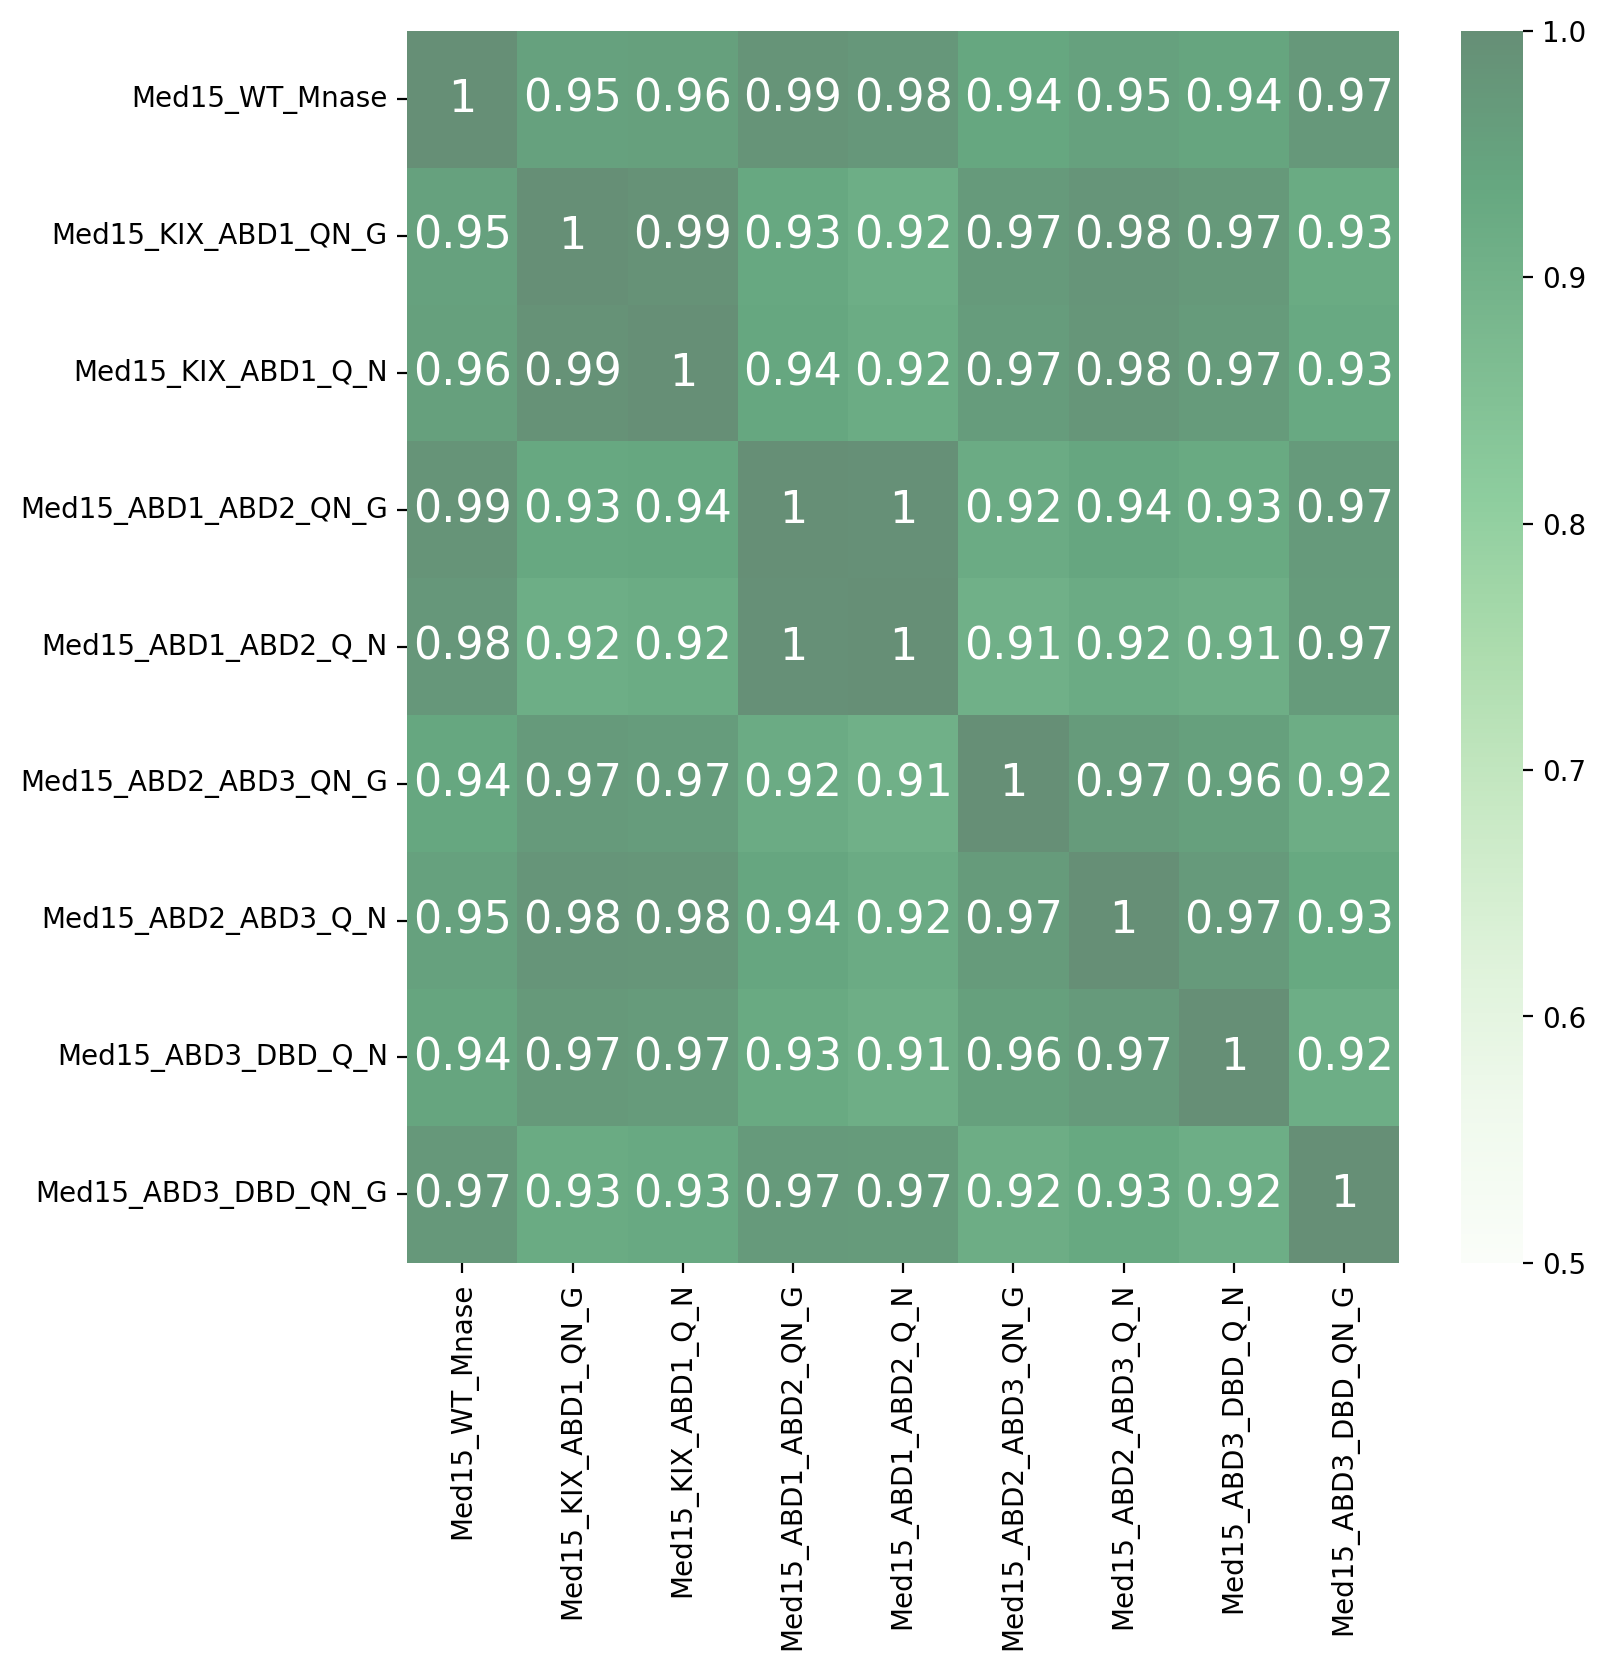

In [62]:
corr_matrix = WT_system_data[['Med15_WT_Mnase','Med15_KIX_ABD1_QN_G', 'Med15_KIX_ABD1_Q_N','Med15_ABD1_ABD2_QN_G', 'Med15_ABD1_ABD2_Q_N','Med15_ABD2_ABD3_QN_G',
       'Med15_ABD2_ABD3_Q_N','Med15_ABD3_DBD_Q_N',
       'Med15_ABD3_DBD_QN_G']].corr()

filtered_corr_matrix = corr_matrix

plt.subplots(figsize=(8, 8))
heatmap = sns.heatmap(filtered_corr_matrix, annot=True, fmt=".2g", cmap=pastel_cmap, vmax=1, vmin=0.5, annot_kws={"size": 16, 'rotation':0})

plt.show()

## SupFigure 1D

In [63]:
SFig_1A_Floc = Flocculation.T.filter(regex='WT|N100|N200|100-300|KIX')

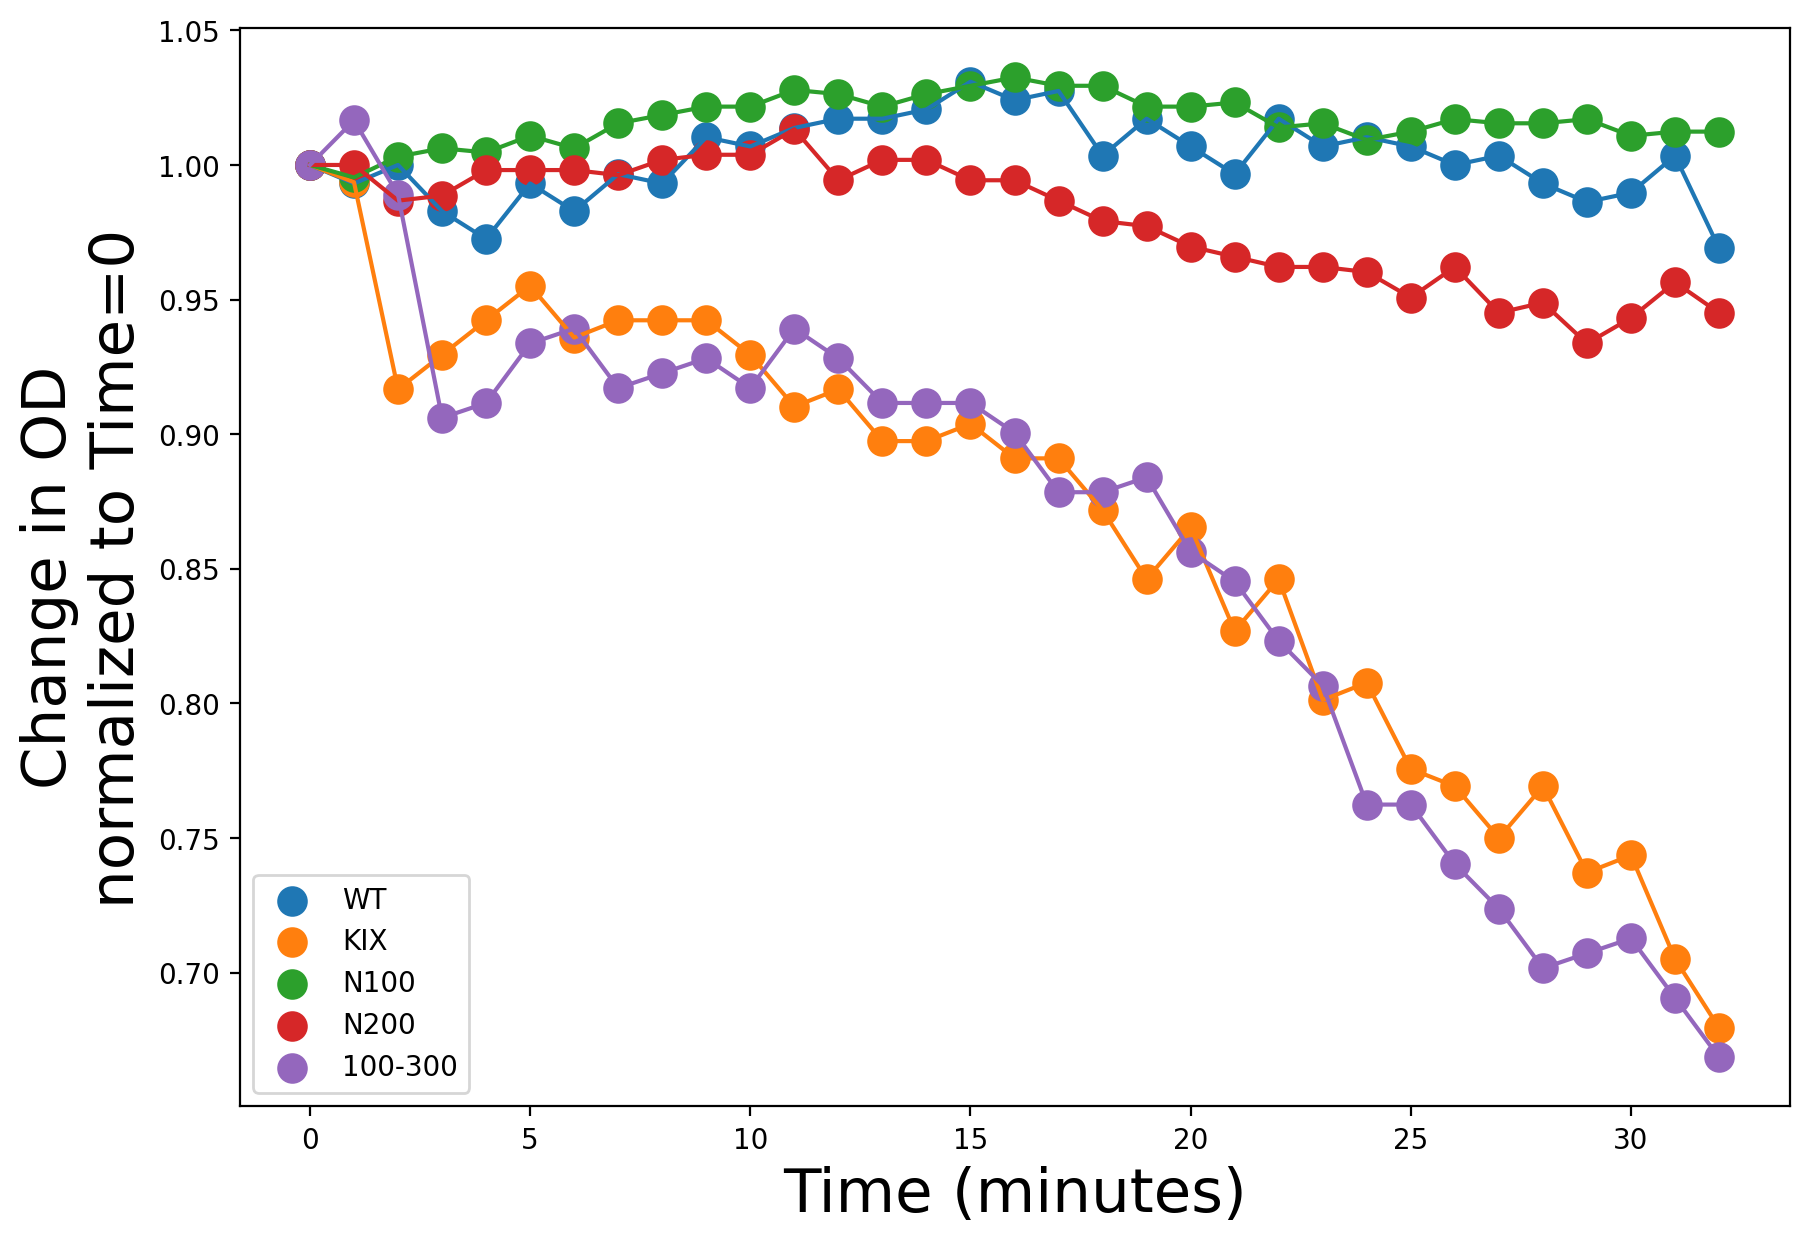

In [64]:
plt.subplots(figsize=(10,7))
for idx, column in enumerate(SFig_1A_Floc):
    x_values = range(0,33)
    y_values = SFig_1A_Floc[column]

    plt.scatter(x_values, y_values,s=100, label = column)
    plt.plot(x_values, y_values)

plt.xlabel('Time (minutes)',fontsize=22)
plt.ylabel('Change in OD \nnormalized to Time=0',fontsize=22)
plt.legend()
plt.show()

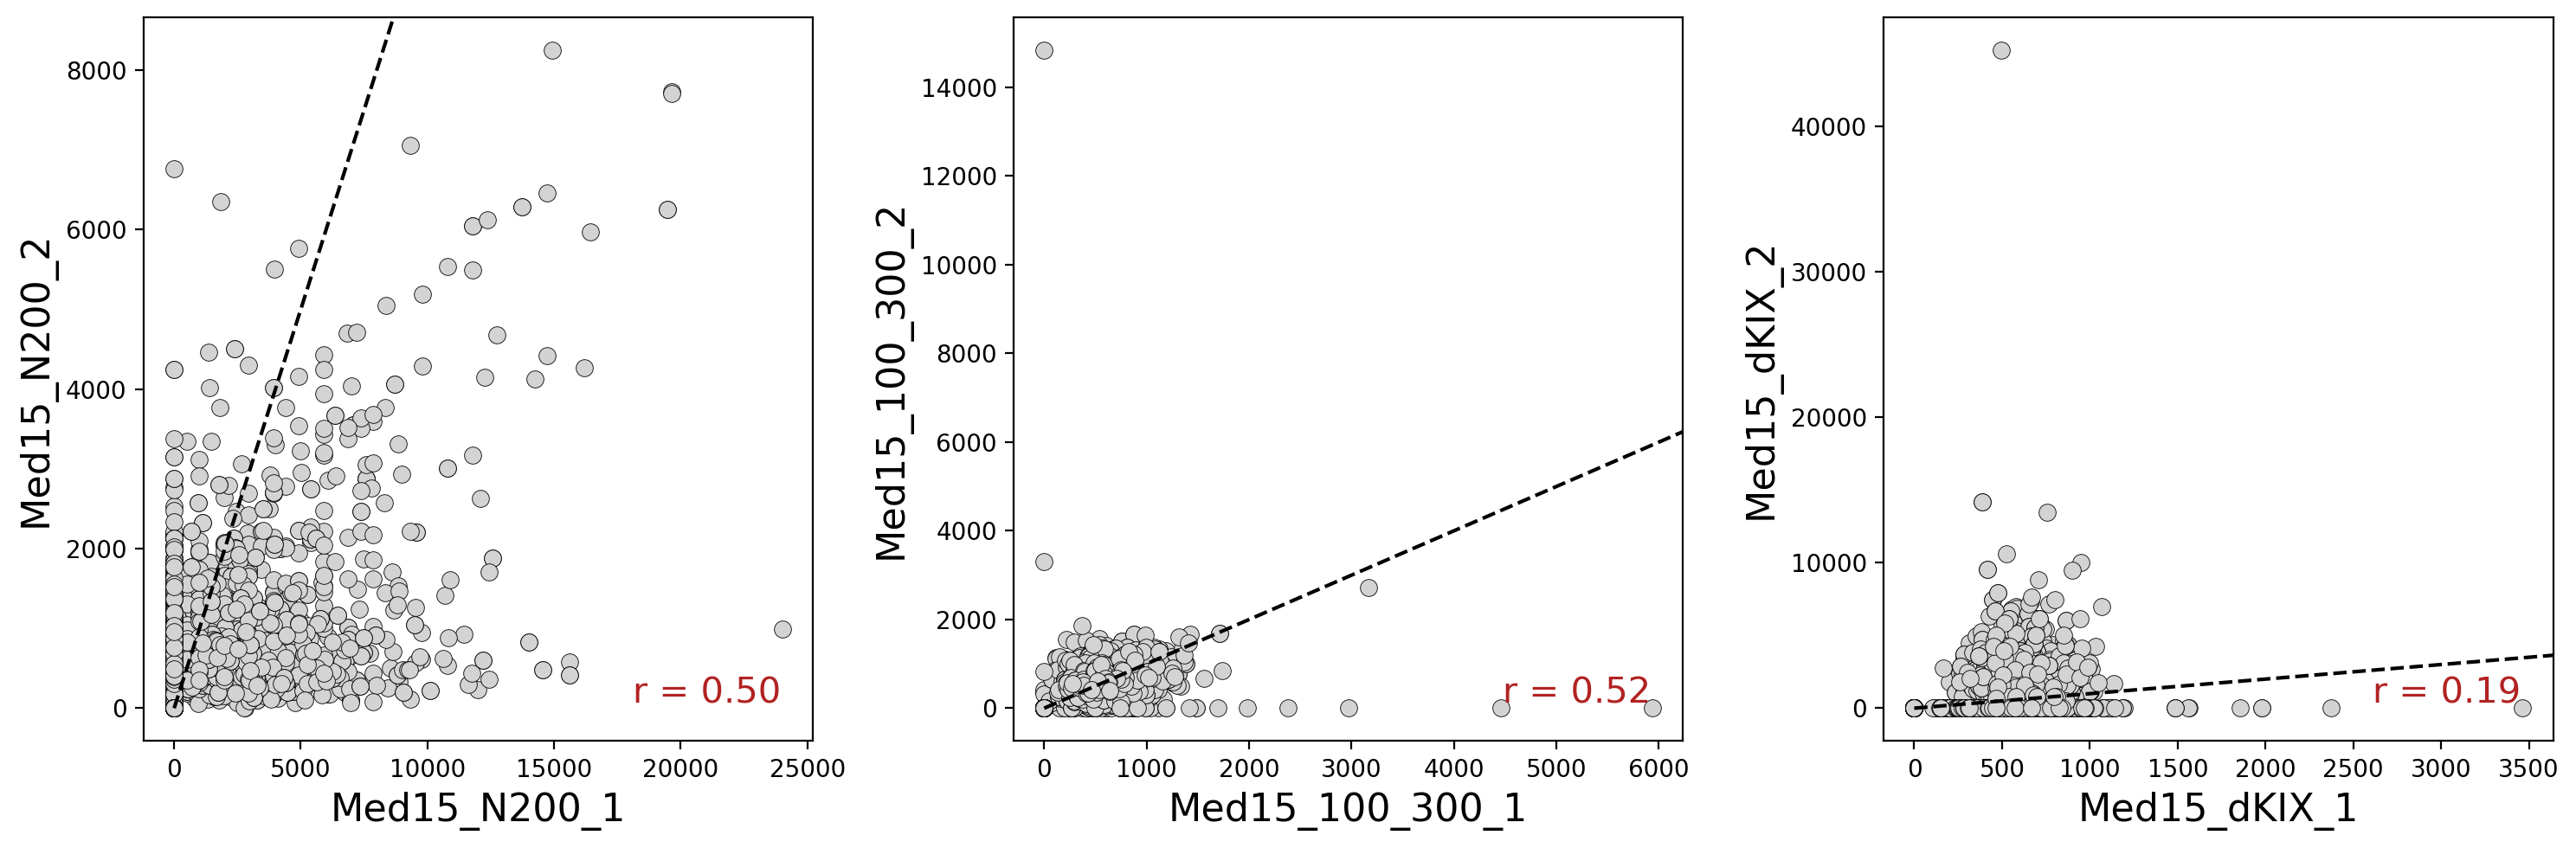

In [65]:
SFig_2A = Repeats[['Med15_N200_1', 'Med15_N200_2','Med15_100_300_1', 'Med15_100_300_2','Med15_dKIX_1', 'Med15_dKIX_2']]
fig, axes = plt.subplots(1, 3, figsize=(15, 5), tight_layout=True)

scatter_pairs = [
    ('Med15_N200_1', 'Med15_N200_2'),
    ( 'Med15_100_300_1', 'Med15_100_300_2'),
    ('Med15_dKIX_1','Med15_dKIX_2')
]


for i, (x_col, y_col) in enumerate(scatter_pairs):
    ax = axes[i]  
    x_data = SFig_2A[x_col]
    y_data = SFig_2A[y_col]
    correlation = np.corrcoef(x_data, y_data)[0, 1]
    ax.scatter(x_data, y_data, c='lightgrey', s=50, ec='k',lw=0.3)


    x_lim = ax.get_xlim()
    y_lim = ax.get_ylim()
    xy_min, xy_max = min(x_data.min(), y_data.min()), max(x_data.max(), y_data.max())
    ax.plot([xy_min, xy_max], [xy_min, xy_max], linestyle="--", color="k")


    ax.set_xlim(x_lim)
    ax.set_ylim(y_lim)

    # Labels
    ax.set_xlabel(x_col, fontsize=16)
    ax.set_ylabel(y_col, fontsize=16)
    
    ax.text(
        x_lim[1] * 0.95,
        y_lim[0] * 0.09,   
        f"r = {correlation:.2f}",
        fontsize=15,
        color="firebrick",
        ha="right",
        va="bottom",
    )

plt.show()

## SupFigure 1E

Text(0.5, 0, 'Correlation')

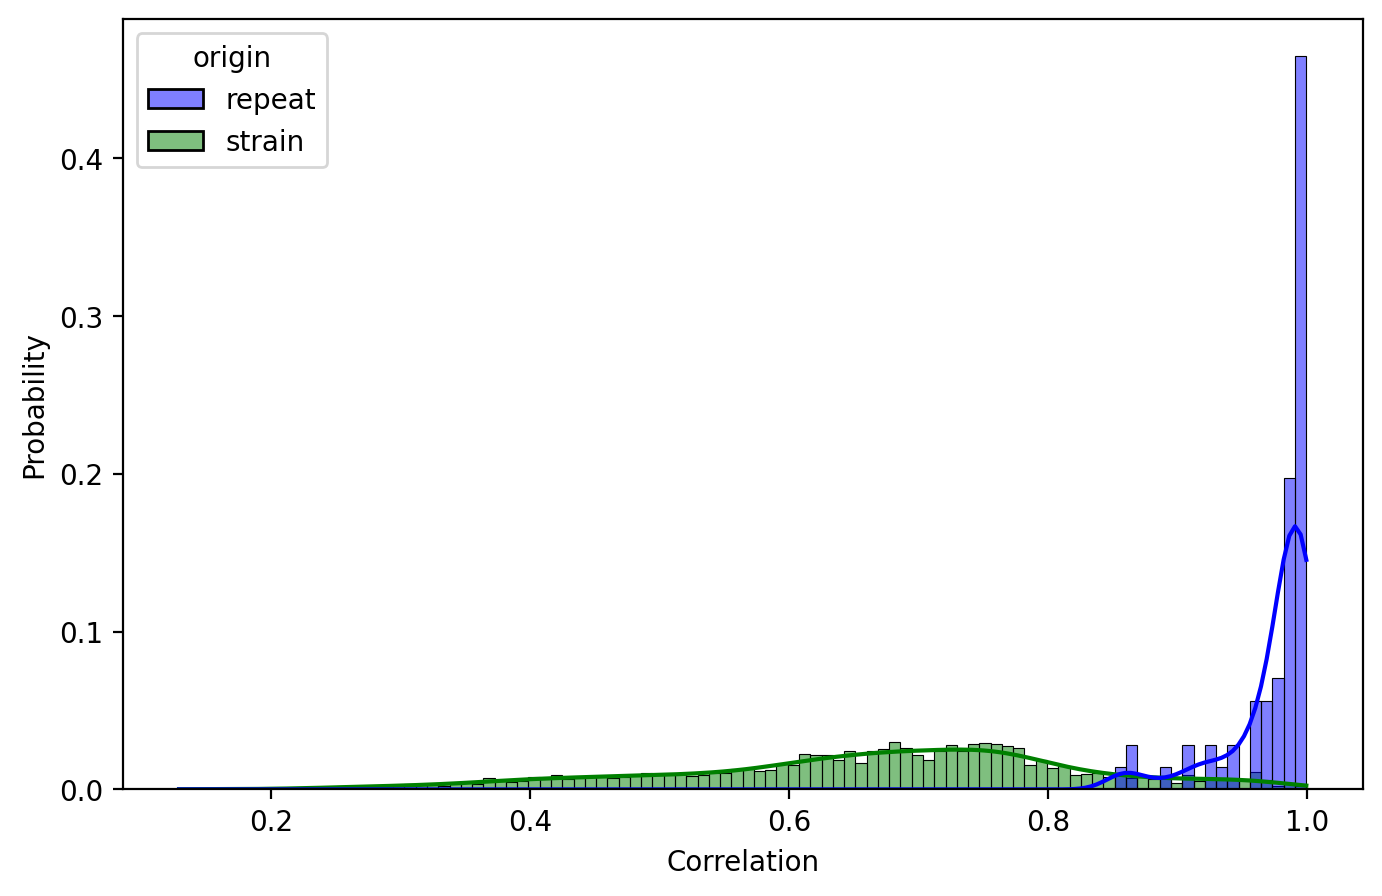

In [66]:
def get_strain_name(col):
    return re.sub(r'_\d+$', '', col)  


def get_repeat_pairs(df):
    pairs = {}
    for col in df.columns:
        strain = get_strain_name(col)
        if strain not in pairs:
            pairs[strain] = []
        pairs[strain].append(col)
    return {k: v for k, v in pairs.items() if len(v) == 2}  

def filter_repeats(df, threshold=0.85):
    repeat_pairs = get_repeat_pairs(df)
    passed = []
    filtered_corrs = []
    
    for strain, (rep1, rep2) in repeat_pairs.items():
        corr = df[[rep1, rep2]].corr().iloc[0, 1]
        if corr >= threshold:
            passed.extend([rep1, rep2])
            filtered_corrs.append(corr)  

    return df[passed], filtered_corrs  




df_filtered, repeat_corrs = filter_repeats(Repeats)


repeat_pairs = get_repeat_pairs(df_filtered)
df_avg = pd.DataFrame()
for strain, (rep1, rep2) in repeat_pairs.items():
    df_avg[strain] = df_filtered[[rep1, rep2]].mean(axis=1)

strain_corr_matrix = df_avg.corr()
strain_corr_values = strain_corr_matrix.values[np.triu_indices_from(strain_corr_matrix, k=1)]

comp_df = pd.concat([pd.DataFrame(dict(zip(repeat_corrs, repeat('repeat'))), index=['origin']).T,
pd.DataFrame(dict(zip(strain_corr_values, repeat('strain'))), index=['origin']).T,], axis=0)

a = comp_df.reset_index()

fig,ax = plt.subplots(figsize=(8, 5)) 
sns.histplot(data=a, x='index', hue='origin', common_norm=False, bins=100, kde=True, stat='probability', palette={'repeat': 'blue', 'strain': 'green'})
ax.set_xlabel('Correlation')

# SupFigure 2

## SupFigure 2A

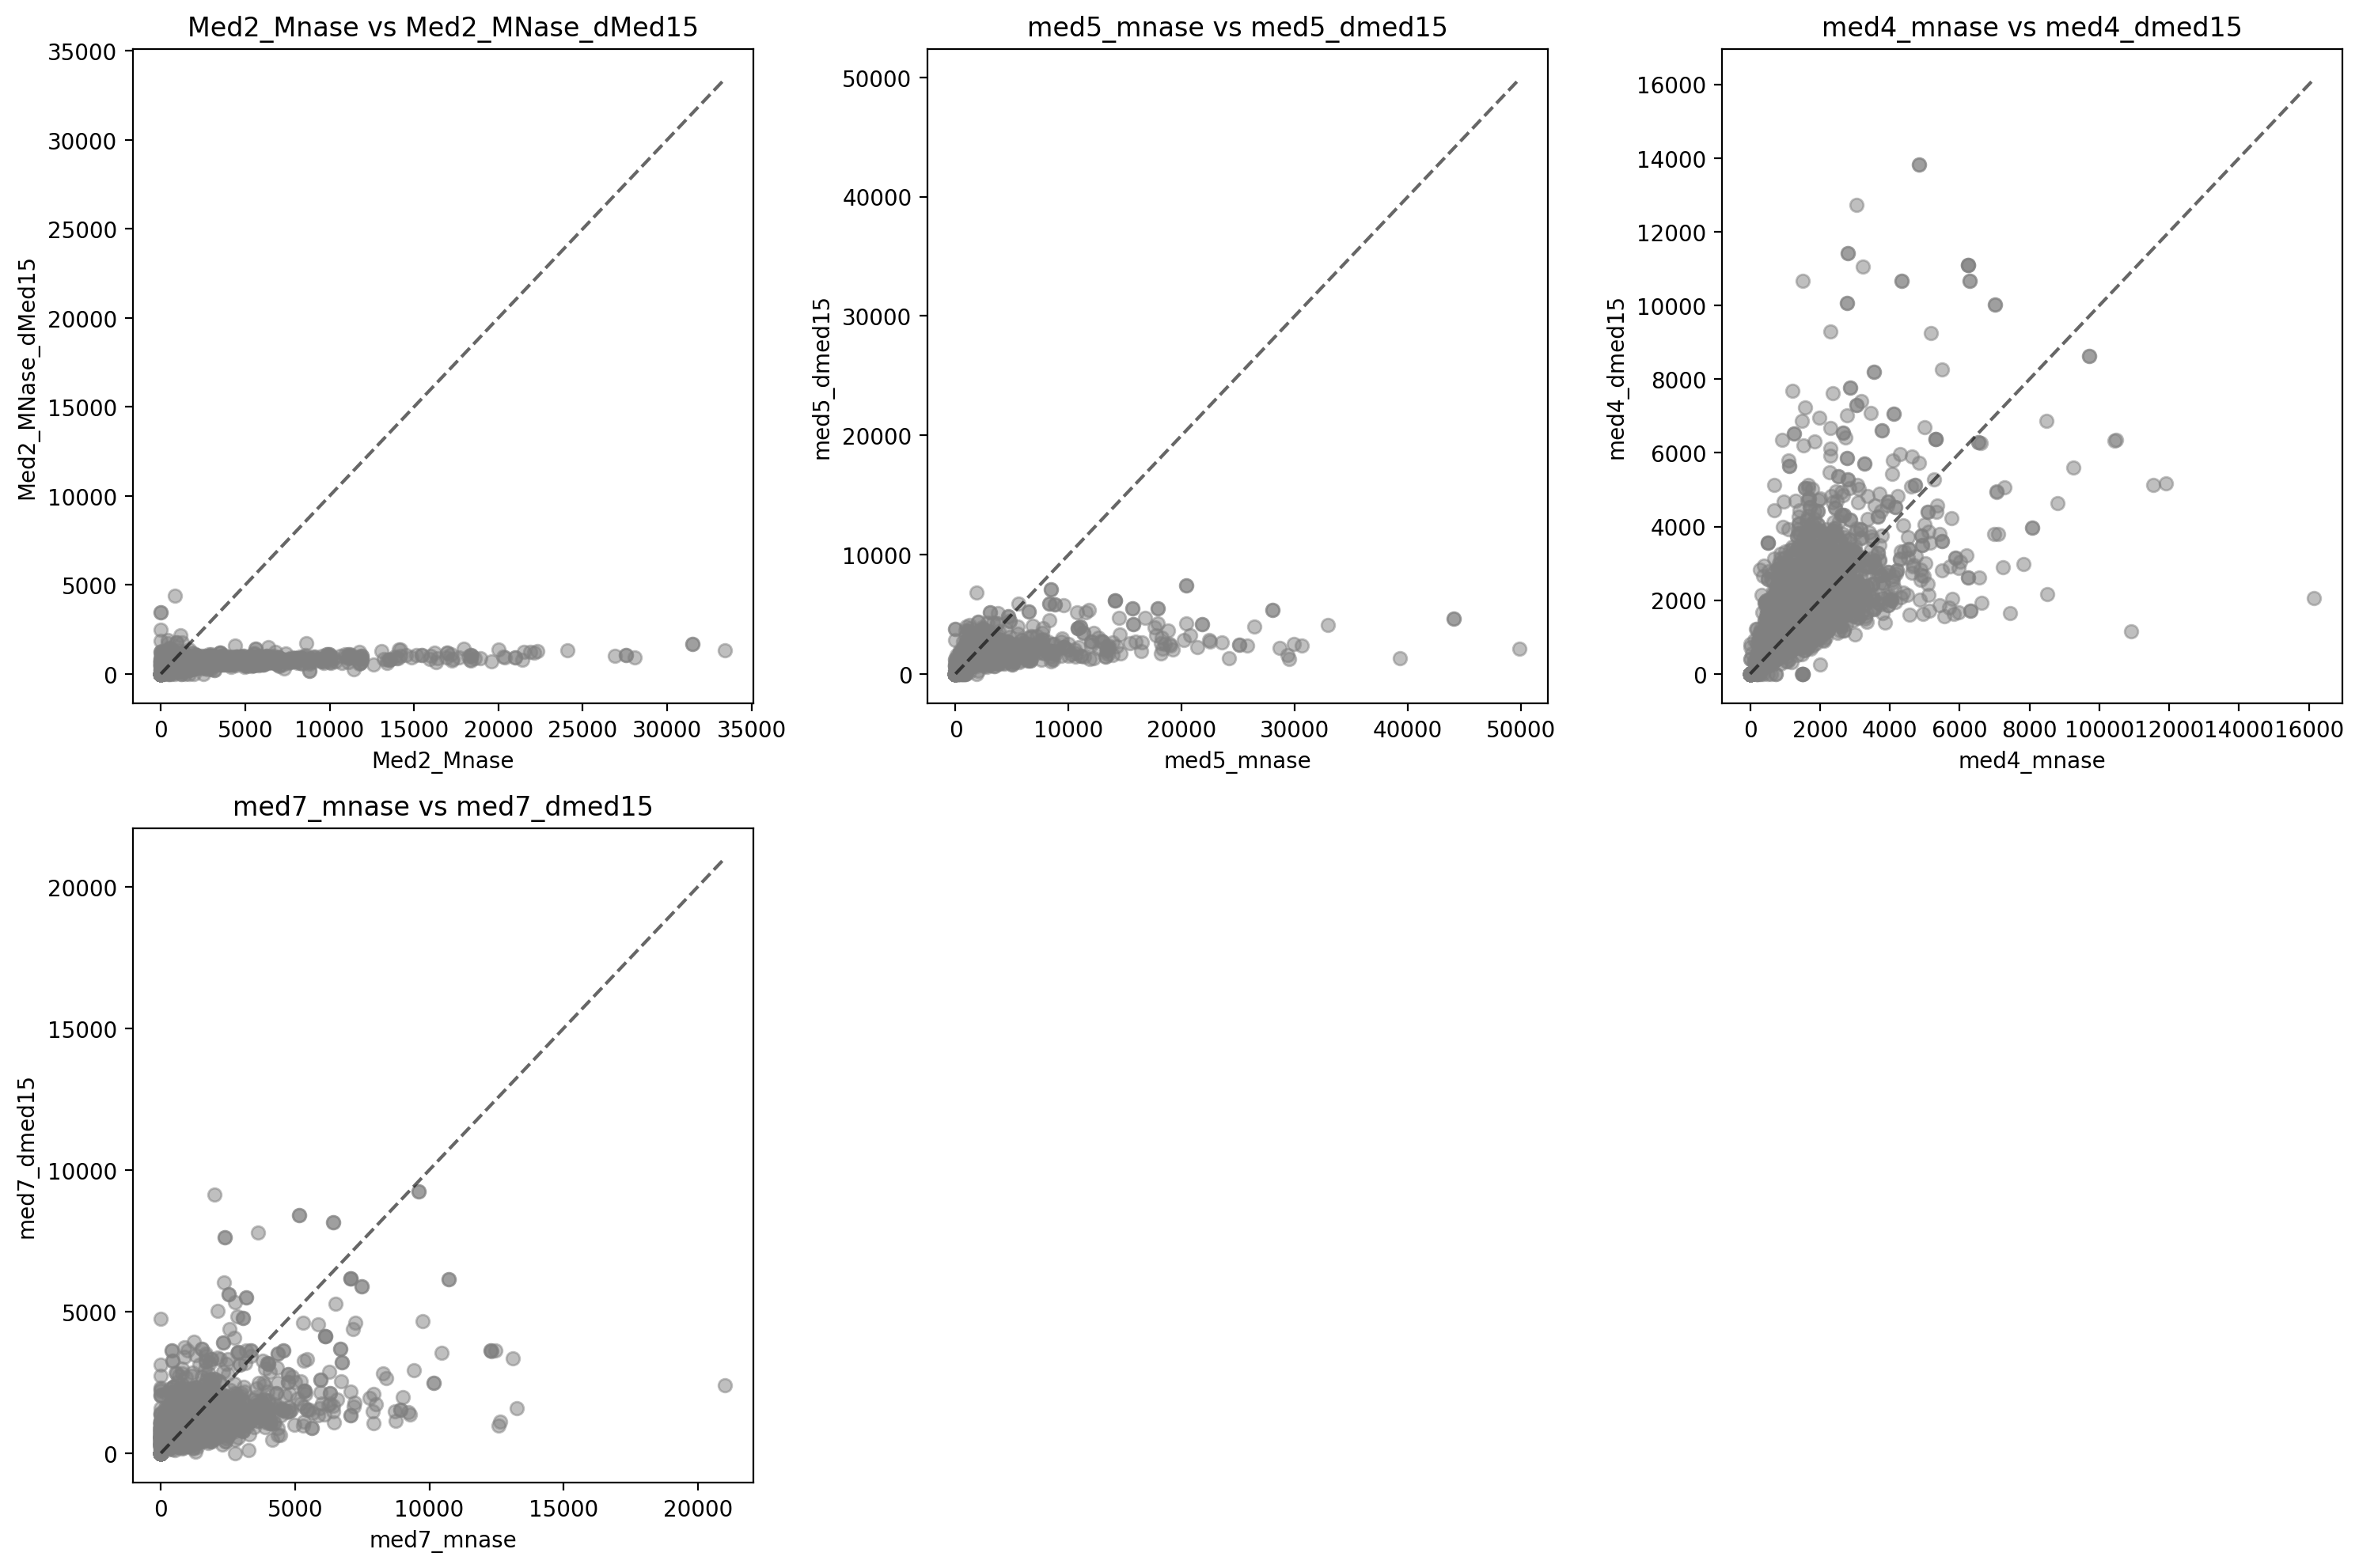

In [71]:
df = WT_system_data[['Med2_Mnase','Med2_MNase_dMed15','med5_mnase','med5_dmed15','med4_mnase','med4_dmed15','med7_mnase','med7_dmed15']]

pairs = []

for col in df.columns:
    if col.endswith('_Mnase') or col.endswith('_mnase') or '_WT' in col:
        base = col.lower().split('_')[0]
     
        matches = [c for c in df.columns if c.lower().startswith(base) and 'dmed15' in c.lower()]
        if matches:
            pairs.append( (col, matches[0]) )


# 3️⃣ Plotting
num_plots = len(pairs)
ncols = 3
nrows = (num_plots + ncols - 1) // ncols

fig, axes = plt.subplots(nrows, ncols, figsize=(5*ncols, 5*nrows), squeeze=False)

for ax, (wt_col, dmed15_col) in zip(axes.flatten(), pairs):
    ax.scatter(df[wt_col], df[dmed15_col], alpha=0.5, color='grey', edgecolor='grey', rasterized=True)
    ax.set_xlabel(wt_col)
    ax.set_ylabel(dmed15_col)
    ax.set_title(f'{wt_col} vs {dmed15_col}')
    ax.plot([df[wt_col].min(), df[wt_col].max()], [df[wt_col].min(), df[wt_col].max()], '--', color='black', alpha=0.6)

# Hide any empty subplots
for ax in axes.flatten()[len(pairs):]:
    ax.set_visible(False)

plt.tight_layout()
plt.show()


## SupFigure 2B

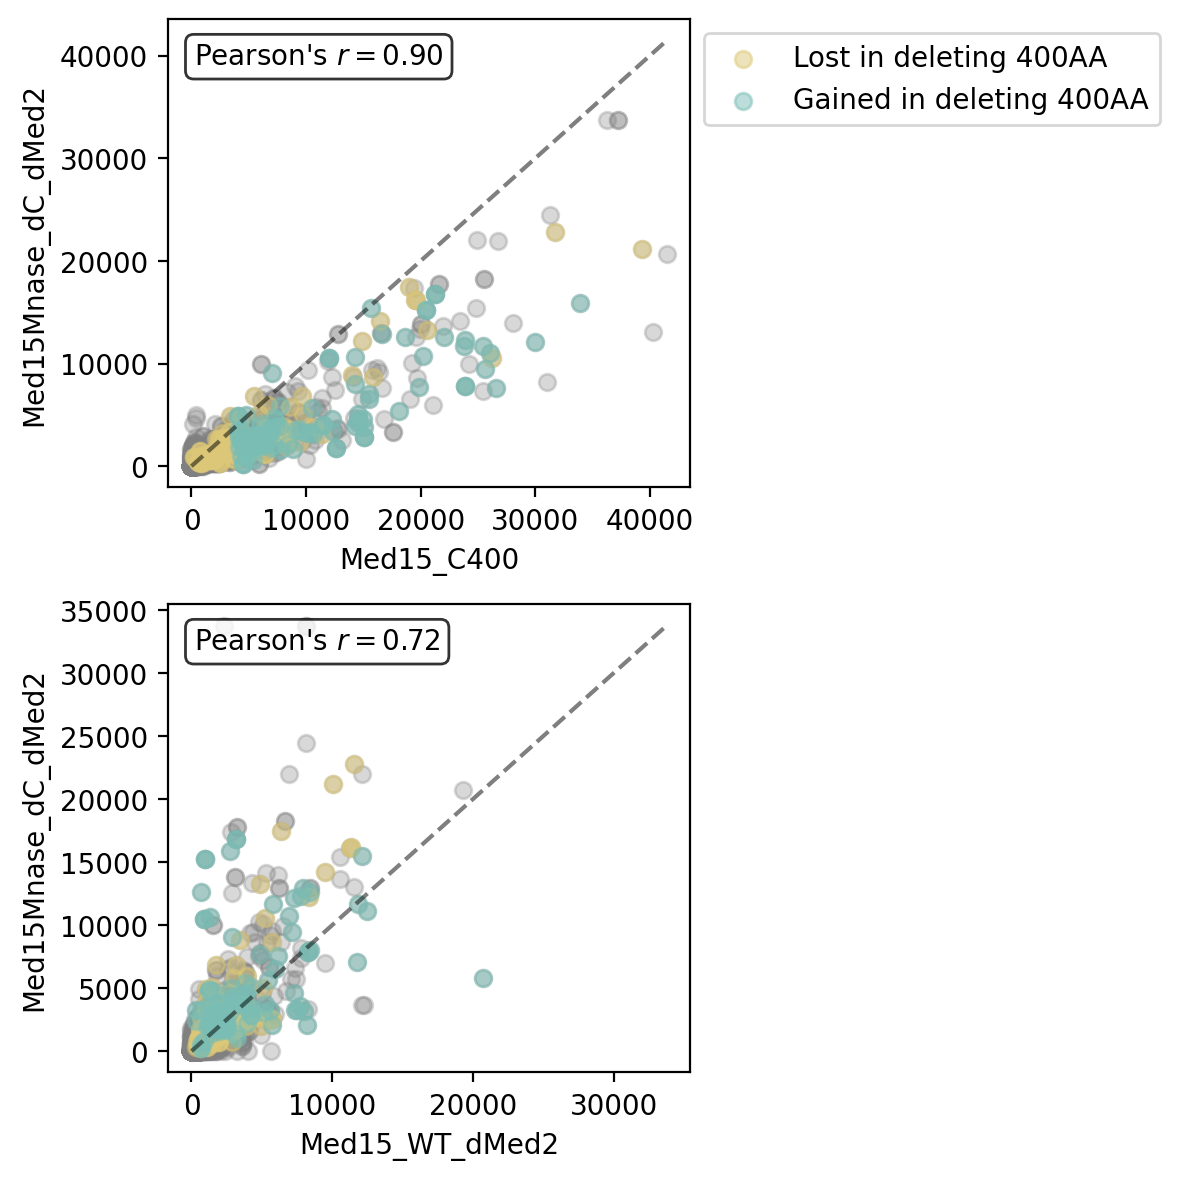

In [72]:
fig2, axes2 = plt.subplots(2, 1, figsize=(6, 6))

plot_med_comparison(axes2[0], Figure_3D, 'Med15_C400', 'Med15Mnase_dC_dMed2', lost_in_dC, gained_in_dC)

plot_med_comparison(axes2[1], Figure_3D, 'Med15_WT_dMed2', 'Med15Mnase_dC_dMed2', lost_in_dC, gained_in_dC)

axes2[0].legend(loc='upper left', bbox_to_anchor=(1, 1))
plt.tight_layout()
plt.show()

## SupFigure 2C

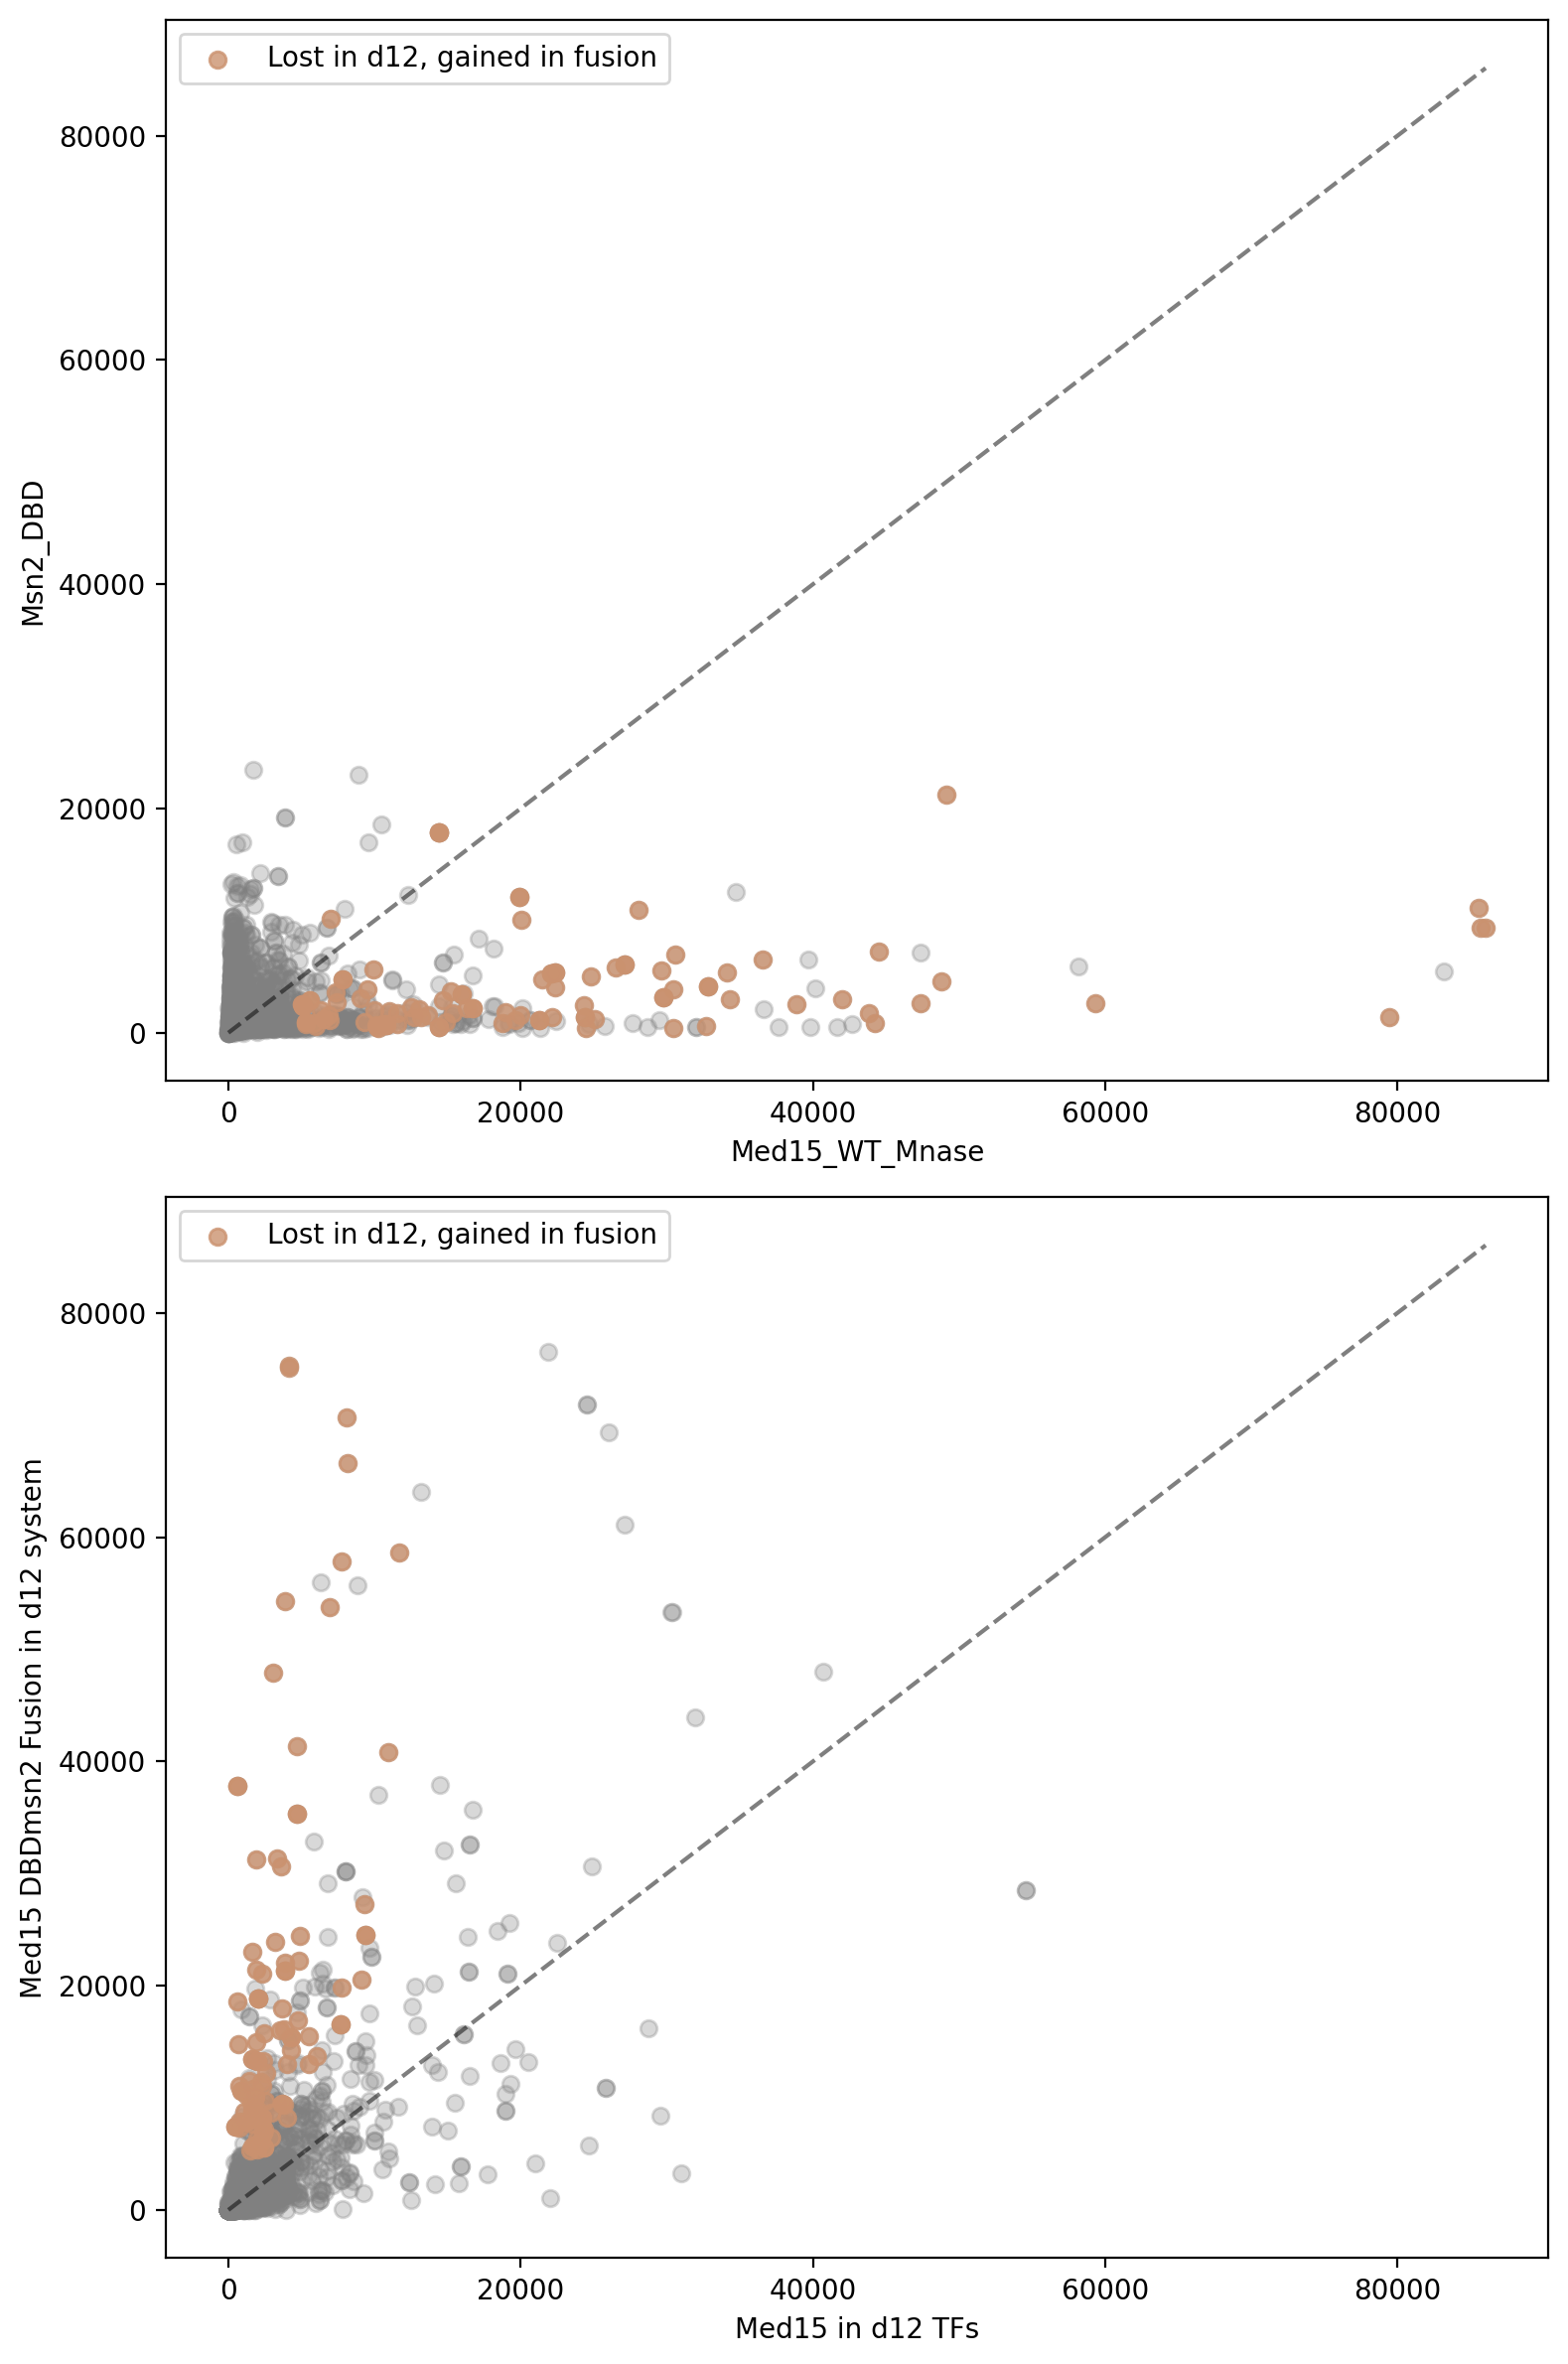

In [77]:
Sup_2C = WT_d12[['Msn2_DBD', 'Med15_WT_Mnase']]
fig, axes = plt.subplots(2, 1, figsize=(8, 12))

# Calculate the max value once to use for both plots
max_val = max(Sup_2C['Msn2_DBD'].max(), Sup_2C['Med15_WT_Mnase'].max())

# ==========================================
# Top Plot (axes[0])
# ==========================================
axes[0].scatter(Sup_2C['Med15_WT_Mnase'], Sup_2C['Msn2_DBD'], 
        alpha=0.3, 
        color='grey'
    )
axes[0].scatter(
        Sup_2C['Med15_WT_Mnase'].loc[lost_in_d12_gained_in_fusion], 
        Sup_2C['Msn2_DBD'].loc[lost_in_d12_gained_in_fusion],
        alpha=0.8, 
        color='#CB926F', edgecolor='#CB926F',
        label='Lost in d12, gained in fusion'
    )

axes[0].plot([0, max_val], [0, max_val], '--', color='black', alpha=0.5)
    
axes[0].set_ylabel('Msn2_DBD')
axes[0].set_xlabel('Med15_WT_Mnase')
axes[0].legend()


# ==========================================
# Bottom Plot (axes[1])
# ==========================================
axes[1].scatter(d12_system_data['Med15_Mnase_d12'], d12_system_data['med15_msn2dbd_mnase'], 
        alpha=0.3, 
        color='grey'
    )
axes[1].scatter(
        d12_system_data['Med15_Mnase_d12'].loc[lost_in_d12_gained_in_fusion], 
        d12_system_data['med15_msn2dbd_mnase'].loc[lost_in_d12_gained_in_fusion],
        alpha=0.8, 
        color='#CB926F', edgecolor='#CB926F',
        label='Lost in d12, gained in fusion'
    )

axes[1].plot([0, max_val], [0, max_val], '--', color='black', alpha=0.5)
    
axes[1].set_ylabel('Med15 DBDmsn2 Fusion in d12 system')
axes[1].set_xlabel('Med15 in d12 TFs')
axes[1].legend()

# Prevent labels/titles from overlapping
plt.tight_layout()
plt.show()

# SupFigure 3

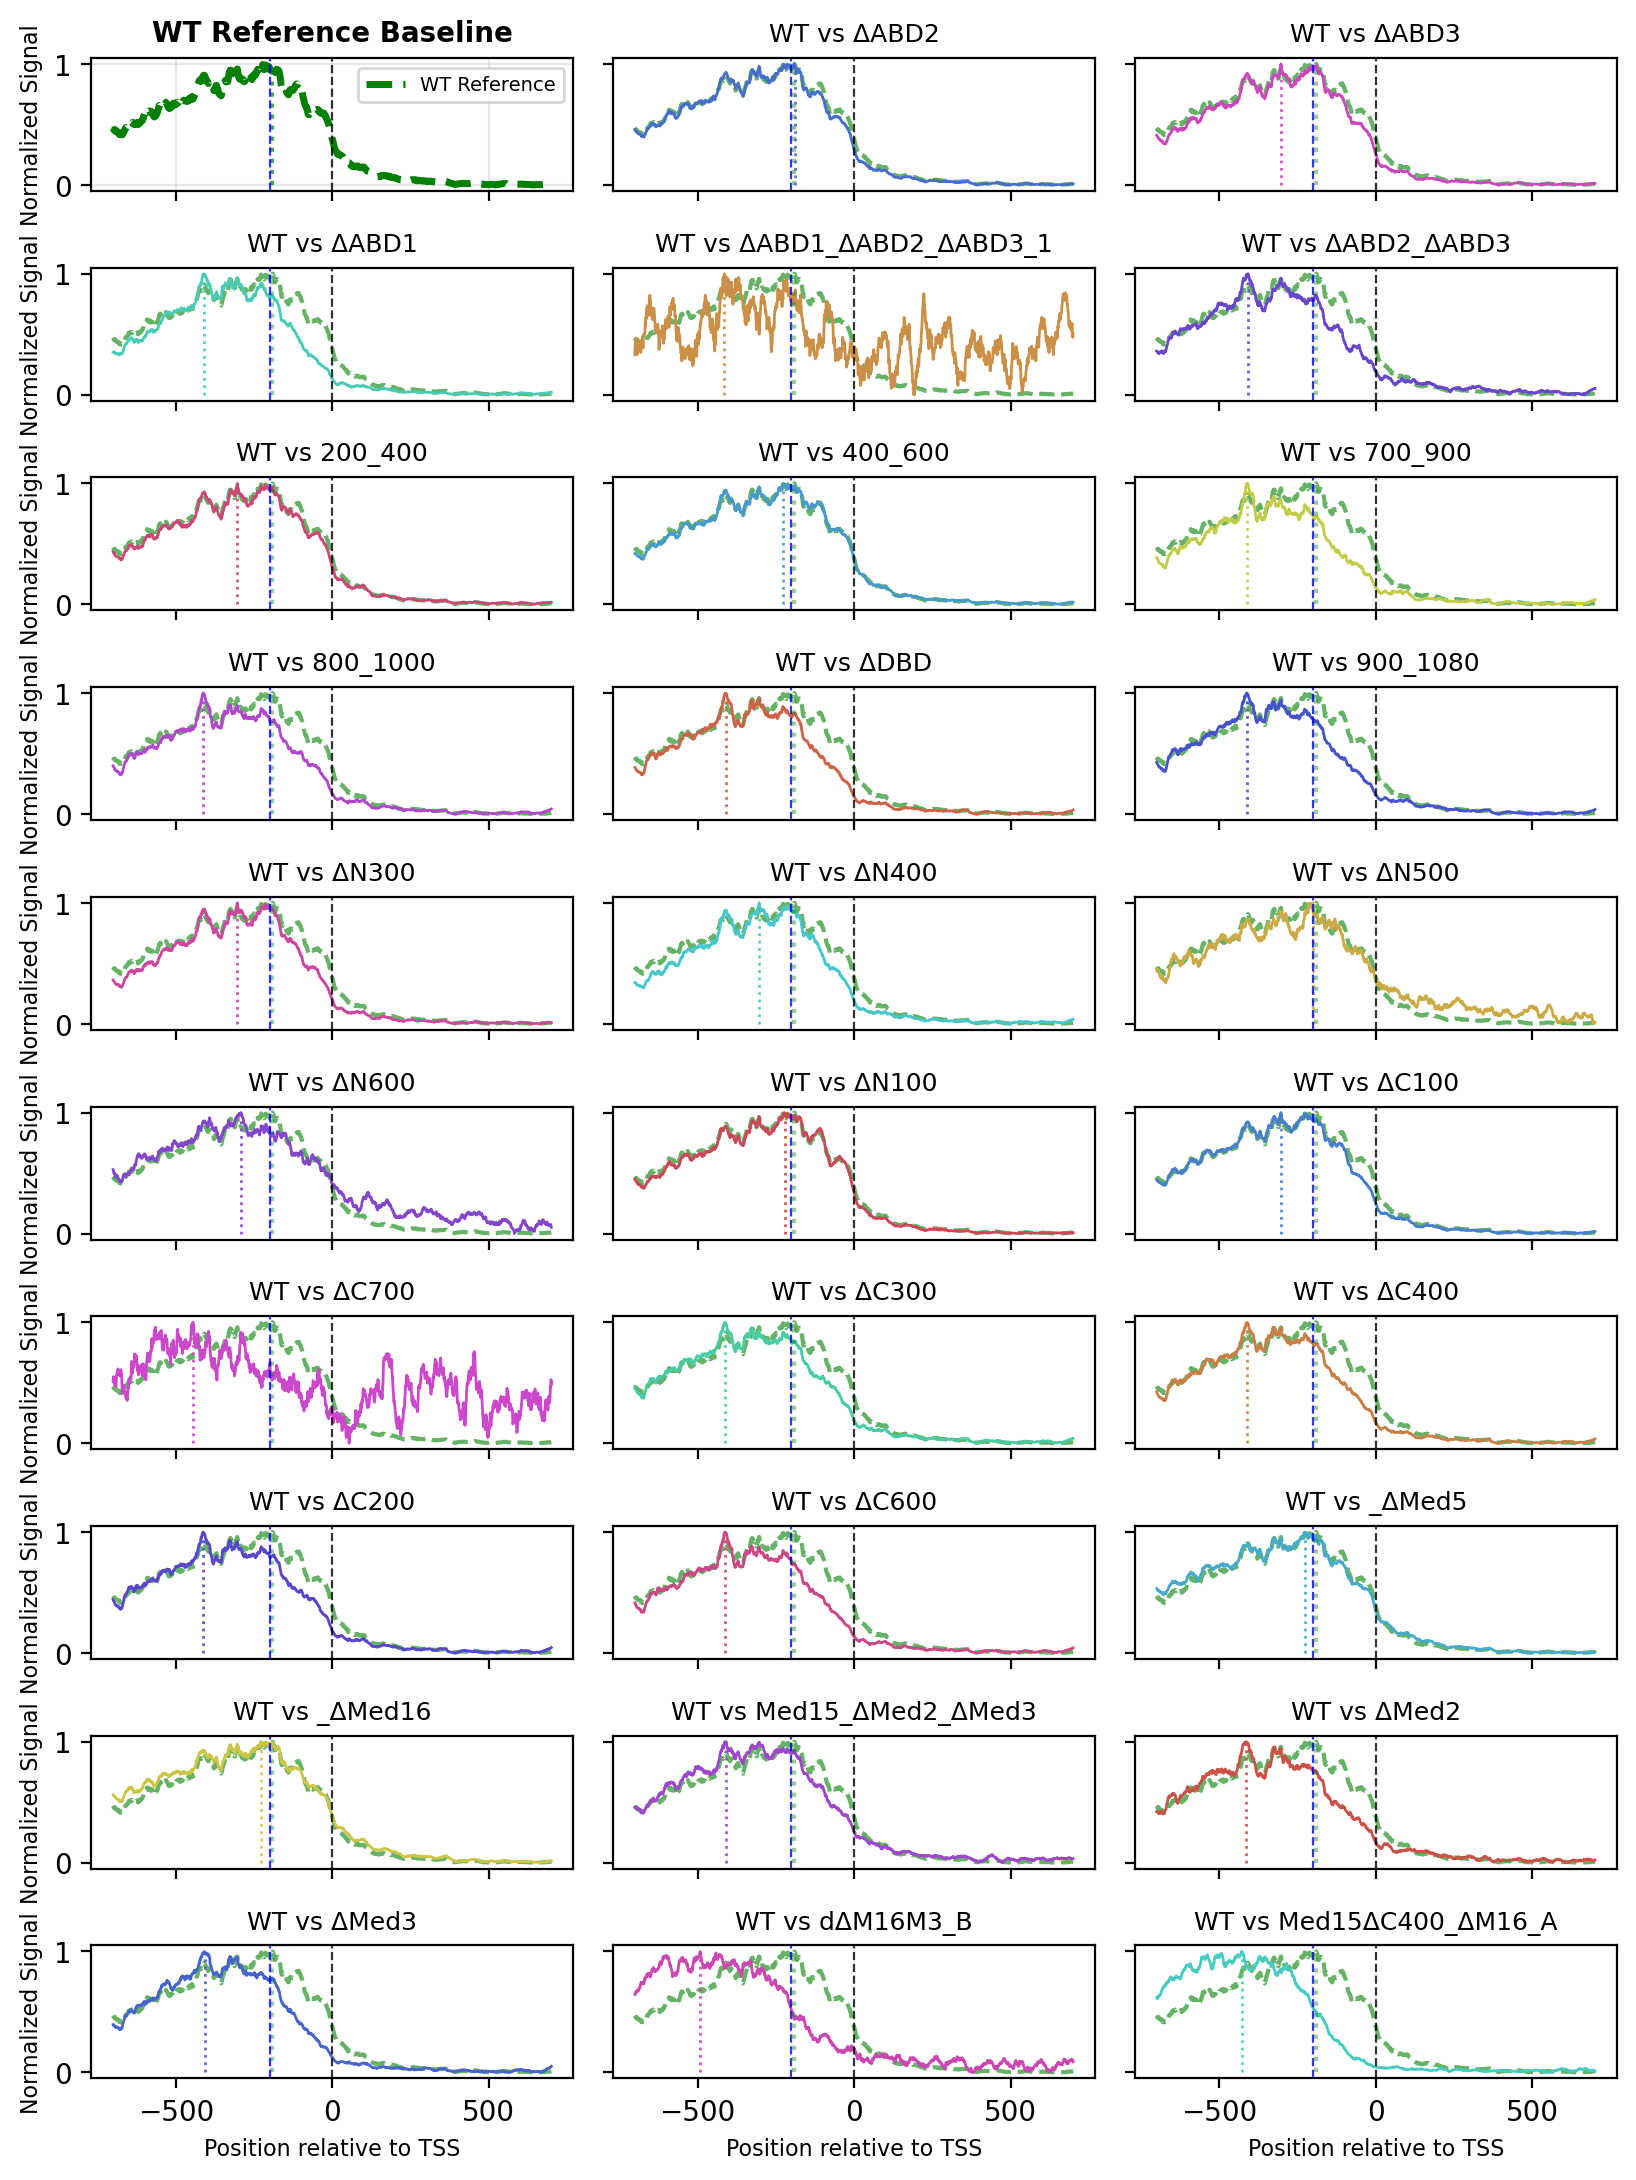

In [85]:
def plot_A4_master_grid():
    """
    Generates an A4-sized PDF containing a grid of all metaprofiles.
    WT is plotted as a dashed green line.
    Mutants get perfectly distinct, soft/light colors using Golden Ratio spacing.
    """
    window_start = -700
    window_end = 700
    x_axis = np.arange(window_start, window_end + 1)
    
    filtered_cols = promoter_binding_signals.filter(regex='Med15M|Med15_|Med15C').columns.tolist()
    
    # Exclude any column containing '_N200'
    filtered_cols = [c for c in filtered_cols if '_N200' not in str(c)]
    
    wt_col = next((c for c in filtered_cols if 'WT_Mnase' in str(c)), None)
    if wt_col in filtered_cols:
        filtered_cols.remove(wt_col)
    
    if not wt_col:
        print("❌ Error: Could not find the WT column in the dataframe!")
        return

    rem = filtered_cols.copy()
    mutants_sorted = []
    
    order_keywords = [
        'dABD',
        '200_400',
        '400_600',
        '700_900',
        '800_1000',
        'dDBD',
        '900_1080',
        '_N',
        '_C',
        'dMed5',
        'dMed16',
        'dMed2_dMed3', 
        'dMed2',
        'dMed3',
        'dM16'
    ]
    

    for kw in order_keywords:
        matches = [m for m in rem if kw in str(m)]
        mutants_sorted.extend(matches)
        rem = [m for m in rem if m not in matches]
        
    mutants = mutants_sorted + rem

    wt_path = promoter_binding_signals[wt_col].loc["path"]
    wt_df = pd.read_pickle(wt_path).fillna(0)

    if isinstance(wt_df.index, pd.RangeIndex) or wt_df.index.dtype == 'int64':
        if len(wt_df) == len(reference_index):
            wt_df.index = reference_index
    if wt_df.columns.min() == 0 and wt_df.columns.max() == wt_df.shape[1] - 1:
        start_col = -(wt_df.shape[1] // 2)
        wt_df.columns = range(start_col, start_col + wt_df.shape[1])

    wt_meta = get_normalized_metaprofile(wt_df, target_genes)
    wt_vals = wt_meta.values

    n_plots = len(mutants) + 1  
    cols = 3  
    rows = math.ceil(n_plots / cols)
    
    fig, axes = plt.subplots(rows, cols, figsize=(8.27, 11.69), sharex=True, sharey=True)
    axes = axes.flatten()
    

    distinct_colors = []
    golden_ratio_conjugate = 0.618033988749895
    h = 0.0  # Start at red

    while len(distinct_colors) < len(mutants) + 5:
        h = (h + golden_ratio_conjugate) % 1.0

        if 0.20 < h < 0.45:
            continue
 
        rgb = colorsys.hsv_to_rgb(h, 0.65, 0.80)
        distinct_colors.append(rgb)

    ax_wt = axes[0]
    ax_wt.plot(x_axis, wt_vals, color='green', linestyle='--', linewidth=2.5, label='WT Reference', rasterized=True)
    
    peak_x_wt = x_axis[np.argmax(wt_vals)]
    ax_wt.vlines(x=peak_x_wt, ymin=0, ymax=1.0, color='green', linestyle=':', linewidth=1.5, alpha=0.7, rasterized=True)
    
    ax_wt.axvline(0, color='black', linestyle='--', linewidth=0.8, alpha=0.8)
    ax_wt.axvline(-200, color='blue', linestyle='--', linewidth=0.8, alpha=0.8)
    
    ax_wt.set_title("WT Reference Baseline", fontsize=10, fontweight='bold')
    ax_wt.grid(True, alpha=0.3)
    ax_wt.legend(loc='upper right', fontsize=7)

    for i, mut_col in enumerate(mutants):
        ax = axes[i + 1]
        
        mut_color = distinct_colors[i]
        
        path = promoter_binding_signals[mut_col].loc["path"]
        mut_df = pd.read_pickle(path).fillna(0)


        if isinstance(mut_df.index, pd.RangeIndex) or mut_df.index.dtype == 'int64':
            if len(mut_df) == len(wt_df):
                mut_df.index = wt_df.index
            else:
                print(f"Warning: Cannot fix index for {mut_col}. Length mismatch.")
        

        if mut_df.columns.min() == 0 and mut_df.columns.max() == mut_df.shape[1] - 1:
            start_col = -(mut_df.shape[1] // 2)
            mut_df.columns = range(start_col, start_col + mut_df.shape[1])

        mut_meta = get_normalized_metaprofile(mut_df, target_genes)
        
        if mut_meta is None:
            ax.text(0.5, 0.5, f"No genes found\n{mut_col}", ha='center', va='center')
            continue

        # Plot lines (WT background is dashed green)
        ax.plot(x_axis, wt_vals, color='green', linestyle='--', linewidth=1.5, alpha=0.6, rasterized=True)
        ax.plot(x_axis, mut_meta.values, color=mut_color, linewidth=1, label=f"{mut_col}", rasterized=True)
        
        # Plot peaks
        peak_x_curr = x_axis[np.argmax(mut_meta.values)]
        ax.vlines(x=peak_x_wt, ymin=0, ymax=1.0, color='green', linestyle=':', linewidth=1.5, alpha=0.4, rasterized=True)
        ax.vlines(x=peak_x_curr, ymin=0, ymax=1.0, color=mut_color, linestyle=':', linewidth=1, alpha=0.9, rasterized=True)

        ax.axvline(0, color='black', linestyle='--', linewidth=0.8, alpha=0.8)
        ax.axvline(-200, color='blue', linestyle='--', linewidth=0.8, alpha=0.8)
        
        clean_title = str(mut_col).replace('WT_', '').replace('Med15_', '').replace('Mnase','')
        
        delta_map = {
            'dABD': 'ΔABD',
            'dDBD': 'ΔDBD',
            'dMed': 'ΔMed',
            'dM16': 'ΔM16',
            'C': 'ΔC',
            'N': 'ΔN',
            'dd': 'ΔΔ'
        }
        for old, new in delta_map.items():
            clean_title = clean_title.replace(old, new)
        
        ax.set_title(f"WT vs {clean_title}", fontsize=9)

    for j in range(n_plots, len(axes)):
        fig.delaxes(axes[j])
        
    for i in range(rows):
        if i * cols < len(axes):
            axes[i * cols].set_ylabel("Normalized Signal", fontsize=8)
            
    for j in range(cols):
        bottom_idx = (rows - 1) * cols + j
        if bottom_idx < len(axes):
            axes[bottom_idx].set_xlabel("Position relative to TSS", fontsize=8)
        elif bottom_idx - cols < len(axes): 
            axes[bottom_idx - cols].set_xlabel("Position relative to TSS", fontsize=8)

    plt.tight_layout(rect=[0, 0.02, 1, 0.96]) 

    plt.show()


plot_A4_master_grid()